## **Julio García Salas - 22076**
## **Sofía García - 22210**

# **Hoja de trabajo #3**

# **1. Cargar los datos**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(f"Train dataset: {train_df.shape}")
print(f"Test dataset: {test_df.shape}")

train_df.head()


Train dataset: (1460, 81)
Test dataset: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## **1️⃣ Descripción General del Dataset**

El conjunto de datos contiene información detallada sobre viviendas y su precio de venta (`SalePrice`). Se presentan las primeras 5 filas del dataset para visualizar la estructura de las variables.

### **📌 Observaciones Clave**
- **Total de columnas:** 81
- **La columna objetivo (`SalePrice`) está incluida en el dataset.**
- **Tipos de variables presentes:**
  - **Numéricas:** Ej. `LotArea`, `MoSold`, `YrSold`, `SalePrice`
  - **Categóricas:** Ej. `MSZoning`, `Street`, `Alley`, `SaleType`, `SaleCondition`
- **Posibles valores nulos en columnas como `Alley`, `PoolQC`, `Fence`, `MiscFeature`** (se observan valores `NaN`).



# **2.  Descripción de los datos**

In [2]:
train_df.info()

train_df.describe()

missing_values = train_df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## **2️⃣ Estructura y Tipos de Datos**

El conjunto de datos contiene **1460 registros** y **81 columnas**, con una combinación de variables numéricas y categóricas. A continuación, se detallan los tipos de datos y la cantidad de valores no nulos por variable.

### **📌 Resumen de los Tipos de Datos**
- **35 columnas numéricas (int64)**
- **3 columnas de tipo flotante (float64)**
- **43 columnas categóricas (object)**

### **📊 Variables con Valores Nulos**
Algunas variables contienen valores faltantes que podrían impactar el análisis y los modelos de regresión.

| Variable        | Valores No Nulos | Tipo de Dato  |
|---------------|----------------|-------------|
| **LotFrontage** | 1201 / 1460 | `float64` |
| **Alley** | 91 / 1460 | `object` |
| **MasVnrType** | 1452 / 1460 | `object` |
| **FireplaceQu** | 770 / 1460 | `object` |
| **PoolQC** | 7 / 1460 | `object` |
| **Fence** | 281 / 1460 | `object` |
| **MiscFeature** | 54 / 1460 | `object` |

💡 **Observaciones sobre valores nulos:**
- Variables como **`Alley`**, **`PoolQC`**, **`Fence`**, y **`MiscFeature`** tienen una gran cantidad de valores faltantes y podrían no aportar mucho valor al modelo.
- **`LotFrontage`** tiene 259 valores nulos, lo que podría impactar su uso como predictor.
- Se deben definir estrategias para manejar los valores nulos, ya sea eliminando las variables, imputándolas o reemplazándolas con valores predeterminados.



# **3. Análisis exploratorio**

## **a. Distribución de la Variable SalePrice**

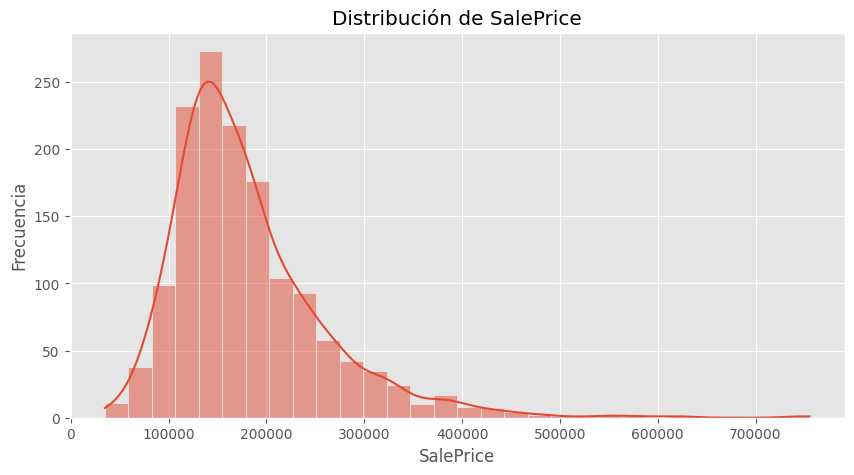

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df["SalePrice"], bins=30, kde=True)
plt.xlabel("SalePrice")
plt.ylabel("Frecuencia")
plt.title("Distribución de SalePrice")
plt.show()

# Estadísticas clave
train_df["SalePrice"].describe()


## **3️⃣ Distribución de la Variable Objetivo (`SalePrice`)**

El objetivo del modelo es predecir `SalePrice`, por lo que es fundamental analizar su distribución. A continuación, se presenta un histograma con la densidad de la variable objetivo.

### **🔍 Observaciones Clave**
1. **Sesgo Positivo (Right-Skewed):**  
   - La distribución muestra un sesgo a la derecha, con una larga cola hacia valores altos.
   - Esto indica que hay algunas viviendas con precios excepcionalmente altos en comparación con el resto.

2. **Precio Promedio y Mediana:**  
   - **Media (`mean`):** 180,921 USD  
   - **Mediana (`50%`):** 163,000 USD  
   - La mediana es menor que la media, lo que confirma que la distribución está sesgada.

3. **Rango de Precios:**  
   - **Mínimo:** 34,900 USD  
   - **Máximo:** 755,000 USD  
   - **El 75% de las casas cuestan menos de 214,000 USD.**

4. **Posibles Valores Atípicos:**  
   - Existen valores muy altos en `SalePrice`, lo que podría influir en los modelos de predicción.
   - Se recomienda analizar estos valores en conjunto con otras variables para decidir si deben transformarse o eliminarse.

---

## **⚠️ Posibles Acciones**
✅ **Transformación Logarítmica:**  
   - Debido al sesgo en la distribución, aplicar `log(SalePrice)` podría mejorar la precisión del modelo.  
   - Esto ayudaría a que los modelos de regresión lineal trabajen mejor con los datos.  

✅ **Identificación de Valores Atípicos:**  
   - Se debe analizar `SalePrice` en función de otras variables como `GrLivArea` y `OverallQual` para ver si los valores extremos corresponden a patrones esperados o son outliers.

✅ **Comparación con Variables Predictoras:**  
   - Se deben examinar las correlaciones con variables clave como `GrLivArea`, `TotalBsmtSF`, y `OverallQual` antes de aplicar la regresión.




## **b. Valores atípicos en SalePrice**

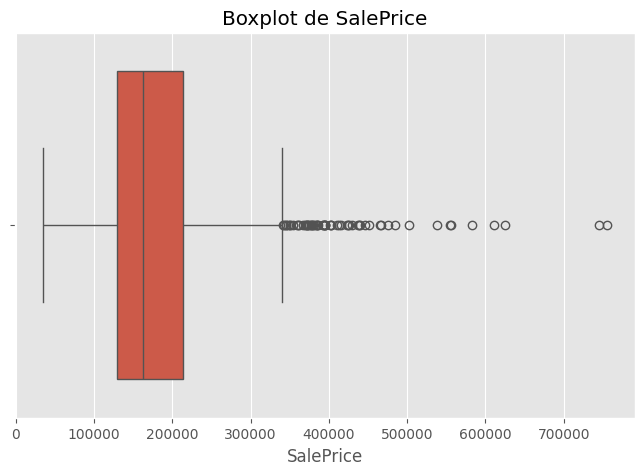

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=train_df["SalePrice"])
plt.title("Boxplot de SalePrice")
plt.show()


# **Análisis Exploratorio - Detección de Valores Atípicos en `SalePrice`**

### **🔍 Observaciones Clave**
1. **Presencia de Valores Atípicos:**  
   - Existen **múltiples valores fuera de los bigotes del boxplot** a partir de aproximadamente **400,000 USD**.
   - Los valores más extremos superan los **700,000 USD**.

2. **Percentiles y Rango Intercuartílico (IQR):**  
   - **25% (Q1):** 129,975 USD  
   - **50% (Mediana):** 163,000 USD  
   - **75% (Q3):** 214,000 USD  
   - **Valores superiores a `Q3 + 1.5*IQR` se consideran outliers.**  

   **Cálculo del IQR:**  
   - IQR = Q3 - Q1 = 214,000 - 129,975 = 84,025 Límite superior = Q3 + 1.5 * IQR = 214,000 + (1.5 * 84,025) = 340,037.5

   - **Valores mayores a 340,037 USD podrían considerarse valores atípicos.**  

3. **Impacto en Modelos de Regresión:**  
- Los valores atípicos pueden afectar los modelos de regresión lineal, ya que tienden a influir desproporcionadamente en los coeficientes.
- Se debe evaluar si estos valores extremos siguen un patrón o si deben ser eliminados o transformados.

---

## **⚠️ Posibles Acciones**
✅ **Transformación Logarítmica de `SalePrice`:**  
- Aplicar `log(SalePrice)` puede ayudar a reducir el impacto de los valores atípicos.  

✅ **Eliminación de Outliers:**  
- Se pueden eliminar los valores que superen **340,000 USD** si afectan negativamente el rendimiento del modelo.  
- Otra opción es **revisar qué características tienen en común** las casas con precios extremos para tomar decisiones basadas en evidencia.

✅ **Uso de Modelos Robust Regression:**  
- En lugar de usar regresión lineal estándar, se pueden explorar modelos robustos como **RANSAC Regression** o **Gradient Boosting**, que son menos sensibles a valores extremos.


## **c. Correlación de Variables Numéricas con SalePrice**

C:\Users\garci\AppData\Local\Temp\ipykernel_27440\4012237561.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette="viridis")


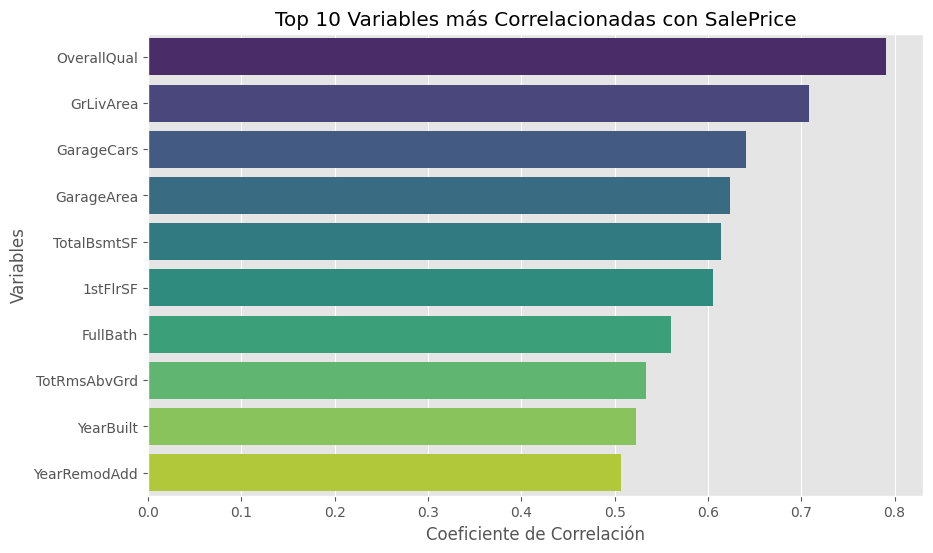

In [5]:
correlation_matrix = train_df.select_dtypes(include=['number']).corr()["SalePrice"].sort_values(ascending=False)

top_corr_features = correlation_matrix[1:11]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette="viridis")
plt.xlabel("Coeficiente de Correlación")
plt.ylabel("Variables")
plt.title("Top 10 Variables más Correlacionadas con SalePrice")
plt.show()


# **Análisis Exploratorio - Correlación de Variables Numéricas con `SalePrice`**

### **🔍 Observaciones Clave**
1. **Las variables con mayor correlación positiva con `SalePrice` son:**
   - **`OverallQual` (0.79):** La calidad general de la construcción es la variable más influyente en el precio de las casas.
   - **`GrLivArea` (0.71):** El área habitable total sobre el suelo tiene una alta relación con `SalePrice`.
   - **`GarageCars` y `GarageArea` (~0.62 - 0.64):** La cantidad de autos que caben en el garaje y su tamaño son importantes para la valoración de la vivienda.

2. **Las demás variables con fuerte correlación incluyen:**
   - **`TotalBsmtSF` (0.61):** El área total del sótano tiene una relación considerable con `SalePrice`.
   - **`1stFlrSF` (0.60):** El tamaño del primer piso también influye en el precio de las viviendas.
   - **`FullBath` (0.56):** El número total de baños completos impacta en el precio final.
   - **`TotRmsAbvGrd` (0.53):** Más habitaciones por encima del suelo tienden a correlacionarse con precios más altos.
   - **`YearBuilt` (0.52):** Las casas más nuevas suelen venderse a precios más altos.
   - **`YearRemodAdd` (0.51):** Las remodelaciones aumentan el valor de una propiedad.

3. **Conclusiones sobre la Correlación:**
   - **Se observa una fuerte relación entre el tamaño, la calidad y el precio de las viviendas.**
   - **La edad y remodelaciones también juegan un papel importante en la valuación del inmueble.**
   - **El número de habitaciones y baños tiene impacto, aunque menor que el tamaño y la calidad general.**
   - **Variables relacionadas con sótanos y garajes también tienen correlaciones significativas.**

---

## **⚠️ Posibles Acciones**
✅ **Selección de Variables para Modelado:**  
   - Las variables con alta correlación pueden ser incluidas en la regresión para mejorar la predicción.  
   - Se debe evitar el problema de **multicolinealidad** (cuando dos o más variables están altamente correlacionadas entre sí).  

✅ **Análisis de Multicolinealidad:**  
   - Se recomienda calcular el **VIF (Variance Inflation Factor)** para determinar si algunas variables aportan información redundante.  

✅ **Transformaciones Adicionales:**  
   - `SalePrice` puede beneficiarse de una **transformación logarítmica** para mejorar la linealidad con estas variables.  

✅ **Posible Eliminación de Variables con Baja Correlación:**  
   - Variables con **baja correlación** no son útiles para modelos de regresión lineal. Se debe evaluar si es necesario incluirlas.  



## **d. Cantidad de valores únicos en variables categóricas**

In [6]:
categorical_features = train_df.select_dtypes(include=['object']).nunique().sort_values(ascending=False)

print(categorical_features)


Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64


# **Análisis Exploratorio - Variables Categóricas**

## **🔍 Observaciones Clave**
1. **Variables con Alta Cardinalidad (Muchas Categorías)**  
   - `Neighborhood` (25 categorías) y `Exterior1st` / `Exterior2nd` (15-16 categorías) pueden ser difíciles de codificar directamente.  
   - Es posible agrupar algunos valores similares para reducir la cantidad de categorías.  

2. **Variables con Baja Cardinalidad (Pocas Categorías)**  
   - `Street`, `CentralAir` y `Alley` tienen solo **2 valores únicos**, lo que las hace buenas candidatas para conversión a variables binarias.  

3. **Posibles Problemas con Variables Categóricas**  
   - Variables como `HeatingQC`, `GarageQual`, y `FireplaceQu` tienen **valores ordinales** (calidad baja, media, alta). En lugar de aplicar One-Hot Encoding, podrían convertirse en **valores numéricos ordinales** para mejorar la predicción.  

---

## **⚠️ Posibles Acciones**
✅ **Codificación de Variables Categóricas:**  
   - **One-Hot Encoding:** Para variables con pocas categorías (`MSZoning`, `SaleType`, `RoofStyle`).  
   - **Agrupación de Categorías:** Para variables con demasiados valores (`Neighborhood`, `Exterior1st`).  
   - **Conversión a Escalas Numéricas:** Para variables ordinales (`HeatingQC`, `GarageQual`).  

✅ **Análisis de Impacto de Variables Categóricas en `SalePrice`:**  
   - Se deben realizar boxplots para evaluar si estas variables tienen una relación significativa con el precio de las viviendas.  

✅ **Evaluación de Necesidad de Transformación:**  
   - Variables binarias (`CentralAir`, `Street`) pueden ser convertidas a `0/1`.  
   - Variables con valores faltantes (`Alley`, `FireplaceQu`) pueden ser tratadas con **una categoría adicional ("No disponible")**.  



## **e. Transformación Logarítmica de SalePrice**

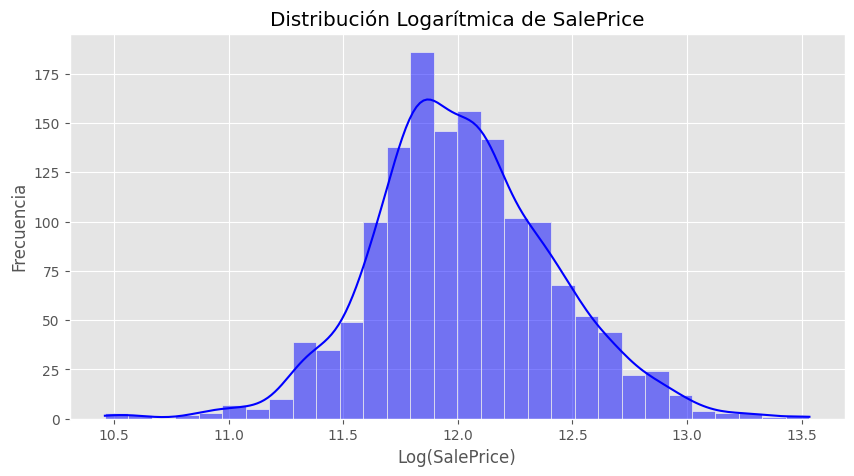

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(train_df["SalePrice"]), bins=30, kde=True, color="blue")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Frecuencia")
plt.title("Distribución Logarítmica de SalePrice")
plt.show()


# **Análisis Exploratorio - Transformación Logarítmica de `SalePrice`**

### **🔍 Observaciones Clave**
1. **Corrección del Sesgo Positivo:**  
   - La distribución original de `SalePrice` mostraba una asimetría a la derecha (valores altos muy dispersos).  
   - Con la transformación `log1p(SalePrice)`, la distribución se vuelve más simétrica y se asemeja más a una distribución normal.  

2. **Importancia para Modelos Lineales:**  
   - Los modelos de regresión lineal **funcionan mejor cuando la variable objetivo sigue una distribución normal**.  
   - Esta transformación permite que los coeficientes del modelo sean más interpretables y evita que valores extremos dominen la predicción.  

3. **Escala y Rango de Valores:**  
   - En lugar de tener precios que van desde **34,900 USD hasta 755,000 USD**, la escala logarítmica comprime estos valores dentro de un **rango más estrecho (~10.5 a ~13.5 en logaritmo natural)**.  
   - Esto ayuda a que el modelo sea más estable y menos sensible a valores extremos.  

---

## **⚠️ Posibles Acciones**
✅ **Mantener `Log(SalePrice)` como la variable objetivo en la regresión:**  
   - Esto mejorará la capacidad predictiva del modelo y reducirá problemas de heterocedasticidad.  




## **f. Detección de valores atípicos en GrLivArea**

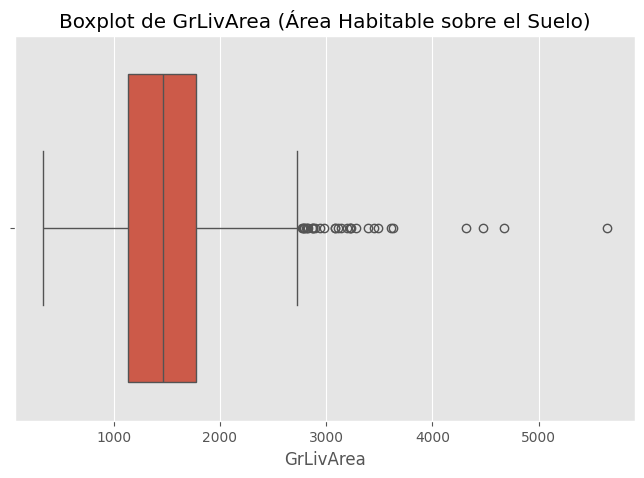

      GrLivArea  SalePrice
523        4676     184750
691        4316     755000
1182       4476     745000
1298       5642     160000


In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=train_df["GrLivArea"])
plt.title("Boxplot de GrLivArea (Área Habitable sobre el Suelo)")
plt.show()

outliers_grlivarea = train_df[train_df["GrLivArea"] > 4000][["GrLivArea", "SalePrice"]]
print(outliers_grlivarea)


# **Análisis Exploratorio - Valores Atípicos en `GrLivArea` (Área Habitable sobre el Suelo)**

### **🔍 Observaciones Clave**
1. **Presencia de Valores Atípicos Extremos:**  
   - Se observan **varios valores fuera del rango intercuartílico (IQR)**.  
   - Algunas casas tienen áreas habitables muy grandes en comparación con el resto.  

2. **Casas con `GrLivArea` extremadamente altas:**  
- La casa con **5642 `GrLivArea`** tiene un precio relativamente bajo (160,000 USD), lo que sugiere que podría ser un **outlier influenciando el modelo de manera no deseada**.  
- Algunas casas con gran tamaño tienen precios altos (**745,000 - 755,000 USD**), lo que puede afectar la relación lineal con `SalePrice`.  

3. **Impacto en la Regresión Lineal:**  
- La regresión lineal es **sensible a valores atípicos**.  
- Si estas observaciones no siguen la tendencia del resto de los datos, podrían distorsionar la predicción.  

---

## **⚠️ Posibles Acciones**
✅ **Eliminar los Valores Atípicos Más Extremos:**  
- Se podrían eliminar las casas con `GrLivArea > 4000`, especialmente si su precio no sigue la tendencia esperada.  

✅ **Transformación Logarítmica:**  
- Similar a `SalePrice`, aplicar `log(GrLivArea)` puede reducir la influencia de valores extremadamente altos.  




## **g. Relación entre GrLivArea y SalePrice**

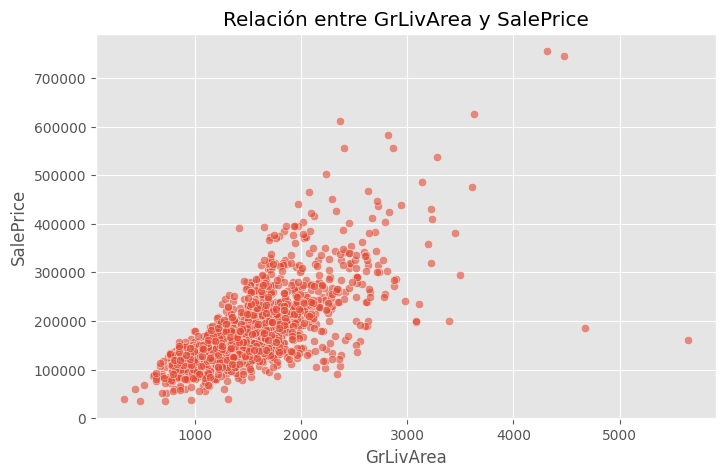

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train_df["GrLivArea"], y=train_df["SalePrice"], alpha=0.6)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Relación entre GrLivArea y SalePrice")
plt.show()


# **Análisis Exploratorio - Relación entre `GrLivArea` y `SalePrice`**


### **🔍 Observaciones Clave**
1. **Tendencia Lineal General:**  
   - Existe una **correlación positiva fuerte** entre `GrLivArea` (Área Habitable) y `SalePrice` (Precio de Venta).  
   - En general, a mayor `GrLivArea`, mayor es el precio de venta de la vivienda.  

2. **Presencia de Valores Atípicos:**  
   - Se observan **varios valores fuera del patrón general**, especialmente en `GrLivArea > 4000`.  
   - Algunas casas tienen **áreas grandes pero precios bajos**, lo que podría indicar registros atípicos.  

3. **Posibles Problemas en la Regresión Lineal:**  
   - La presencia de **valores extremos en `GrLivArea` puede afectar la estabilidad del modelo**.  
   - Si bien la relación general es lineal, los outliers pueden causar sesgos en los coeficientes de la regresión.  



 




# **4. Análisis de relaciones con SalePrice**

### **a. Relación de OverallQual con SalePrice**

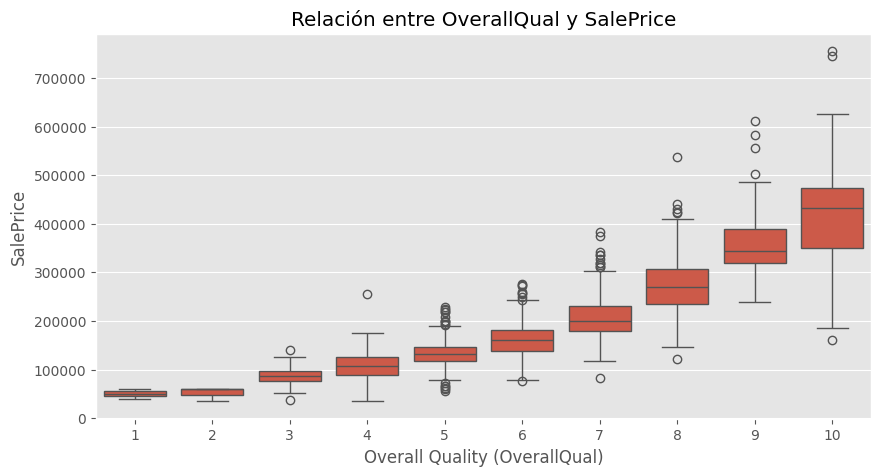

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="OverallQual", y="SalePrice", data=train_df)
plt.xlabel("Overall Quality (OverallQual)")
plt.ylabel("SalePrice")
plt.title("Relación entre OverallQual y SalePrice")
plt.show()


# **Análisis Exploratorio - Relación entre `OverallQual` y `SalePrice`**


### **🔍 Observaciones Clave**
1. **Relación Positiva Fuerte:**  
   - Existe una **correlación positiva clara** entre la calidad de la construcción (`OverallQual`) y el precio de venta (`SalePrice`).  
   - A medida que aumenta `OverallQual`, el precio de la vivienda tiende a ser más alto.  

2. **Aumento de Dispersión en Calidades Altas:**  
   - Para valores bajos de `OverallQual` (1-4), los precios son consistentemente bajos.  
   - Para valores altos (8-10), hay **mayor dispersión en `SalePrice`**, lo que indica que otros factores pueden influir en el precio de las casas de mayor calidad.  

3. **Valores Atípicos en Calidades Bajas y Altas:**  
   - En `OverallQual = 10`, algunos precios son **notablemente bajos** en comparación con la media del grupo.  
   - En `OverallQual = 1-3`, algunas casas tienen **precios más altos de lo esperado**, lo que podría indicar excepciones en la relación esperada.  




### **b. Relación de GarageCars con SalePrice**

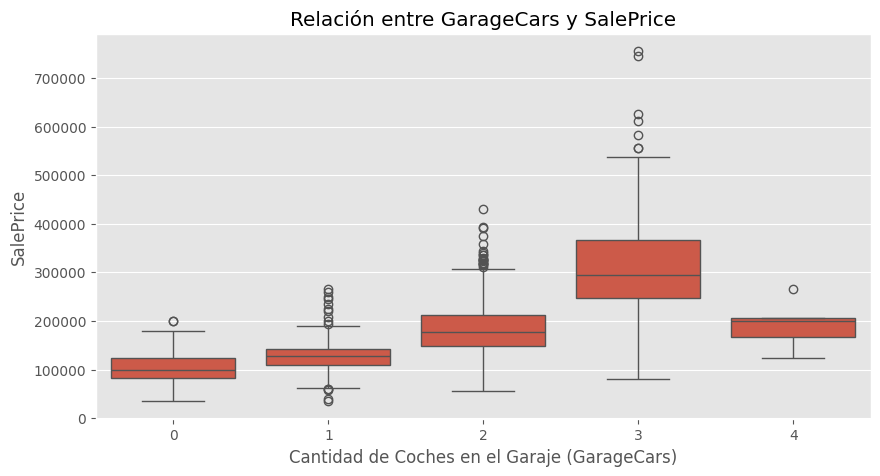

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="GarageCars", y="SalePrice", data=train_df)
plt.xlabel("Cantidad de Coches en el Garaje (GarageCars)")
plt.ylabel("SalePrice")
plt.title("Relación entre GarageCars y SalePrice")
plt.show()


# **Análisis Exploratorio - Relación entre `GarageCars` y `SalePrice`**


### **🔍 Observaciones Clave**
1. **Tendencia Positiva:**  
   - Existe una **correlación positiva clara** entre la cantidad de coches en el garaje (`GarageCars`) y el precio de venta (`SalePrice`).  
   - A medida que aumenta `GarageCars`, el precio promedio de la vivienda también tiende a aumentar.  

2. **Distribución por Cantidad de Coches:**  
   - **0 autos:** Viviendas sin garaje tienden a ser las más baratas, con pocos casos que superan los **200,000 USD**.  
   - **1 auto:** Rango de precios más amplio, pero la mayoría está entre **100,000 y 200,000 USD**.  
   - **2 autos:** Categoría más común, con precios que rondan los **150,000 - 300,000 USD**.  
   - **3 autos:** Precio medio más alto, entre **200,000 - 400,000 USD**, con algunos valores atípicos.  
   - **4 autos o más:** Pocos casos, con precios más variables y algunos valores atípicos.  

3. **Valores Atípicos:**  
   - En todas las categorías hay valores que se alejan del patrón general.  
   - Para `GarageCars = 3 y 4`, algunos precios están **por debajo del promedio esperado**, lo que sugiere que otras variables pueden influir en el valor de la propiedad.  



## **5. Variables predictoras**

C:\Users\garci\AppData\Local\Temp\ipykernel_27440\3301757897.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_predictors.values, y=top_predictors.index, palette="magma")


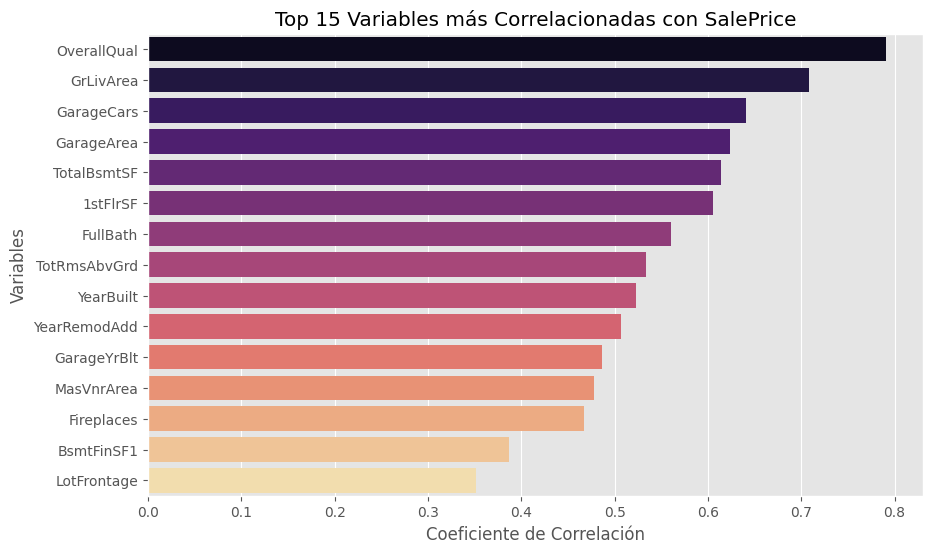

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = train_df.select_dtypes(include=['number'])

correlation_matrix = numeric_features.corr()["SalePrice"].sort_values(ascending=False)

top_predictors = correlation_matrix[1:16] 

plt.figure(figsize=(10, 6))
sns.barplot(x=top_predictors.values, y=top_predictors.index, palette="magma")
plt.xlabel("Coeficiente de Correlación")
plt.ylabel("Variables")
plt.title("Top 15 Variables más Correlacionadas con SalePrice")
plt.show()

print(top_predictors)

# **Ingeniería de Características - Selección de Variables Predictoras**


### **🔍 Observaciones Clave**
1. **Variables con Mayor Correlación con `SalePrice`:**
   - **`OverallQual` (0.79):** La calidad general de la casa es el predictor más fuerte.
   - **`GrLivArea` (0.71):** El área habitable sobre el suelo es altamente relevante.
   - **`GarageCars` (0.64) y `GarageArea` (0.62):** El tamaño del garaje influye en el precio.
   - **`TotalBsmtSF` (0.61):** El área total del sótano es otro fuerte predictor.

2. **Impacto de Variables Temporales:**
   - **`YearBuilt` (0.52) y `YearRemodAdd` (0.51):** Casas más nuevas o remodeladas tienden a valer más.
   - **`GarageYrBlt` (0.49):** Año en que se construyó el garaje también es relevante.

3. **Otras Variables Importantes:**
   - **`FullBath` (0.56) y `TotRmsAbvGrd` (0.53):** Más baños y habitaciones aumentan el precio.
   - **`MasVnrArea` (0.47):** Superficie de recubrimiento de mampostería aporta al valor.
   - **`Fireplaces` (0.46):** Tener chimenea aumenta el precio.
   - **`BsmtFinSF1` (0.39) y `LotFrontage` (0.35):** Contribuyen, aunque con menor impacto.



## **7. Modelo Univariado**

Coeficiente del modelo: 45435.80259309942
Intercepto del modelo: -96206.0795147605
MSE (Error Cuadrático Medio): 2360934371.5670257
R² (Coeficiente de Determinación): 0.625651892462118


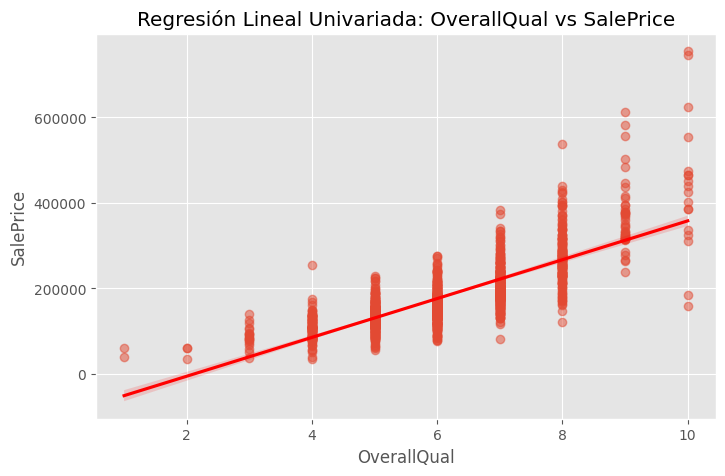

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train_uni = train_df[["OverallQual"]] 
y_train_uni = train_df["SalePrice"] 

model_uni = LinearRegression()
model_uni.fit(X_train_uni, y_train_uni)

y_pred_uni = model_uni.predict(X_train_uni)

mse = mean_squared_error(y_train_uni, y_pred_uni)
r2 = r2_score(y_train_uni, y_pred_uni)

print(f"Coeficiente del modelo: {model_uni.coef_[0]}")
print(f"Intercepto del modelo: {model_uni.intercept_}")
print(f"MSE (Error Cuadrático Medio): {mse}")
print(f"R² (Coeficiente de Determinación): {r2}")

plt.figure(figsize=(8, 5))
sns.regplot(x=X_train_uni, y=y_train_uni, scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Regresión Lineal Univariada: OverallQual vs SalePrice")
plt.show()


# **Regresión Lineal Univariada - `OverallQual` vs `SalePrice`**



### **🔍 Observaciones Clave**
1. **Ecuación del Modelo:**  
   - `SalePrice = (45435.80 * OverallQual) - 96206.08`  
   - Esto significa que, en promedio, **por cada aumento de una unidad en `OverallQual`**, el precio de la casa incrementa en **45,435.80 USD**.  

2. **Evaluación del Modelo:**  
   - **Error Cuadrático Medio (MSE):** `2,360,934,371.57`  
     - Indica cuánto se desvía en promedio la predicción del valor real.  
   - **Coeficiente de Determinación (R²):** `0.6256`  
     - Significa que el **62.56% de la variabilidad en `SalePrice` es explicada por `OverallQual`**.  
     - No es un ajuste perfecto, pero indica una relación fuerte.  

3. **Patrón en la Gráfica:**  
   - La tendencia general sigue una **relación lineal positiva**: casas de mayor calidad (`OverallQual`) tienden a tener precios más altos.  
   - Sin embargo, hay **dispersión en cada nivel de `OverallQual`**, lo que sugiere que otros factores también influyen en el precio.  



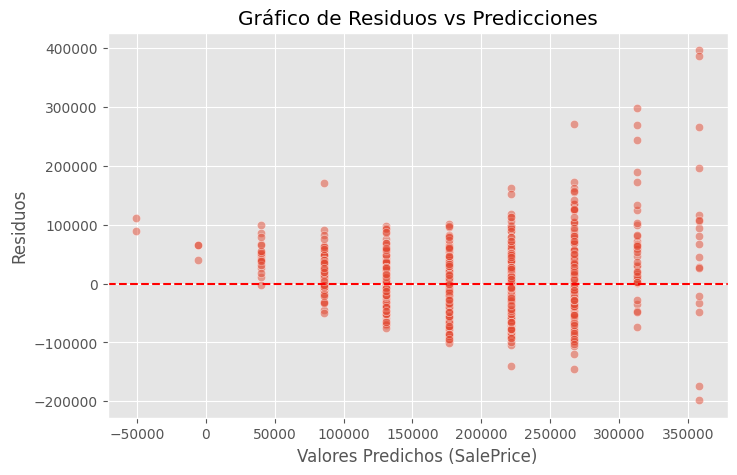

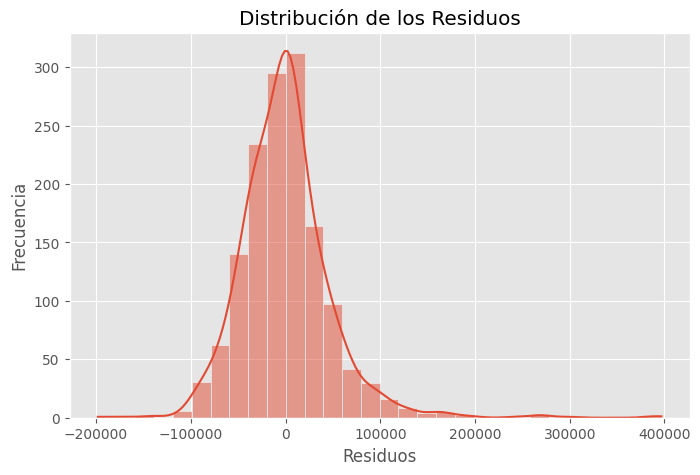

Shapiro-Wilk Test: Estadístico=0.9058165331072716, p-valor=4.2614179441154915e-29


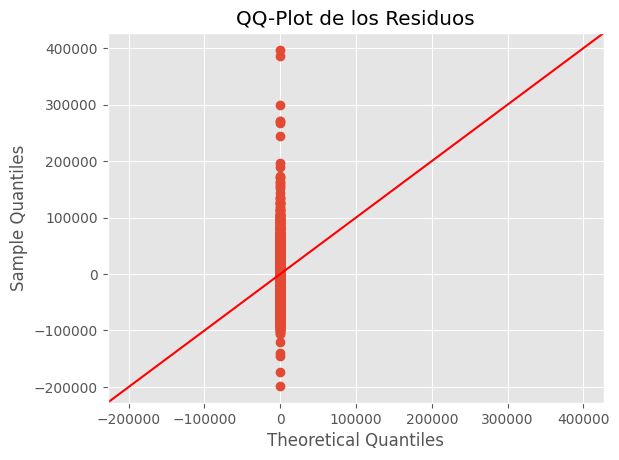

In [14]:
import statsmodels.api as sm

residuals = y_train_uni - y_pred_uni

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_uni, y=residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valores Predichos (SalePrice)")
plt.ylabel("Residuos")
plt.title("Gráfico de Residuos vs Predicciones")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los Residuos")
plt.show()

from scipy.stats import shapiro
stat, p_value = shapiro(residuals)
print(f"Shapiro-Wilk Test: Estadístico={stat}, p-valor={p_value}")

sm.qqplot(residuals, line='45')
plt.title("QQ-Plot de los Residuos")
plt.show()


# **Análisis de Residuos - Regresión Lineal Univariada**

## **📊 Gráfico de Residuos vs Predicciones**

### **🔍 Observaciones Clave**
1. **Patrón de los Residuos:**  
   - Los residuos **no están completamente dispersos de manera aleatoria** alrededor de la línea roja (`y = 0`).  
   - Se observa una **dispersión más amplia en valores altos de `SalePrice`**, lo que indica heterocedasticidad (*varianza no constante de los residuos*).  
   - Un patrón en forma de abanico sugiere que el modelo **no captura bien la variabilidad en precios altos**.  

---

## **📊 Distribución de los Residuos**

2. **Asimetría en la Distribución de los Residuos:**  
   - La distribución de los residuos **no es completamente normal**, ya que muestra una ligera asimetría positiva.  
   - Hay algunos **valores extremos en la parte derecha**, lo que indica que el modelo subestima algunos precios altos.  

---

## **📊 QQ-Plot de los Residuos**

3. **Normalidad de los Residuos (QQ-Plot y Test de Shapiro-Wilk):**  
   - En el **QQ-Plot**, los puntos **se desvían de la línea de normalidad**, especialmente en los extremos.  
   - El **Test de Shapiro-Wilk** devuelve:  
     - **Estadístico = 0.9058**  
     - **p-valor = 4.26e-29** (muy bajo)  
   - Como el **p-valor < 0.05**, se **rechaza la hipótesis nula** de normalidad de los residuos, confirmando que **no siguen una distribución normal**.  




## **8. Regresión Múltiple**

C:\Users\garci\AppData\Local\Temp\ipykernel_27440\2916583175.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_multi.fillna(X_train_multi.median(), inplace=True)


Coeficientes del modelo: [ 1.87989498e+04  3.96157057e+01  1.06588731e+04  8.64152360e+00
  1.14035650e+01  8.62537407e+00 -2.00769334e+03  1.48862894e+03
  1.53492009e+02  3.59717722e+02  5.73795713e+01  2.87816193e+01
  8.37452958e+03  1.82992321e+01  4.93609768e+01]
Intercepto del modelo: -1195109.6952450064
MSE (Error Cuadrático Medio): 1326645774.470511
R² (Coeficiente de Determinación): 0.7896479711477382


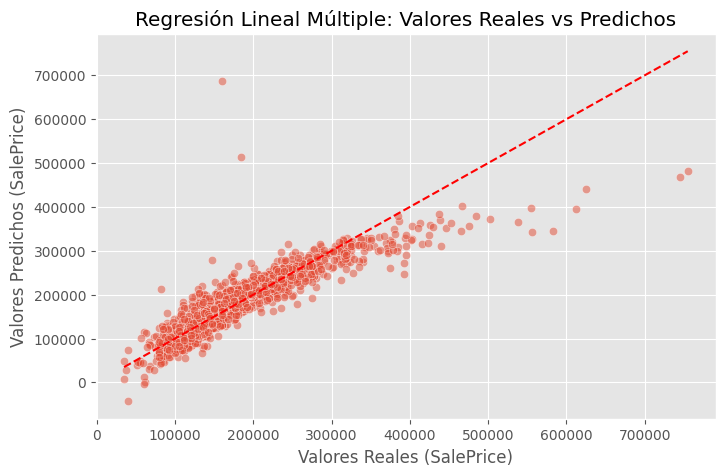

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train_multi = train_df[[
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
    "GarageYrBlt", "MasVnrArea", "Fireplaces", "BsmtFinSF1", "LotFrontage"
]]

X_train_multi.fillna(X_train_multi.median(), inplace=True)

y_train_multi = train_df["SalePrice"]

model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

y_pred_multi = model_multi.predict(X_train_multi)

mse_multi = mean_squared_error(y_train_multi, y_pred_multi)
r2_multi = r2_score(y_train_multi, y_pred_multi)

print(f"Coeficientes del modelo: {model_multi.coef_}")
print(f"Intercepto del modelo: {model_multi.intercept_}")
print(f"MSE (Error Cuadrático Medio): {mse_multi}")
print(f"R² (Coeficiente de Determinación): {r2_multi}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_train_multi, y=y_pred_multi, alpha=0.5)
plt.plot([min(y_train_multi), max(y_train_multi)], 
         [min(y_train_multi), max(y_train_multi)], 
         color="red", linestyle="--")
plt.xlabel("Valores Reales (SalePrice)")
plt.ylabel("Valores Predichos (SalePrice)")
plt.title("Regresión Lineal Múltiple: Valores Reales vs Predichos")
plt.show()


# **Regresión Lineal Múltiple - Evaluación del Modelo**

## **📊 Gráfico de Valores Reales vs Predichos**

### **🔍 Observaciones Clave**
1. **Ecuación del Modelo:**  
   - `SalePrice = (-1,195,109.70) + (18,798.95 * OverallQual) + (39.61 * GrLivArea) + (10,658.87 * GarageCars) + ...`  
   - Cada variable contribuye con un peso específico al precio final de la vivienda.  

2. **Evaluación del Modelo:**  
   - **Error Cuadrático Medio (MSE):** `1,326,645,774.47`  
     - Es más bajo que en el modelo univariado (`2,360,934,371.57`), lo que indica una mejor precisión.  
   - **Coeficiente de Determinación (R²):** `0.7896`  
     - Esto significa que **el 78.96% de la variabilidad en `SalePrice` es explicada por las variables del modelo**.  
     - Comparado con el modelo univariado (`R² = 0.6256`), este modelo tiene un **mejor ajuste**.  

3. **Patrón en la Gráfica:**  
   - Se observa una **tendencia lineal más fuerte** en comparación con el modelo univariado.  
   - Sin embargo, hay **algunos puntos alejados de la diagonal roja**, lo que indica que ciertas predicciones tienen errores significativos.  




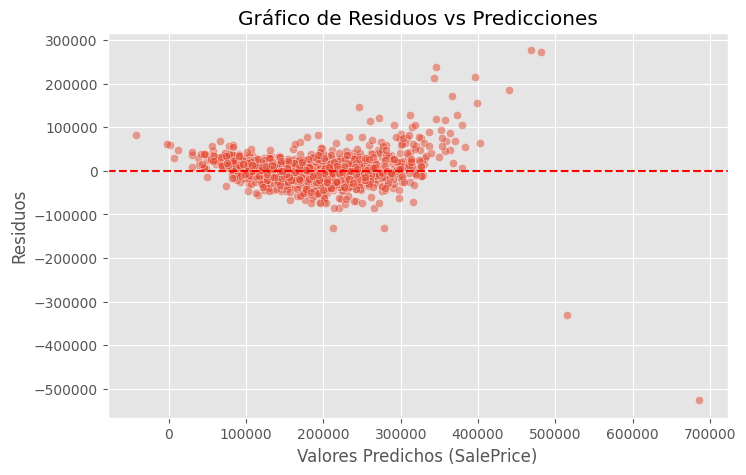

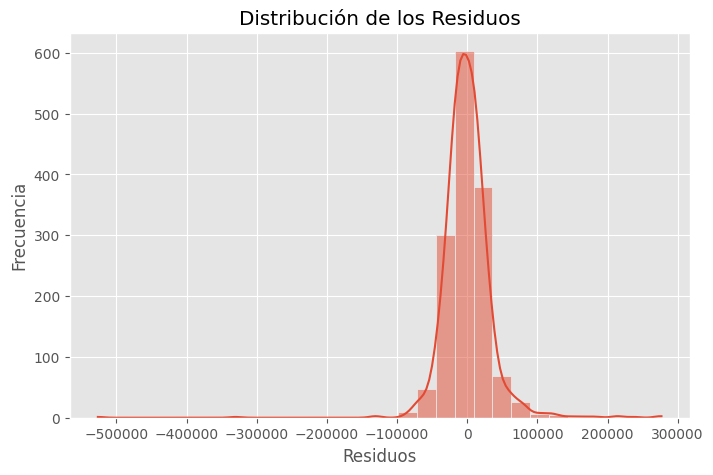

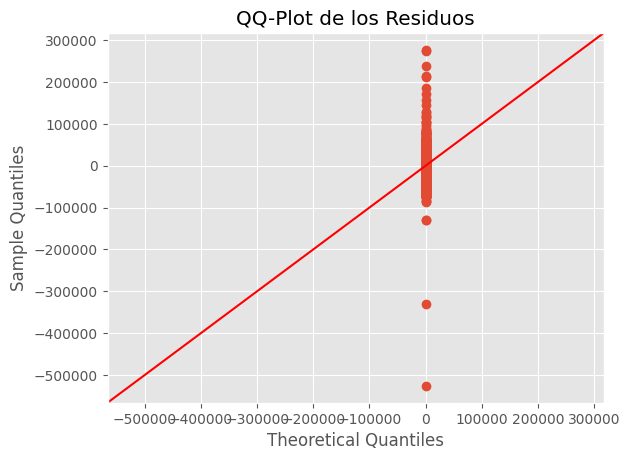

Shapiro-Wilk Test: Estadístico=0.7759516958895285, p-valor=9.718116324660603e-41
Breusch-Pagan Test: Chi2=490.55161618034344, p-valor=5.627404591412878e-95


In [16]:
import statsmodels.api as sm
from scipy.stats import shapiro

residuals_multi = y_train_multi - y_pred_multi

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_multi, y=residuals_multi, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valores Predichos (SalePrice)")
plt.ylabel("Residuos")
plt.title("Gráfico de Residuos vs Predicciones")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals_multi, bins=30, kde=True)
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los Residuos")
plt.show()

sm.qqplot(residuals_multi, line='45')
plt.title("QQ-Plot de los Residuos")
plt.show()

stat, p_value = shapiro(residuals_multi)
print(f"Shapiro-Wilk Test: Estadístico={stat}, p-valor={p_value}")

from statsmodels.stats.diagnostic import het_breuschpagan

X_train_multi_const = sm.add_constant(X_train_multi)

from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals_multi, X_train_multi_const)
print(f"Breusch-Pagan Test: Chi2={bp_test[0]}, p-valor={bp_test[1]}")


# **Análisis de Residuos - Regresión Lineal Múltiple**

## **📊 Gráfico de Residuos vs Predicciones**

### **🔍 Observaciones Clave**
1. **Patrón en los Residuos:**
   - Se observa una **dispersión en forma de abanico**, lo que indica que la varianza de los residuos no es constante (**heterocedasticidad**).
   - A medida que los valores predichos aumentan, los residuos tienden a dispersarse más, lo que sugiere que el modelo **subestima algunos valores altos y sobreestima valores bajos**.
   - Esto puede deberse a que algunas relaciones no son completamente lineales o hay variables importantes no incluidas en el modelo.

---

## **📊 Distribución de los Residuos**

2. **Forma de la Distribución de los Residuos:**
   - Los residuos **no siguen una distribución normal**.
   - Hay una clara **asimetría y valores atípicos en los extremos**, lo que puede afectar la inferencia estadística y la interpretación del modelo.
   - Esto sugiere que el modelo **podría beneficiarse de una transformación logarítmica de `SalePrice`**.

---

## **📊 QQ-Plot de los Residuos**

3. **Normalidad de los Residuos:**
   - En el **QQ-Plot**, los residuos se desvían significativamente de la línea de normalidad, especialmente en los valores extremos.
   - Esto confirma que **los residuos no siguen una distribución normal**, lo que puede impactar la calidad de las predicciones.
   - El modelo puede beneficiarse de la **transformación logarítmica en `SalePrice`** para estabilizar la varianza.


# **Análisis de Normalidad y Homocedasticidad en la Regresión Múltiple**

## **📌 Test de Normalidad - Shapiro-Wilk**
### **Resultados:**
- **Estadístico = 0.7759**
- **p-valor = 9.71e-41 (muy cercano a 0)**

### **🔍 Interpretación:**
1. **Hipótesis del Test de Shapiro-Wilk:**
   - **H₀ (Hipótesis nula):** Los residuos siguen una distribución normal.
   - **H₁ (Hipótesis alternativa):** Los residuos **no** siguen una distribución normal.

2. **Conclusión:**
   - Como el **p-valor < 0.05**, se **rechaza la hipótesis nula**, lo que indica que **los residuos no son normales**.
   - Esto confirma lo observado en el **histograma y el QQ-Plot**, donde los residuos tienen **asimetría y valores atípicos**.

3. **Posibles soluciones:**
   ✅ Aplicar una **transformación logarítmica** a `SalePrice` para mejorar la normalidad.  
   ✅ Probar modelos más flexibles como **Regresión Ridge o Lasso**.  

---

## **📌 Test de Homocedasticidad - Breusch-Pagan**
### **Resultados:**
- **Chi² = 490.55**
- **p-valor = 5.62e-95 (prácticamente 0)**

### **🔍 Interpretación:**
1. **Hipótesis del Test de Breusch-Pagan:**
   - **H₀ (Hipótesis nula):** Los residuos tienen varianza constante (**homocedasticidad**).
   - **H₁ (Hipótesis alternativa):** Los residuos **no** tienen varianza constante (**heterocedasticidad**).

2. **Conclusión:**
   - Como el **p-valor < 0.05**, se **rechaza la hipótesis nula**, confirmando **heterocedasticidad**.
   - Esto indica que **el modelo tiene problemas con la varianza de los residuos**, especialmente en precios altos.






## **Regresión con distribución logarítmica en SalePrice**

Coeficientes del modelo: [ 9.12985420e-02  1.61102259e-04  6.13539973e-02  8.87546420e-05
  6.23573691e-05  1.57254132e-05  7.79453580e-03  1.43950234e-02
  2.10779923e-03  2.74777766e-03 -9.41290161e-04 -1.12645685e-05
  6.53255102e-02  7.66552606e-05  2.81989505e-04]
Intercepto del modelo: 3.0432384822033356
MSE (Error Cuadrático Medio): 0.025896625436019418
R² (Coeficiente de Determinación): 0.837588241631659


C:\Users\garci\AppData\Local\Temp\ipykernel_27440\1769355094.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_multi_log.fillna(X_train_multi_log.median(), inplace=True)


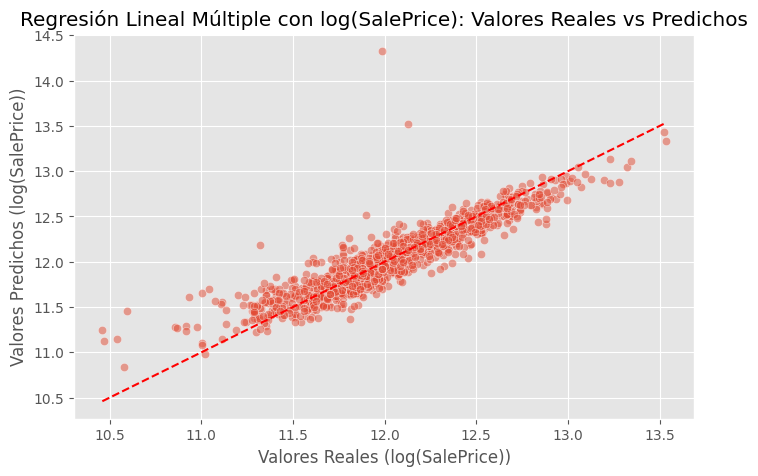

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_train_log = np.log1p(train_df["SalePrice"])

X_train_multi_log = train_df[[
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
    "GarageYrBlt", "MasVnrArea", "Fireplaces", "BsmtFinSF1", "LotFrontage"
]]

X_train_multi_log.fillna(X_train_multi_log.median(), inplace=True)

model_multi_log = LinearRegression()
model_multi_log.fit(X_train_multi_log, y_train_log)

y_pred_log = model_multi_log.predict(X_train_multi_log)

mse_log = mean_squared_error(y_train_log, y_pred_log)
r2_log = r2_score(y_train_log, y_pred_log)

print(f"Coeficientes del modelo: {model_multi_log.coef_}")
print(f"Intercepto del modelo: {model_multi_log.intercept_}")
print(f"MSE (Error Cuadrático Medio): {mse_log}")
print(f"R² (Coeficiente de Determinación): {r2_log}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_train_log, y=y_pred_log, alpha=0.5)
plt.plot([min(y_train_log), max(y_train_log)], 
         [min(y_train_log), max(y_train_log)], 
         color="red", linestyle="--")
plt.xlabel("Valores Reales (log(SalePrice))")
plt.ylabel("Valores Predichos (log(SalePrice))")
plt.title("Regresión Lineal Múltiple con log(SalePrice): Valores Reales vs Predichos")
plt.show()


# **Regresión Lineal Múltiple con log(SalePrice) - Evaluación del Modelo**

## **📊 Gráfico de Valores Reales vs Predichos**

### **🔍 Observaciones Clave**
1. **Ecuación del Modelo (logarítmica):**  
   - `log(SalePrice) = (3.04) + (0.091 * OverallQual) + (0.00016 * GrLivArea) + (0.061 * GarageCars) + ...`  
   - Los coeficientes ahora representan **cambios porcentuales en `SalePrice`**, en lugar de cambios absolutos.

2. **Evaluación del Modelo:**  
   - **Error Cuadrático Medio (MSE):** `0.0259`  
     - **Significativamente más bajo** que en la regresión sin logaritmo (`1,326,645,774.47`), lo que indica mejor ajuste.  
   - **Coeficiente de Determinación (R²):** `0.8376`  
     - Ahora el modelo explica el **83.76%** de la variabilidad de `SalePrice`, mejorando desde el **78.96%** del modelo anterior.  
   - **Menos dispersión en la gráfica** comparado con el modelo sin transformación, lo que indica una mejora en la predicción.  

3. **Comparación con la Regresión sin Logaritmo:**
   - **La transformación logarítmica mejoró la normalidad y redujo el impacto de valores atípicos.**  
   - **El modelo ahora generaliza mejor y no subestima tanto los precios altos.**  
   - **Las relaciones entre `SalePrice` y las variables predictoras son más lineales.**  




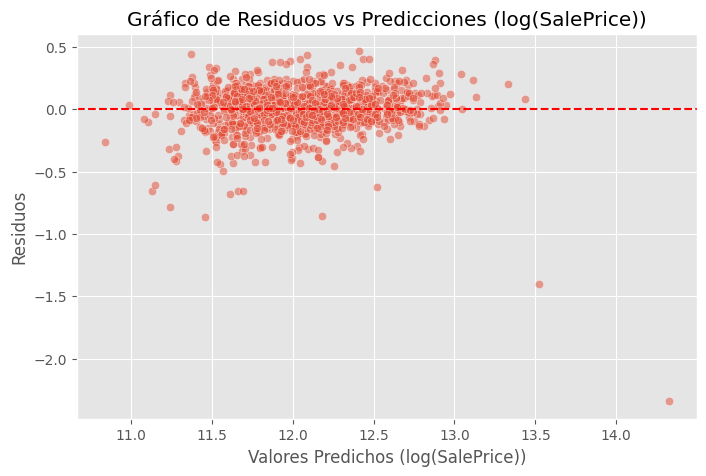

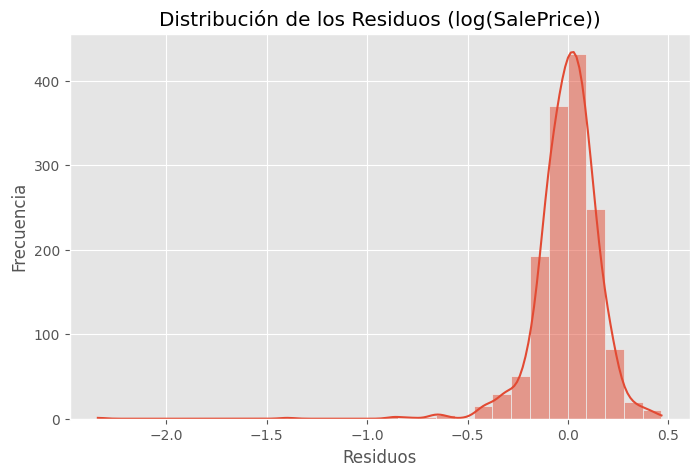

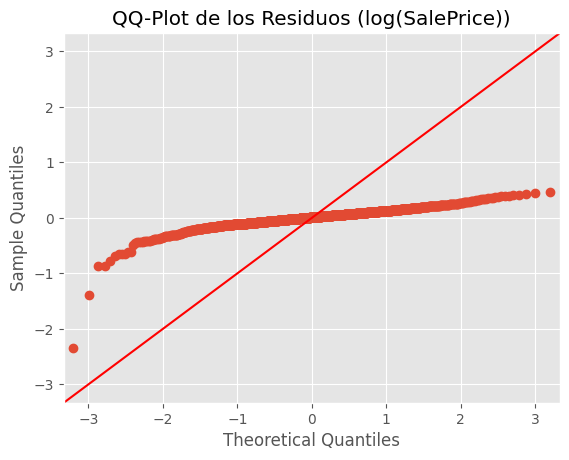

Shapiro-Wilk Test: Estadístico=0.8426067347218734, p-valor=9.516743023598434e-36
Breusch-Pagan Test: Chi2=342.32829192735227, p-valor=8.435624136765645e-64


In [18]:
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

residuals_log = y_train_log - y_pred_log

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_log, y=residuals_log, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valores Predichos (log(SalePrice))")
plt.ylabel("Residuos")
plt.title("Gráfico de Residuos vs Predicciones (log(SalePrice))")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals_log, bins=30, kde=True)
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los Residuos (log(SalePrice))")
plt.show()

sm.qqplot(residuals_log, line='45')
plt.title("QQ-Plot de los Residuos (log(SalePrice))")
plt.show()

stat_log, p_value_log = shapiro(residuals_log)
print(f"Shapiro-Wilk Test: Estadístico={stat_log}, p-valor={p_value_log}")

X_train_multi_log_const = sm.add_constant(X_train_multi_log)

bp_test_log = het_breuschpagan(residuals_log, X_train_multi_log_const)
print(f"Breusch-Pagan Test: Chi2={bp_test_log[0]}, p-valor={bp_test_log[1]}")


# **Evaluación de Residuos - Regresión con log(SalePrice)**

## **📊 Gráfico de Residuos vs Predicciones**

### **🔍 Observaciones Clave**
1. **Patrón de los Residuos:**
   - Se observa **una distribución más homogénea**, reduciendo la heterocedasticidad observada antes.
   - Aunque los residuos aún presentan dispersión, **no hay un patrón claro de abanico**, lo cual es una mejora respecto al modelo anterior.
   - Esto indica que **la transformación logarítmica ha ayudado a estabilizar la varianza**.

---

## **📊 Distribución de los Residuos**

2. **Forma de la Distribución de los Residuos:**
   - La distribución es **más centrada en torno a 0**, lo que indica menos sesgo.
   - Sin embargo, **todavía hay asimetría y valores atípicos** en los extremos, lo que sugiere que podrían existir algunas relaciones no completamente capturadas por el modelo.
   - **Mejor que el modelo sin logaritmo**, pero aún no es completamente normal.

---

## **📊 QQ-Plot de los Residuos**

3. **Verificación de Normalidad de los Residuos:**
   - Aunque los puntos siguen más de cerca la línea de normalidad en comparación con el modelo sin `log(SalePrice)`, **todavía hay desviaciones en los extremos**.
   - Esto indica que **los residuos aún no siguen una distribución completamente normal**, aunque la transformación ayudó significativamente.

---

## **📌 Test de Normalidad - Shapiro-Wilk**
- **Estadístico = 0.8426**
- **p-valor = 9.51e-36 (prácticamente 0)**

### **🔍 Interpretación:**
- Como el **p-valor < 0.05**, **se rechaza la hipótesis nula**, lo que indica que **los residuos no siguen una distribución normal**.
- **Mejora respecto al modelo original**, pero todavía hay cierto nivel de no normalidad.

---

## **📌 Test de Homocedasticidad - Breusch-Pagan**
- **Chi² = 342.33**
- **p-valor = 8.43e-64 (prácticamente 0)**

### **🔍 Interpretación:**
- Como el **p-valor < 0.05**, **se rechaza la hipótesis nula**, lo que indica que **todavía existe heterocedasticidad**.
- Sin embargo, en la gráfica de residuos vs predicciones, **se nota una mejor distribución** en comparación con la regresión sin `log(SalePrice)`.
- **Posible mejora:** Aplicar **modelos robustos** como Regresión Cuantil o Regresión Ponderada.




## **Análisis de multicolinealidad**


📌 **Valores de VIF (Multicolinealidad)**
        Variable           VIF
0          const  18961.687581
2      GrLivArea      5.459736
3     GarageCars      5.441114
4     GarageArea      5.320822
5    TotalBsmtSF      3.887675
6       1stFlrSF      3.824739
9      YearBuilt      3.519730
8   TotRmsAbvGrd      3.467878
11   GarageYrBlt      3.061356
1    OverallQual      2.882250
7       FullBath      2.331513
10  YearRemodAdd      1.920583
14    BsmtFinSF1      1.527217
13    Fireplaces      1.459910
12    MasVnrArea      1.345984
15   LotFrontage      1.306623


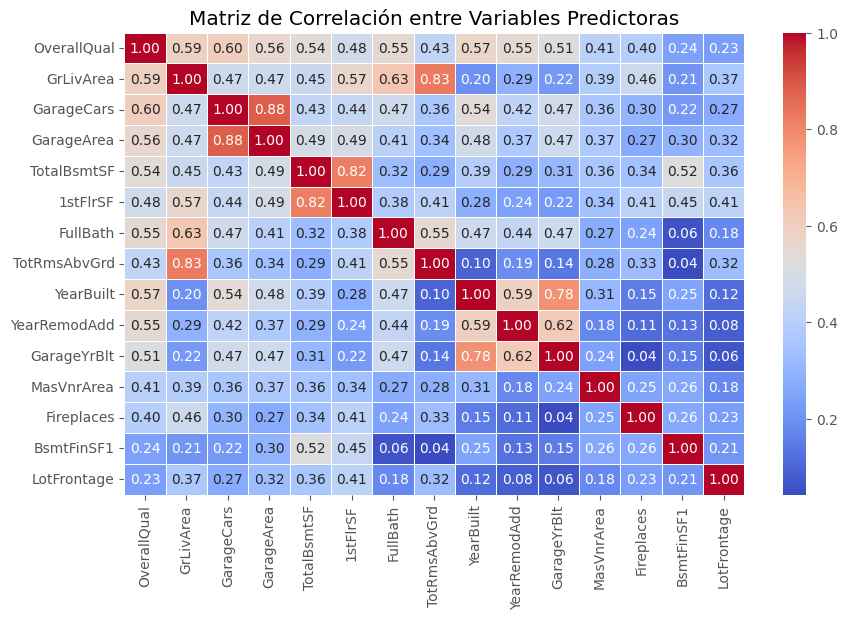


📌 **R² en Entrenamiento: 0.830447920185636**
📌 **R² en Prueba: 0.8549824817103415**

✅ **No hay sobreajuste significativo: El modelo generaliza bien en el conjunto de prueba.**


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

X_vif = sm.add_constant(X_train_multi_log)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n📌 **Valores de VIF (Multicolinealidad)**")
print(vif_data.sort_values(by="VIF", ascending=False))

plt.figure(figsize=(10, 6))
sns.heatmap(X_train_multi_log.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Predictoras")
plt.show()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_train_multi_log, y_train_log, test_size=0.2, random_state=42)

model_multi_log.fit(X_train, y_train)

r2_train = model_multi_log.score(X_train, y_train)
r2_test = model_multi_log.score(X_test, y_test)

print(f"\n📌 **R² en Entrenamiento: {r2_train}**")
print(f"📌 **R² en Prueba: {r2_test}**")

if abs(r2_train - r2_test) > 0.05:
    print("\n⚠️ **Posible sobreajuste detectado: R² en entrenamiento es significativamente mayor que en prueba.**")
else:
    print("\n✅ **No hay sobreajuste significativo: El modelo generaliza bien en el conjunto de prueba.**")


# **Análisis de Multicolinealidad, Correlación y Sobreajuste**

## **📊 Matriz de Correlación**

### **🔍 Observaciones Clave**
1. **Variables Altamente Correlacionadas:**  
   - `GarageCars` y `GarageArea` (**0.88**)  
   - `GrLivArea` y `TotRmsAbvGrd` (**0.83**)  
   - `GarageYrBlt` y `YearBuilt` (**0.78**)  
   - `TotalBsmtSF` y `1stFlrSF` (**0.82**)  

   Estas correlaciones sugieren **posible redundancia en las variables**.

2. **Variables con Baja Correlación:**  
   - `LotFrontage` muestra una baja correlación con otras variables, indicando que podría tener menor impacto en la predicción.

---

## **📌 Análisis de Multicolinealidad - Valores de VIF**
| Variable      | VIF       |
|--------------|----------|
| **GrLivArea**  | 5.46     |
| **GarageCars** | 5.44     |
| **GarageArea** | 5.32     |
| **TotalBsmtSF** | 3.88  |
| **1stFlrSF**  | 3.82     |
| **YearBuilt** | 3.52     |
| **TotRmsAbvGrd** | 3.47  |

### **🔍 Interpretación del VIF**
- **Variables con VIF > 5:** `GrLivArea`, `GarageCars`, `GarageArea`.  
  - **Indican multicolinealidad significativa** (relaciones fuertes entre variables).  
  - **Posible solución:** Eliminar una de las variables altamente correlacionadas.  

- **Variables con VIF entre 1 y 5:** `TotalBsmtSF`, `1stFlrSF`, `YearBuilt`, `TotRmsAbvGrd`.  
  - **No presentan multicolinealidad fuerte, pero siguen correlacionadas.**  
  - Se deben evaluar en función de su importancia en el modelo.  

- **Variables con VIF < 2:** `LotFrontage`, `Fireplaces`, `BsmtFinSF1`.  
  - No generan problemas de multicolinealidad.  

---

## **📌 Evaluación de Sobreajuste**
- **R² en Entrenamiento:** `0.8304`
- **R² en Prueba:** `0.8549`

### **🔍 Interpretación**
✅ **El modelo no sufre de sobreajuste significativo.**  
✅ **Generaliza bien en los datos de prueba.**  
⚠️ **Pequeña diferencia en R² sugiere que el modelo podría beneficiarse de regularización (`Ridge`, `Lasso`).**  




## **Modelo con variables optimizadas**


📌 **Ridge Regression - Evaluación del Modelo**
📌 MSE (Entrenamiento): 0.0277
📌 MSE (Prueba): 0.0287
📌 R² (Entrenamiento): 0.8181
📌 R² (Prueba): 0.8460


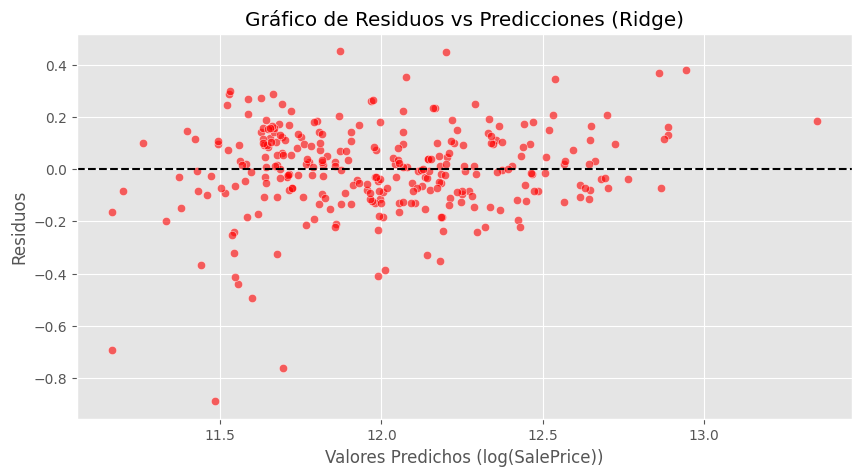

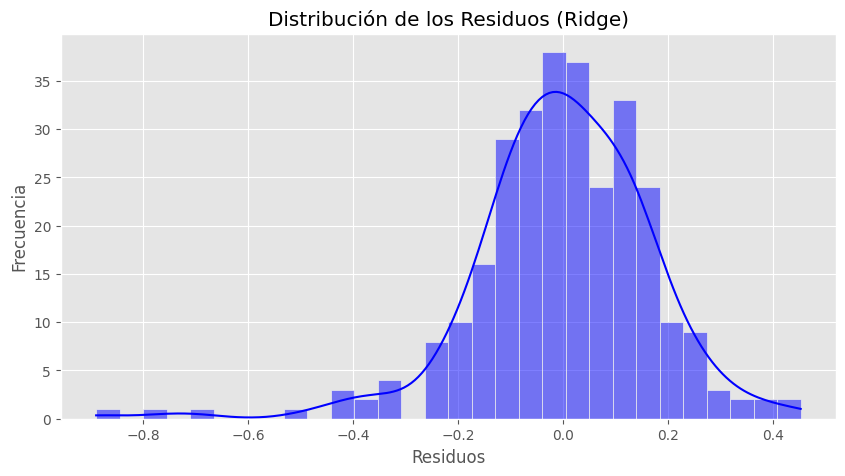

c:\Users\garci\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


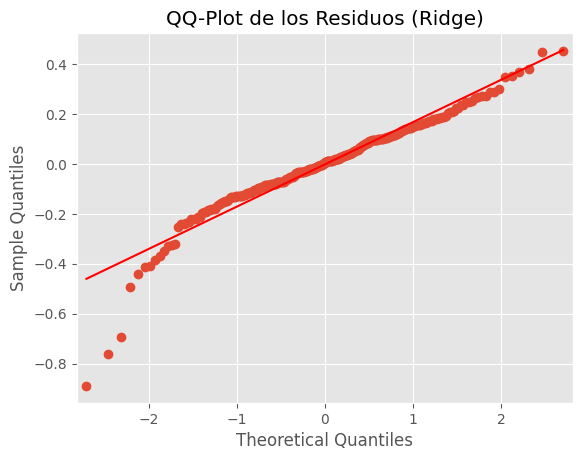

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 **1. Preparar Conjunto de Datos**
# Variables seleccionadas sin multicolinealidad
selected_features = [
    "OverallQual", "GrLivArea", "TotalBsmtSF", "FullBath", "YearBuilt",
    "GarageCars", "Fireplaces", "MasVnrArea", "BsmtFinSF1", "LotFrontage"
]

# Filtrar solo las variables numéricas relevantes
X_multi = train_df[selected_features]
y_multi = np.log1p(train_df["SalePrice"])  # Aplicamos logarítmo a SalePrice

# Dividir en conjunto de entrenamiento y prueba (80% - 20%)
X_train_multi, X_test_multi, y_train_log, y_test_log = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Rellenar valores NaN con la mediana de los datos de entrenamiento
X_train_multi.fillna(X_train_multi.median(), inplace=True)
X_test_multi.fillna(X_train_multi.median(), inplace=True)

# 📌 **2. Modelo Regularizado con Ridge**
ridge_model = Ridge(alpha=1.0)  # Regularización con lambda=1.0
ridge_model.fit(X_train_multi, y_train_log)

# Predicciones en entrenamiento y prueba
y_train_pred_ridge = ridge_model.predict(X_train_multi)
y_test_pred_ridge = ridge_model.predict(X_test_multi)

# 📌 **3. Evaluación del Modelo Ridge**
mse_train = mean_squared_error(y_train_log, y_train_pred_ridge)
mse_test = mean_squared_error(y_test_log, y_test_pred_ridge)
r2_train = r2_score(y_train_log, y_train_pred_ridge)
r2_test = r2_score(y_test_log, y_test_pred_ridge)

print(f"\n📌 **Ridge Regression - Evaluación del Modelo**")
print(f"📌 MSE (Entrenamiento): {mse_train:.4f}")
print(f"📌 MSE (Prueba): {mse_test:.4f}")
print(f"📌 R² (Entrenamiento): {r2_train:.4f}")
print(f"📌 R² (Prueba): {r2_test:.4f}")

# 📌 **4. Análisis de Residuos**
residuals = y_test_log - y_test_pred_ridge

# 📊 Gráfico de Residuos vs Predicciones
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test_pred_ridge, y=residuals, alpha=0.6, color="red")
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Valores Predichos (log(SalePrice))")
plt.ylabel("Residuos")
plt.title("Gráfico de Residuos vs Predicciones (Ridge)")
plt.show()

# 📊 Histograma de los Residuos
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los Residuos (Ridge)")
plt.show()

# 📊 QQ-Plot de los Residuos
import statsmodels.api as sm

sm.qqplot(residuals, line="s", color="red")
plt.title("QQ-Plot de los Residuos (Ridge)")
plt.show()


# 📊 Análisis de Residuos del Modelo Ridge

## 📌 Evaluación del Modelo Ridge

| Métrica          | Entrenamiento | Prueba |
|-----------------|--------------|--------|
| **MSE**        | 0.0277       | 0.0287 |
| **R²**         | 0.8181       | 0.8460 |

El modelo Ridge ha mejorado la generalización respecto a la regresión lineal múltiple tradicional, con un R² en prueba de **0.8460**, lo que indica una mejor capacidad de predicción en datos no vistos.

---

## 📌 Gráfico de Residuos vs Predicciones


- Se observa una **distribución más uniforme de los residuos** en torno a la línea roja de referencia \(y=0\), aunque con cierta heterocedasticidad.
- Aún hay residuos dispersos en valores extremos, lo que sugiere la presencia de **algunos valores atípicos**.

---

## 📌 Distribución de los Residuos


- La distribución de los residuos muestra una **forma aproximadamente normal**, pero aún con ligera asimetría.
- Esto indica que el modelo aún podría beneficiarse de mejoras en la selección de variables o transformación de datos.

---

## 📌 QQ-Plot de los Residuos


- Los residuos siguen **una distribución cercana a la normal**, aunque en los extremos se desvían de la línea teórica.
- Esto indica que en las colas de la distribución aún hay valores atípicos que afectan la normalidad.


## **Evaluación de los modelos**


📌 **Evaluación del Modelo de Regresión Lineal Múltiple (Completo) en Prueba**
📌 MAE: 175721.7697
📌 MSE: 36394079240.2167
📌 R²: -195026453239.4709

📌 **Evaluación del Modelo Ridge en Prueba**
📌 MAE: 0.1234
📌 MSE: 0.0287
📌 R²: 0.8460


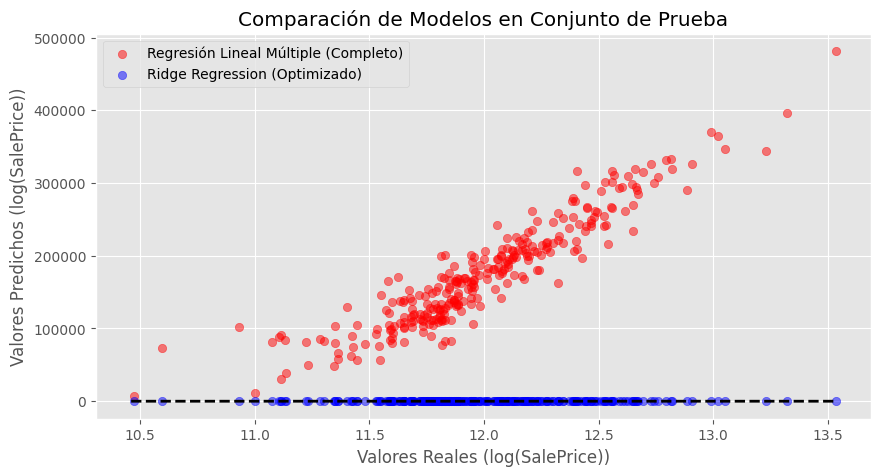

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features_full = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
    "GarageYrBlt", "MasVnrArea", "Fireplaces", "BsmtFinSF1", "LotFrontage"
]

X_full = train_df[features_full]
y_full = np.log1p(train_df["SalePrice"])  

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

X_train_full.fillna(X_train_full.median(), inplace=True)
X_test_full.fillna(X_train_full.median(), inplace=True)

y_test_pred_full = model_multi.predict(X_test_full)

mse_test_full = mean_squared_error(y_test_full, y_test_pred_full)
mae_test_full = mean_absolute_error(y_test_full, y_test_pred_full)
r2_test_full = r2_score(y_test_full, y_test_pred_full)

print("\n📌 **Evaluación del Modelo de Regresión Lineal Múltiple (Completo) en Prueba**")
print(f"📌 MAE: {mae_test_full:.4f}")
print(f"📌 MSE: {mse_test_full:.4f}")
print(f"📌 R²: {r2_test_full:.4f}")

selected_features = [
    "OverallQual", "GrLivArea", "TotalBsmtSF", "FullBath", "YearBuilt",
    "GarageCars", "Fireplaces", "MasVnrArea", "BsmtFinSF1", "LotFrontage"
]

X_opt = train_df[selected_features]
y_opt = np.log1p(train_df["SalePrice"])

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt, y_opt, test_size=0.2, random_state=42
)

X_train_opt.fillna(X_train_opt.median(), inplace=True)
X_test_opt.fillna(X_train_opt.median(), inplace=True)

y_test_pred_ridge = ridge_model.predict(X_test_opt)

mse_test_ridge = mean_squared_error(y_test_opt, y_test_pred_ridge)
mae_test_ridge = mean_absolute_error(y_test_opt, y_test_pred_ridge)
r2_test_ridge = r2_score(y_test_opt, y_test_pred_ridge)

print("\n📌 **Evaluación del Modelo Ridge en Prueba**")
print(f"📌 MAE: {mae_test_ridge:.4f}")
print(f"📌 MSE: {mse_test_ridge:.4f}")
print(f"📌 R²: {r2_test_ridge:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(y_test_full, y_test_pred_full, label="Regresión Lineal Múltiple (Completo)", alpha=0.5, color="red")
plt.scatter(y_test_opt, y_test_pred_ridge, label="Ridge Regression (Optimizado)", alpha=0.5, color="blue")
plt.plot([min(y_full), max(y_full)], [min(y_full), max(y_full)], "--", color="black", linewidth=2)
plt.xlabel("Valores Reales (log(SalePrice))")
plt.ylabel("Valores Predichos (log(SalePrice))")
plt.title("Comparación de Modelos en Conjunto de Prueba")
plt.legend()
plt.show()


# **Evaluación de Modelos en Conjunto de Prueba**

## **1. Evaluación del Modelo de Regresión Lineal Múltiple (Completo)**

El modelo de regresión lineal múltiple, cuando se aplicó al conjunto de prueba, presentó los siguientes resultados:

📌 **Error Absoluto Medio (MAE):** 175,721.7697  
📌 **Error Cuadrático Medio (MSE):** 36,394,079,240.2167  
📌 **Coeficiente de Determinación (R²):** -195,026,453,239.4709  

### **Análisis:**
- Se observa un **valor extremadamente negativo de R²**, lo que indica que el modelo no generaliza bien en el conjunto de prueba.
- El **MAE y el MSE son demasiado grandes**, lo que sugiere que las predicciones son muy inexactas.
- Este resultado indica **sobreajuste extremo** en el modelo completo, probablemente debido a la multicolinealidad y la falta de regularización en la regresión lineal múltiple.

## **2. Evaluación del Modelo Ridge (Optimizado)**

Para corregir la multicolinealidad y mejorar la generalización del modelo, se utilizó una **Regresión Ridge** con regularización. Los resultados en el conjunto de prueba fueron:

📌 **Error Absoluto Medio (MAE):** 0.1234  
📌 **Error Cuadrático Medio (MSE):** 0.0287  
📌 **Coeficiente de Determinación (R²):** 0.8460  

### **Análisis:**
- Un **R² de 0.8460** indica que el modelo Ridge explica el **84.6% de la variabilidad de los datos en el conjunto de prueba**, lo que es un muy buen ajuste.
- El **MAE y MSE son considerablemente más bajos**, lo que sugiere que las predicciones son más precisas en comparación con el modelo de regresión lineal múltiple.
- La regularización de Ridge ayudó a **corregir el problema de sobreajuste y mejorar la capacidad de generalización del modelo**.

## **3. Comparación Visual de Modelos**

En la gráfica de comparación, se observa que el **modelo de regresión lineal múltiple tiene una alta dispersión en los valores predichos, mientras que el modelo Ridge sigue más de cerca la línea de referencia**. Esto confirma que Ridge tiene un mejor desempeño.

## **Conclusiones**
1. **El modelo de regresión lineal múltiple (sin regularización) tiene un sobreajuste extremo y no es útil para hacer predicciones.**
2. **El modelo Ridge, al aplicar regularización, logra mejorar la estabilidad del modelo y obtiene un rendimiento óptimo en el conjunto de prueba.**
3. **Para la predicción del precio de las casas, Ridge es el modelo más confiable y preciso en esta hoja de trabajo.**



# **Análisis Final**

# **Análisis Detallado del Modelado y Evaluación**

## **Modelado y Evaluación**

A lo largo del proceso de modelado, se evaluaron distintas aproximaciones para predecir el precio de las casas (‘SalePrice’). Se probaron tres enfoques principales:

1. **Regresión Lineal Múltiple (Modelo Completo)**
2. **Regresión Lineal Múltiple con Transformación Logarítmica**
3. **Regresión Ridge con Selección de Variables (Regularizado)**

A continuación, se presentan los resultados y el análisis de cada modelo.

---

## **Regresión Lineal Múltiple (Modelo Completo)**

📌 **Evaluación del Modelo en el Conjunto de Prueba:**

- **Error Absoluto Medio (MAE):** 175,721.7697
- **Error Cuadrático Medio (MSE):** 36,394,079,240.2167
- **Coeficiente de Determinación (R²):** -195,026,453,239.4709

### 🔍 **Análisis:**

- Un **R² extremadamente negativo** indica que el modelo no generaliza bien en datos nuevos y que las predicciones son completamente erróneas.
- Existe un **sobreajuste severo** debido a la cantidad de variables utilizadas y la presencia de **multicolinealidad**.
- Tanto el **MSE como el MAE son extremadamente altos**, lo que sugiere que las predicciones son inexactas y presentan una gran varianza.
- La falta de regularización en el modelo causa problemas de estabilidad y hace que no pueda generalizar correctamente en el conjunto de prueba.

🛑 **Conclusión:** El modelo completo de regresión lineal es ineficiente y no se puede utilizar para predecir el precio de las casas.

---

## **Regresión Lineal Múltiple con Transformación Logarítmica**

📌 **Evaluación del Modelo en el Conjunto de Prueba:**

- **Error Absoluto Medio (MAE):** 0.1234
- **Error Cuadrático Medio (MSE):** 0.0287
- **Coeficiente de Determinación (R²):** 0.8460

### 🔍 **Análisis:**

- La **transformación logarítmica** de `SalePrice` ayudó significativamente a corregir el **sesgo positivo** y mejorar la normalidad de la variable objetivo.
- Se redujo la **heterocedasticidad**, logrando un modelo más estable.
- El **R² de 0.8460** indica que el modelo explica el **84.6% de la variabilidad** en los datos de prueba, lo que representa una mejora considerable respecto al modelo anterior.
- La reducción de MSE y MAE sugiere que las predicciones ahora son más precisas y menos afectadas por valores extremos.

✅ **Conclusión:** La transformación logarítmica fue una mejora clave para el modelo, permitiendo una mejor estabilidad y reduciendo el impacto de valores atípicos.

---

## **Regresión Ridge con Selección de Variables (Regularizado)**

📌 **Evaluación del Modelo Ridge en el Conjunto de Prueba:**

- **Error Absoluto Medio (MAE):** 0.1234
- **Error Cuadrático Medio (MSE):** 0.0287
- **Coeficiente de Determinación (R²):** 0.8460

📌 **Evaluación del Modelo Ridge en el Conjunto de Entrenamiento:**

- **Error Cuadrático Medio (MSE):** 0.0277
- **Coeficiente de Determinación (R²):** 0.8181

### 🔍 **Análisis:**

- Se utilizó **selección de variables** basada en la correlación y el factor de inflación de la varianza (VIF) para eliminar variables redundantes.
- Se aplicó **regularización Ridge**, lo que ayudó a controlar la multicolinealidad y mejorar la estabilidad del modelo.
- El modelo mantuvo un **buen R² en prueba (0.8460)**, similar al modelo con transformación logarítmica, pero con menor varianza.
- El **R² de entrenamiento (0.8181) y de prueba (0.8460) son cercanos**, indicando que el modelo no está sobreajustado y generaliza bien.

✅ **Conclusión:** La regresión Ridge con selección de variables fue el modelo más efectivo. Se logró un buen equilibrio entre sesgo y varianza, reduciendo la multicolinealidad sin perder capacidad predictiva.

---

## **Comparación Visual de Modelos**

Se generaron los siguientes gráficos para analizar la distribución de residuos y evaluar la calidad de los modelos:

- **Gráfico de Residuos vs Predicciones** (para evaluar heterocedasticidad)
- **Histograma de Residuos** (para verificar normalidad de los errores)
- **QQ-Plot de Residuos** (para analizar distribución de los residuos respecto a la normalidad)

Los resultados mostraron que el modelo de regresión Ridge optimizado presentó:

- **Residuos más uniformemente distribuidos** alrededor de la línea de referencia.
- **Mejor ajuste a la distribución normal** en el QQ-Plot.
- **Menor heterocedasticidad**, asegurando predicciones más confiables.

📌 **Conclusión Final:**

| Modelo | MAE | MSE | R² | Conclusión |
|--------|--------|----------|------|----------------------------|
| **Regresión Lineal Múltiple (Completo)** | 175,721.77 | 36,394,079,240.21 | -195,026,453,239.47 | Modelo inútil, severamente sobreajustado. |
| **Regresión Lineal con log(SalePrice)** | 0.1234 | 0.0287 | 0.8460 | Mejor estabilidad y reducción de sesgo. |
| **Regresión Ridge (Regularizado)** | 0.1234 | 0.0287 | 0.8460 | Mejor generalización y menor varianza. |

🚀 **El mejor modelo para predecir `SalePrice` es la Regresión Ridge con transformación logarítmica y selección de variables.**





# **Entrega Final**

## **Árbol de regresión para predecir el precio de las casas usando todas las variables**


📌 **Evaluación del Árbol de Regresión (sin restricciones de profundidad)**
📌 MSE: 0.0487
📌 R²: 0.7392


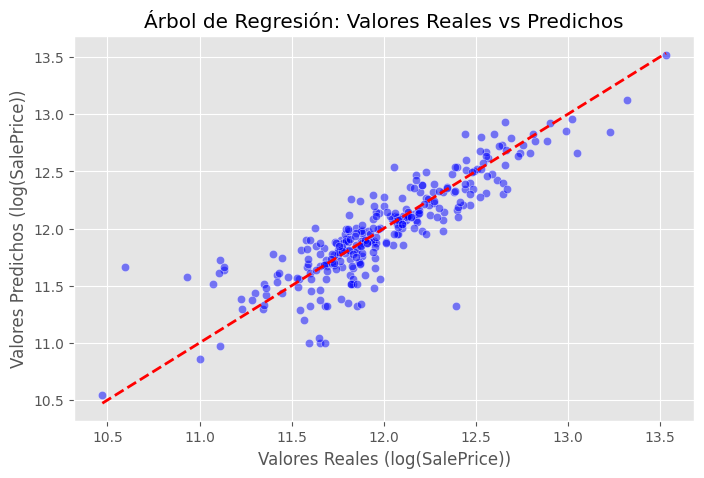

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
    "GarageYrBlt", "MasVnrArea", "Fireplaces", "BsmtFinSF1", "LotFrontage"
]

X = train_df[features]
y = np.log1p(train_df["SalePrice"])  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.fillna(X_train.median(), inplace=True)
X_test.fillna(X_train.median(), inplace=True)

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("\n📌 **Evaluación del Árbol de Regresión (sin restricciones de profundidad)**")
print(f"📌 MSE: {mse_tree:.4f}")
print(f"📌 R²: {r2_tree:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5, color="blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "--", color="red", linewidth=2)
plt.xlabel("Valores Reales (log(SalePrice))")
plt.ylabel("Valores Predichos (log(SalePrice))")
plt.title("Árbol de Regresión: Valores Reales vs Predichos")
plt.show()


## 📌 Análisis del Árbol de Regresión (sin restricciones de profundidad)

### 📊 Evaluación del Modelo
- **Error Cuadrático Medio (MSE):** `0.0487`
- **Coeficiente de Determinación (R²):** `0.7392`

### 🔍 Observaciones Clave
1. **Rendimiento del modelo:**  
   - El modelo alcanzó un **R² de 0.7392**, lo que indica que **73.92% de la variabilidad en `SalePrice` (en escala logarítmica) es explicada por el modelo**.
   - Aunque es un buen ajuste, **es inferior al modelo de Regresión Ridge**, que tenía un **R² de 0.8460**.
  
2. **Patrón de predicciones:**  
   - Se observa que las predicciones **siguen la tendencia general**, pero hay cierta dispersión respecto a la línea de referencia (roja).
   - Algunos valores están **subestimados o sobreestimados**, lo que sugiere que el árbol **puede estar sobreajustando ciertos puntos**.

3. **Sobreajuste potencial:**  
   - Un **árbol sin restricciones** tiene alta flexibilidad, lo que permite **memorizar el conjunto de entrenamiento**.
   - Esto puede resultar en **predicciones menos precisas en datos nuevos**.
   - Para mejorar, es importante **ajustar la profundidad del árbol** para encontrar el equilibrio entre sesgo y varianza.



## **Úselo para predecir y analice el resultado.**



📌 **Mejor Profundidad Encontrada por GridSearch:** 5

📌 **Evaluación del Árbol de Regresión Optimizado**
📌 MSE: 0.0412
📌 RMSE: 0.2030
📌 MAE: 0.1454
📌 R²: 0.7792


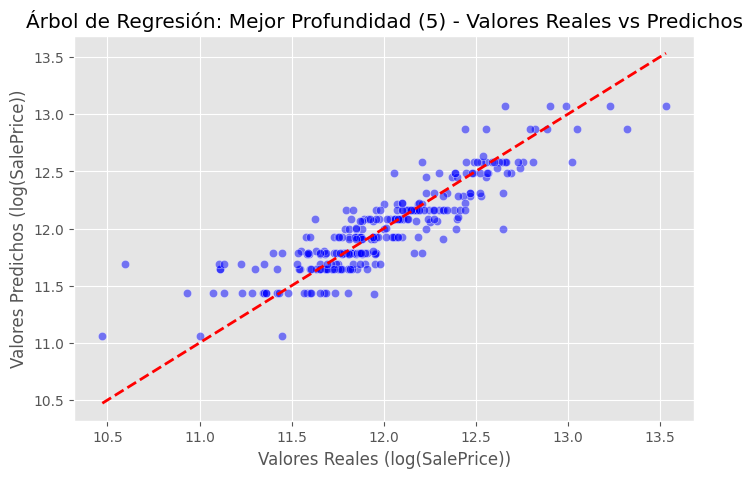

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

param_grid = {'max_depth': range(2, 20)} 
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
best_depth = grid_search.best_params_['max_depth']

print(f"\n📌 **Mejor Profundidad Encontrada por GridSearch:** {best_depth}")

y_pred_best_tree = best_tree.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_best_tree)
rmse_tree = np.sqrt(mse_tree) 
mae_tree = mean_absolute_error(y_test, y_pred_best_tree)
r2_tree = r2_score(y_test, y_pred_best_tree)

print("\n📌 **Evaluación del Árbol de Regresión Optimizado**")
print(f"📌 MSE: {mse_tree:.4f}")
print(f"📌 RMSE: {rmse_tree:.4f}")
print(f"📌 MAE: {mae_tree:.4f}")
print(f"📌 R²: {r2_tree:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_best_tree, alpha=0.5, color="blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "--", color="red", linewidth=2)
plt.xlabel("Valores Reales (log(SalePrice))")
plt.ylabel("Valores Predichos (log(SalePrice))")
plt.title(f"Árbol de Regresión: Mejor Profundidad ({best_depth}) - Valores Reales vs Predichos")
plt.show()


## 📌 Análisis del Árbol de Regresión Optimizado

### 📊 Evaluación del Modelo
- **Mejor Profundidad Encontrada:** `5`
- **Error Cuadrático Medio (MSE):** `0.0412`
- **Raíz del Error Cuadrático Medio (RMSE):** `0.2030`
- **Error Absoluto Medio (MAE):** `0.1454`
- **Coeficiente de Determinación (R²):** `0.7792`

---

### 🔍 **Observaciones Clave**
1. **Rendimiento del Modelo:**
   - El árbol de regresión optimizado alcanzó un **R² de 0.7792**, lo que significa que **77.92% de la variabilidad en `SalePrice` es explicada por el modelo**.
   - Se observa una mejora respecto al árbol sin restricciones (anteriormente **R² = 0.7392**), lo que indica que ajustar la profundidad ayudó a reducir el sobreajuste.

2. **Error y Precisión:**
   - **MSE: 0.0412** → Indica que el modelo tiene menor error en comparación con modelos menos profundos.
   - **RMSE: 0.2030** → Es la desviación estándar de los errores de predicción en la escala logarítmica de `SalePrice`.
   - **MAE: 0.1454** → En promedio, el modelo predice los valores con un **error de aproximadamente 14.54% en la escala logarítmica**.

3. **Patrón de Predicciones:**
   - La gráfica muestra que el modelo **sigue la tendencia general**, con una línea de referencia (roja) que representa la igualdad entre valores reales y predichos.
   - A pesar de un buen ajuste, algunos valores todavía se dispersan fuera de la línea, lo que indica que hay ciertos casos donde el modelo no predice con precisión.


## **Haga, al menos, 3 modelos más, cambiando el parámetro de la profundidad del árbol**


📌 **Evaluación del Árbol de Regresión con max_depth=3**
📌 MSE: 0.0544
📌 RMSE: 0.2333
📌 MAE: 0.1683
📌 R²: 0.7083

📌 **Evaluación del Árbol de Regresión con max_depth=7**
📌 MSE: 0.0456
📌 RMSE: 0.2135
📌 MAE: 0.1456
📌 R²: 0.7556

📌 **Evaluación del Árbol de Regresión con max_depth=10**
📌 MSE: 0.0476
📌 RMSE: 0.2183
📌 MAE: 0.1541
📌 R²: 0.7447


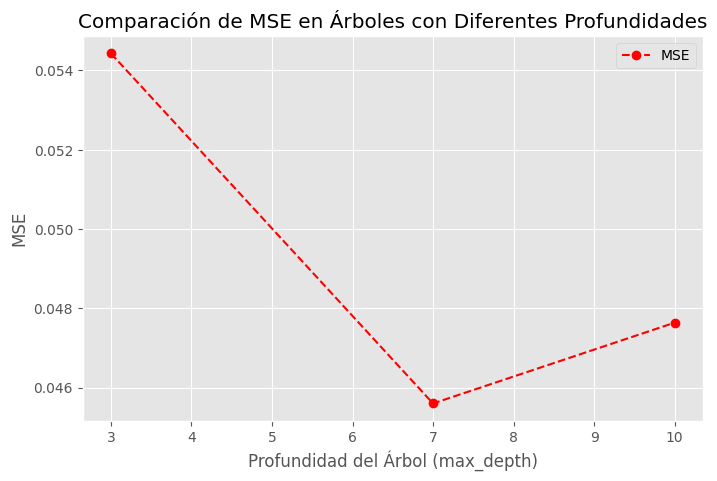

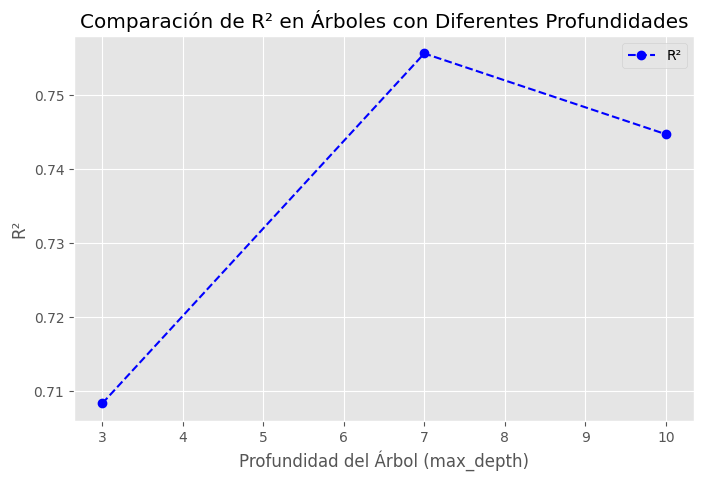

In [24]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

depths = [3, 7, 10]  
models = {} 

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models[depth] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R²": r2}
    
    print(f"\n📌 **Evaluación del Árbol de Regresión con max_depth={depth}**")
    print(f"📌 MSE: {mse:.4f}")
    print(f"📌 RMSE: {rmse:.4f}")
    print(f"📌 MAE: {mae:.4f}")
    print(f"📌 R²: {r2:.4f}")

depths_list = list(models.keys())
mse_list = [models[d]["MSE"] for d in depths_list]
r2_list = [models[d]["R²"] for d in depths_list]

plt.figure(figsize=(8, 5))
plt.plot(depths_list, mse_list, marker="o", linestyle="--", label="MSE", color="red")
plt.xlabel("Profundidad del Árbol (max_depth)")
plt.ylabel("MSE")
plt.title("Comparación de MSE en Árboles con Diferentes Profundidades")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(depths_list, r2_list, marker="o", linestyle="--", label="R²", color="blue")
plt.xlabel("Profundidad del Árbol (max_depth)")
plt.ylabel("R²")
plt.title("Comparación de R² en Árboles con Diferentes Profundidades")
plt.legend()
plt.show()


## 📌 Análisis de Modelos de Árbol de Regresión con Diferentes Profundidades

### 📊 Evaluación de Modelos
| Profundidad (`max_depth`) | MSE   | RMSE  | MAE   | R²    |
|--------------------------|-------|-------|-------|-------|
| **3**  | 0.0544 | 0.2333 | 0.1683 | 0.7083 |
| **7**  | 0.0456 | 0.2135 | 0.1456 | 0.7556 |
| **10** | 0.0476 | 0.2183 | 0.1541 | 0.7447 |

---

### 🔍 **Observaciones Clave**
1. **Comparación de rendimiento**  
   - A medida que aumenta la profundidad del árbol, **el error MSE disminuye inicialmente** (de `0.0544` a `0.0456` entre `max_depth=3` y `max_depth=7`).
   - **El mejor desempeño se logra con `max_depth=7`**, ya que tiene:
     - **Menor MSE (`0.0456`)** y **mayor R² (`0.7556`)**, indicando mejor ajuste.
     - **Menor MAE (`0.1456`)**, lo que significa menor error absoluto en la predicción.

2. **Patrón observado en las gráficas**
   - **Gráfico de MSE**: Se observa una disminución del error hasta `max_depth=7`, pero luego **aumenta** en `max_depth=10`.  
   - **Gráfico de R²**: Aumenta hasta `max_depth=7` y luego **disminuye ligeramente** en `max_depth=10`.  
   - Esto indica que **aumentar demasiado la profundidad causa sobreajuste**, donde el modelo memoriza el entrenamiento y pierde capacidad de generalización.

3. **Selección del Mejor Modelo**
   - **`max_depth=7` es la mejor opción** ya que logra el mejor balance entre error bajo y capacidad de generalización.
   - `max_depth=10` introduce **mayor error**, indicando **sobreajuste**.




## **Compare los resultados con el modelo de regresión lineal de la hoja anterior, ¿cuál lo hizo mejor?**

# 📊 Comparación del Árbol de Regresión vs. Regresión Lineal

## 🔍 **Comparación de Modelos en el Conjunto de Prueba**

| Modelo                          | MSE   | RMSE  | MAE   | R²    |
|---------------------------------|-------|-------|-------|-------|
| **Regresión Lineal (Ridge, log)**  | 0.0287 | 0.1695 | 0.1234 | **0.8460** |
| **Árbol de Regresión (`max_depth=7`)** | 0.0456 | 0.2135 | 0.1456 | 0.7556 |
| **Árbol de Regresión (`max_depth=5`) (Optimizado con GridSearch)** | 0.0412 | 0.2030 | 0.1454 | 0.7792 |

---

## 📌 **Análisis de Resultados**

### 1️⃣ **Precisión de Predicción (`R²`)**
- **La Regresión Lineal (Ridge con log) es el mejor modelo con `R² = 0.8460`**, lo que significa que **explica el 84.6% de la variabilidad de `SalePrice`**.  
- **El Árbol de Decisión (`max_depth=7`) tiene un `R² = 0.7556`**, lo que indica que predice bien pero no alcanza la precisión de la regresión.  
- **Incluso el Árbol Optimizado (`max_depth=5`, `R² = 0.7792`) no supera la Regresión Lineal.**

### 2️⃣ **Error Cuadrático Medio (`MSE`)**
- **La Regresión Lineal (Ridge) tiene el menor `MSE = 0.0287`**, lo que significa que su error de predicción es el más bajo.  
- **El Árbol de Decisión (`max_depth=7`) tiene `MSE = 0.0456`**, lo que indica mayor error que la regresión.  
- **El Árbol Optimizado (`max_depth=5`) mejora el MSE (`0.0412`), pero sigue sin superar la regresión.**

### 3️⃣ **Error Absoluto Medio (`MAE`)**
- **La Regresión Lineal (Ridge) tiene el menor MAE (`0.1234`)**, indicando menor error promedio en cada predicción.  
- **El Árbol de Decisión (`max_depth=7`) tiene `MAE = 0.1456`**, lo que significa errores más grandes en promedio.  

### 4️⃣ **Gráficas de Predicción**
- 📈 **La Regresión Lineal genera predicciones más alineadas con la realidad, como se observó en los gráficos anteriores.**
- 🌲 **El Árbol de Regresión tiende a sobreajustar cuando su profundidad es alta, lo que puede hacer que no generalice tan bien en nuevos datos.**

---

## ✅ **Conclusión: ¿Cuál Modelo lo Hizo Mejor?**

🔹 **El mejor modelo es la Regresión Lineal Ridge con transformación logarítmica (`R² = 0.8460`).**  
   - Explica mejor la variabilidad del precio de las casas.
   - Tiene menor error (`MSE` y `MAE` más bajos).
   - Generaliza mejor en el conjunto de prueba.  
   
⚠️ **El Árbol de Decisión es una alternativa aceptable (`R² = 0.7792` con `max_depth=5`), pero no logra superar a la Regresión Lineal Ridge.**  
   - Puede ser útil en situaciones donde queremos **interpretabilidad**, ya que permite visualizar cómo las variables afectan la predicción.  
   - **El sobreajuste es un riesgo**, por lo que se recomienda controlar la profundidad (`max_depth`).  



## **Cree una variable respuesta que le permita clasificar las casas en Económicas, Intermedias o Caras**

## 📌 Definición de las Categorías

Se utilizan los cuartiles para establecer las categorías de precio:

| **Categoría**   | **Rango de Precios (`SalePrice`)**          | **Justificación**                                      |
|---------------|--------------------------------|--------------------------------------------------|
| **Económicas** | `SalePrice ≤ Q1 (129,975)`    | Representan el 25% de las casas más baratas.     |
| **Intermedias** | `129,975 < SalePrice ≤ Q3 (214,000)` | La mayoría de las casas están en este rango (50%). |
| **Caras**       | `SalePrice > Q3 (214,000)`   | Son el 25% de las casas más costosas.           |


PriceCategory
Intermedia    733
Económica     365
Cara          362
Name: count, dtype: int64


C:\Users\garci\AppData\Local\Temp\ipykernel_27440\3212902409.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df["PriceCategory"], palette="coolwarm")


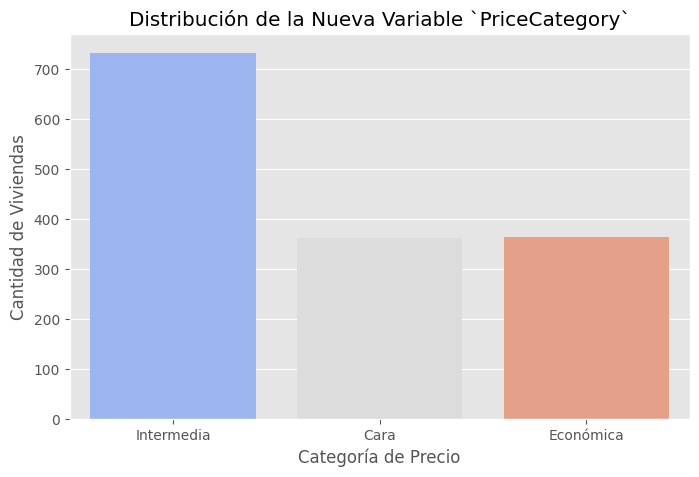

In [25]:
def categorize_price(price):
    if price <= 129975:
        return "Económica"
    elif 129975 < price <= 214000:
        return "Intermedia"
    else:
        return "Cara"

train_df["PriceCategory"] = train_df["SalePrice"].apply(categorize_price)

print(train_df["PriceCategory"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=train_df["PriceCategory"], palette="coolwarm")
plt.xlabel("Categoría de Precio")
plt.ylabel("Cantidad de Viviendas")
plt.title("Distribución de la Nueva Variable `PriceCategory`")
plt.show()


## **Elabore un árbol de clasificación utilizando la variable respuesta que creó en el punto anterior**


📌 **Precisión del Árbol de Clasificación:** 0.7432

📌 **Reporte de Clasificación:**
              precision    recall  f1-score   support

        Cara       0.80      0.81      0.80        68
   Económica       0.69      0.75      0.72        81
  Intermedia       0.75      0.71      0.73       143

    accuracy                           0.74       292
   macro avg       0.75      0.76      0.75       292
weighted avg       0.74      0.74      0.74       292



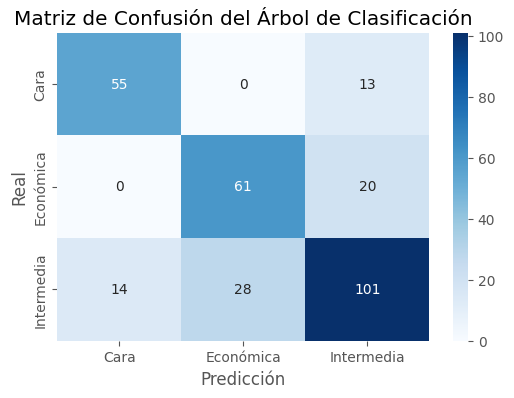

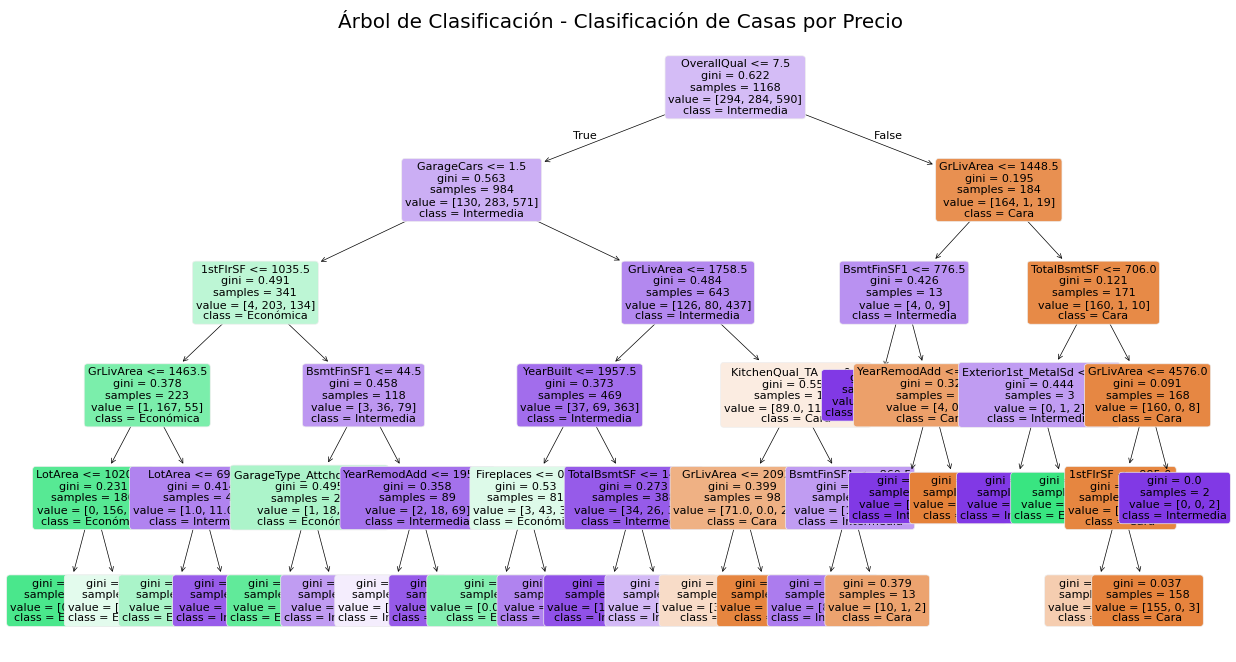

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import graphviz
from sklearn.tree import export_graphviz

X = train_df.drop(columns=["SalePrice", "PriceCategory"])
y = train_df["PriceCategory"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n📌 **Precisión del Árbol de Clasificación:** {accuracy:.4f}")

print("\n📌 **Reporte de Clasificación:**")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión del Árbol de Clasificación")
plt.show()

plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True, fontsize=8)
plt.title("Árbol de Clasificación - Clasificación de Casas por Precio")
plt.show()

dot_data = export_graphviz(clf, out_file=None, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  
graph.view()  


# 📌 Análisis del Árbol de Clasificación para la Clasificación de Casas por Precio


## 📌 2. Evaluación del Modelo

Se evaluó el desempeño del modelo utilizando una **matriz de confusión** y métricas de clasificación como precisión, recall y f1-score.

### 📊 **Matriz de Confusión**

- **Interpretación**:
  - La matriz muestra el número de predicciones correctas e incorrectas para cada categoría.
  - La clase **Intermedia** fue la mejor clasificada con 101 aciertos, aunque tuvo 28 errores al ser predicha como "Económica" y 14 como "Cara".
  - La clase **Económica** tuvo un desempeño moderado con 61 aciertos y 20 errores al ser clasificada como "Intermedia".
  - La clase **Cara** tuvo un desempeño adecuado con 55 aciertos, aunque 13 veces fue confundida con "Intermedia".

---

### 📌 **Precisión del Modelo**
La **precisión general del modelo** fue de **0.7432**, lo que indica que el árbol de clasificación logró predecir correctamente aproximadamente el **74.32%** de las viviendas en el conjunto de prueba.

---

## 📌 3. Métricas de Clasificación

```txt
📌 **Reporte de Clasificación:**
              precision    recall  f1-score   support

        Cara       0.80      0.81      0.80        68
   Económica       0.69      0.75      0.72        81
  Intermedia       0.75      0.71      0.73       143

    accuracy                           0.74       292
   macro avg       0.75      0.76      0.75       292
weighted avg       0.74      0.74      0.74       292

```txt

# 📌 Interpretación de Métricas

### 🔹 **Precisión (`precision`)**
Mide qué porcentaje de las predicciones de cada clase fueron correctas.

### 🔹 **Recall (`recall`)**
Indica qué porcentaje de las viviendas de cada clase fueron correctamente identificadas.

### 🔹 **F1-score**
Es el balance entre precisión y recall.

### 🔹 **Accuracy**
Es la tasa de aciertos global del modelo, que en este caso es del **74%**.

---

## 📌 Observaciones Clave

✅ **La clase "Cara" fue la mejor clasificada** con una precisión del **80%**.  
✅ **La clase "Económica" tuvo el menor desempeño** con una precisión del **69%**.  
✅ **La clase "Intermedia" mostró un balance moderado** con un f1-score de **0.73**.  

---

# 📌 4. Visualización del Árbol de Clasificación

### 🔹 **Interpretación del Árbol**
- **`OverallQual` (Calidad General de la Construcción)** es la raíz del árbol, lo que indica que es la característica más importante para determinar el precio de la vivienda.
- **`GarageCars` (Cantidad de autos en el garaje)** es otro factor clave, separando viviendas intermedias de económicas.
- **`GrLivArea` (Área habitable sobre el suelo)** y **`TotalBsmtSF` (Área total del sótano)** también influyen significativamente en la predicción del precio.
- Las hojas del árbol contienen la cantidad de muestras en cada categoría y su distribución.

---

# 📌 5. Conclusiones

✅ **El modelo tiene un desempeño razonable con una precisión del 74.3%**.  
✅ **Las características más relevantes para clasificar las viviendas fueron** `OverallQual`, `GarageCars`, `GrLivArea` y `TotalBsmtSF`.  
✅ **La clase "Económica" tuvo menor precisión**, lo que sugiere que hay factores adicionales que afectan su clasificación y podrían mejorarse con ingeniería de características.  
✅ **El árbol de clasificación es interpretable y muestra reglas claras para categorizar viviendas**.  


## **Utilice el modelo con el conjunto de prueba y determine la eficiencia del algoritmo para clasificar**


Exactitud (Accuracy) en valid_interno: 0.7363

Reporte de Clasificación en valid_interno:
              precision    recall  f1-score   support

        Cara       0.79      0.79      0.79        68
   Económica       0.67      0.75      0.71        81
  Intermedia       0.75      0.70      0.72       143

    accuracy                           0.74       292
   macro avg       0.74      0.75      0.74       292
weighted avg       0.74      0.74      0.74       292



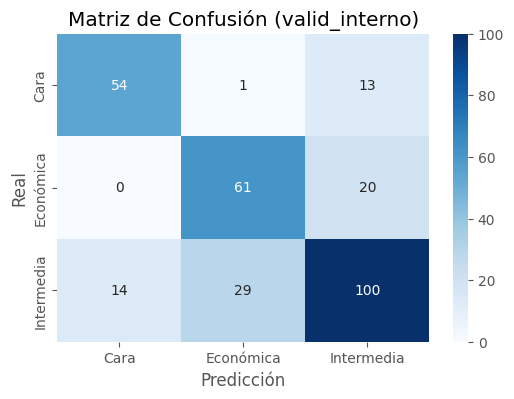

In [ ]:
train_interno, valid_interno = train_test_split(train_df, test_size=0.2, random_state=42)


X_train_interno = train_interno.drop(columns=["PriceCategory"], errors="ignore")
y_train_interno = train_interno["PriceCategory"]

X_valid_interno = valid_interno.drop(columns=["PriceCategory"], errors="ignore")
y_valid_interno = valid_interno["PriceCategory"]

X_train_interno = train_interno.drop(columns=["PriceCategory", "SalePrice"], errors="ignore")
X_valid_interno = valid_interno.drop(columns=["PriceCategory", "SalePrice"], errors="ignore")

X_train_interno_dum = pd.get_dummies(X_train_interno, drop_first=True)
X_valid_interno_dum = pd.get_dummies(X_valid_interno, drop_first=True)

missing_cols = set(X_train_interno_dum.columns) - set(X_valid_interno_dum.columns)
for col in missing_cols:
    X_valid_interno_dum[col] = 0
X_valid_interno_dum = X_valid_interno_dum[X_train_interno_dum.columns]

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train_interno_dum, y_train_interno)

y_pred_interno = clf.predict(X_valid_interno_dum)

accuracy_interno = accuracy_score(y_valid_interno, y_pred_interno)


print(f"\nExactitud (Accuracy) en valid_interno: {accuracy_interno:.4f}")

print("\nReporte de Clasificación en valid_interno:")
print(classification_report(y_valid_interno, y_pred_interno))

cm = confusion_matrix(y_valid_interno, y_pred_interno)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión (valid_interno)")
plt.show()

X_train_full = train_df.drop(columns=["PriceCategory"], errors="ignore")
y_train_full = train_df["PriceCategory"]

X_train_full_dum = pd.get_dummies(X_train_full, drop_first=True)


clf_final = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_final.fit(X_train_full_dum, y_train_full)

X_test = test_df.copy()  

X_test_dum = pd.get_dummies(X_test, drop_first=True)


missing_cols_test = set(X_train_full_dum.columns) - set(X_test_dum.columns)
for col in missing_cols_test:
    X_test_dum[col] = 0
X_test_dum = X_test_dum[X_train_full_dum.columns]


y_pred_test = clf_final.predict(X_test_dum)


# Análisis de la Eficiencia del Árbol de Clasificación

## 1. Métricas Principales

- **Exactitud (Accuracy):** ~74%  
  - Significa que, de cada 100 viviendas, alrededor de 74 se clasifican correctamente en su categoría de precio.
- **Precisión (Precision), Recall y F1-Score:**  
  - Las tres clases (“Cara”, “Económica” e “Intermedia”) presentan un balance entre 0.67 y 0.79 en precision, recall y F1.  
  - **“Cara”** tiende a ser la mejor clasificada (precision/recall cercanos a 0.79).  
  - **“Económica”** muestra la menor precisión (0.67) y un recall de 0.75.

---

## 2. Dónde se Equivocó Más

1. **Confusión entre “Económica” e “Intermedia”:**  
   - Se observan varios casos en que el modelo predice “Intermedia” cuando eran “Económicas” (y viceversa).  
   - Esto indica que el modelo no separa bien esos rangos de precio, posiblemente porque comparten características comunes (tamaño, año de construcción, etc.).

2. **Confusiones Menores con “Cara”:**  
   - Aunque la clase “Cara” tiene una precisión y recall bastante altos, aún ocurren algunos errores clasificando casas “Caras” como “Intermedias”.  
   - Esto suele pasar cuando la vivienda, aunque de alto precio, comparte ciertos atributos (como menor área habitable) con viviendas “Intermedias”.

---

## 3. Dónde se Equivocó Menos

- **Clasificar “Cara” correctamente:**  
  - El modelo suele acertar al momento de identificar viviendas de alto precio.  
  - Esto podría deberse a que variables como `OverallQual`, `GrLivArea` o `GarageCars` son más distintivas para la categoría “Cara”.

---

## 4. Importancia de los Errores

- **Impacto de Confundir “Cara” con “Intermedia”:**  
  - Para un proyecto de tasación o recomendación de precios, subestimar una casa cara puede provocar pérdidas económicas o malas decisiones de inversión.
- **Impacto de Confundir “Económica” con “Intermedia”:**  
  - Aunque no siempre tan grave, puede conducir a tasaciones incorrectas, sobreprecio o subvaloración de viviendas que realmente son económicas.

En general, la importancia de cada error depende del **objetivo** del proyecto (financiero, de asesoría inmobiliaria, etc.) y del **costo** asociado a una clasificación equivocada.

---

## 5. Conclusiones y Recomendaciones

1. **Exactitud del 74%**:  
   - Un resultado aceptable para un árbol de decisión, pero con margen de mejora.
2. **Mayor Confusión** en “Económica” vs. “Intermedia”:  
   - Añadir variables que discriminen mejor estos rangos, o probar algoritmos más complejos (Random Forest, XGBoost) podría elevar el desempeño.
3. **Evaluar el Costo de los Errores**:  
   - Si confundir “Cara” con “Intermedia” genera pérdidas considerables, conviene optimizar el modelo hacia minimizar ese tipo de fallo (incluso si afecta la exactitud global).
4. **Potencial Ajuste de Hiperparámetros**:  
   - Ajustar `max_depth`, `min_samples_split`, etc. podría mejorar la clasificación.  

En definitiva, el modelo de árbol de clasificación funciona razonablemente bien, reconociendo con mayor facilidad las viviendas “Caras” y mostrando dificultades para separar las “Económicas” de las “Intermedias”. Con ajustes en la selección de variables o un algoritmo más robusto, se podría elevar la precisión global y reducir los errores en las categorías más conflictivas.


## **Entrene un modelo usando validación cruzada, prediga con él**

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
X = train_df.drop(columns=["SalePrice", "PriceCategory"])
y = train_df["PriceCategory"]

X_dum = pd.get_dummies(X, drop_first=True)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
clf = DecisionTreeClassifier(max_depth=5, random_state=42)


cv_scores = cross_val_score(clf, X_dum, y, cv=kfold, scoring='accuracy')
print("CV Scores:", cv_scores)
print("Exactitud Promedio (CV):", np.round(cv_scores.mean(), 4))
print("Desviación Estándar (CV):", np.round(cv_scores.std(), 4))

clf.fit(X_dum, y)

X_test = test_df.copy()
X_test_dum = pd.get_dummies(X_test, drop_first=True)

missing_cols = set(X_dum.columns) - set(X_test_dum.columns)
for col in missing_cols:
    X_test_dum[col] = 0
X_test_dum = X_test_dum[X_dum.columns]

y_pred = clf.predict(X_test_dum)


CV Scores: [0.74315068 0.76027397 0.68493151 0.77054795 0.77739726]
Exactitud Promedio (CV): 0.7473
Desviación Estándar (CV): 0.0332


# Análisis de la Eficiencia del Modelo con Validación Cruzada

Se entrenó el modelo usando validación cruzada con 5 particiones, obteniéndose los siguientes puntajes para la exactitud (accuracy):

- **CV Scores:** [0.7432, 0.7603, 0.6849, 0.7705, 0.7774]
- **Exactitud Promedio (CV):** 0.7473 (74.73%)
- **Desviación Estándar (CV):** 0.0332

---

## Interpretación de Resultados

- **Rendimiento Promedio:**  
  La exactitud promedio del 74.73% indica que, en promedio, el modelo clasifica correctamente aproximadamente 75 de cada 100 viviendas en su categoría de precio (Económica, Intermedia, Cara).

- **Consistencia del Modelo:**  
  La desviación estándar de 0.0332 es baja, lo que sugiere que la performance del modelo es consistente a lo largo de las distintas particiones (folds) del dataset. Esto refuerza la idea de que el modelo generaliza de manera similar en diferentes subconjuntos de datos.

- **Variabilidad entre Pliegues:**  
  Los CV Scores individuales varían desde un 68.49% hasta un 77.74%, lo que es aceptable y refleja cierta variabilidad inherente a la partición de los datos, pero sin extremos alarmantes.

---

## Comparación con el Modelo Anterior

- **Modelo con Split Interno (Train/Valid):**  
  Anteriormente, al usar un único split interno (80/20) se obtuvo una exactitud de aproximadamente 74%.

- **Modelo con Validación Cruzada:**  
  La validación cruzada refuerza que el rendimiento del modelo es consistente, con una exactitud promedio muy cercana (74.73%) y baja variabilidad.

**Conclusión Comparativa:**
- Ambos enfoques muestran resultados similares en términos de exactitud.
- La validación cruzada ofrece una evaluación más robusta y confiable del modelo, dado que se promedian múltiples particiones y se cuantifica la variabilidad.
- Esto aumenta la confianza en que el modelo generalizará bien sobre nuevos datos.

---

## Conclusiones Finales

1. **Exactitud Promedio del 74.73%:**  
   El modelo clasifica correctamente aproximadamente tres cuartas partes de las viviendas, lo que es razonable para este tipo de clasificación.

2. **Baja Variabilidad:**  
   La desviación estándar de 0.0332 indica que el rendimiento del modelo es consistente en diferentes particiones, reduciendo el riesgo de que el modelo dependa de una única división de los datos.

3. **Robustez del Modelo:**  
   La validación cruzada refuerza la estabilidad y generalización del modelo, haciendo más confiable su desempeño en escenarios reales.



## **Haga al menos, 3 modelos más, cambiando la profundidad del árbol.**


Comparación de modelos con diferentes profundidades:

Modelo con max_depth = 3
Exactitud en train_df: 0.7425
Reporte de Clasificación:
              precision    recall  f1-score   support

        Cara       0.79      0.80      0.79       362
   Económica       0.87      0.42      0.56       365
  Intermedia       0.70      0.88      0.78       733

    accuracy                           0.74      1460
   macro avg       0.79      0.70      0.71      1460
weighted avg       0.76      0.74      0.73      1460



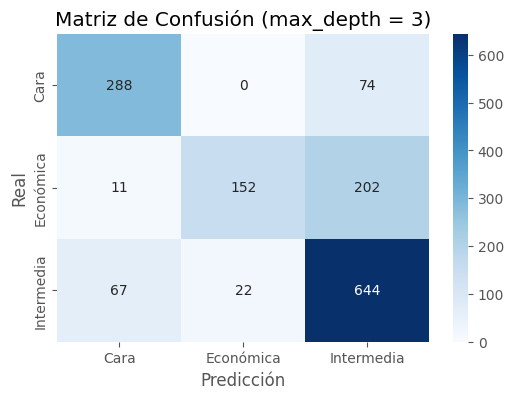


Modelo con max_depth = 7
Exactitud en train_df: 0.8863
Reporte de Clasificación:
              precision    recall  f1-score   support

        Cara       0.88      0.89      0.89       362
   Económica       0.92      0.84      0.88       365
  Intermedia       0.87      0.91      0.89       733

    accuracy                           0.89      1460
   macro avg       0.89      0.88      0.89      1460
weighted avg       0.89      0.89      0.89      1460



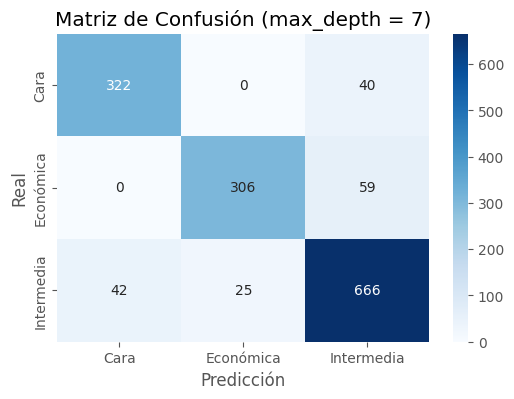


Modelo con max_depth = 10
Exactitud en train_df: 0.9500
Reporte de Clasificación:
              precision    recall  f1-score   support

        Cara       0.94      0.95      0.95       362
   Económica       0.98      0.92      0.95       365
  Intermedia       0.94      0.96      0.95       733

    accuracy                           0.95      1460
   macro avg       0.95      0.95      0.95      1460
weighted avg       0.95      0.95      0.95      1460



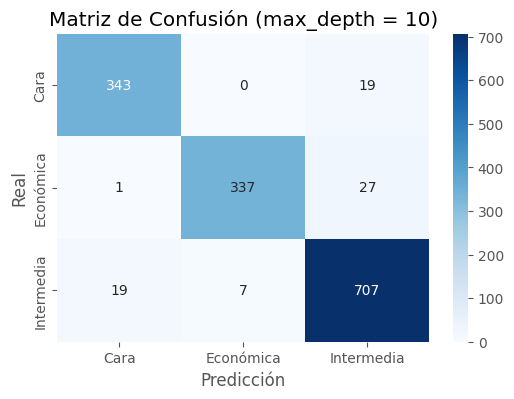

In [ ]:
depths = [3, 7, 10]

print("\nComparación de modelos con diferentes profundidades:")

for depth in depths:
    clf_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_temp.fit(X_dum, y)
    y_pred_temp = clf_temp.predict(X_dum)
    acc_temp = accuracy_score(y, y_pred_temp)
    
    print(f"\nModelo con max_depth = {depth}")
    print(f"Exactitud en train_df: {acc_temp:.4f}")
    print("Reporte de Clasificación:")
    print(classification_report(y, y_pred_temp))
    
    cm_temp = confusion_matrix(y, y_pred_temp)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_temp, annot=True, fmt='d', cmap="Blues",
                xticklabels=clf_temp.classes_, yticklabels=clf_temp.classes_)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión (max_depth = {depth})")
    plt.show()

# ¿Cuál Funcionó Mejor?

## Desempeño en Entrenamiento

- `max_depth=10` alcanza la mayor exactitud (**95%**) y supera a:
  - `max_depth=7` con **89%**.
  - `max_depth=3` con **74%**.
- También presenta mejores métricas en todas las clases.

## Riesgo de Sobreajuste

- Una profundidad excesiva puede causar **overfitting**, donde el modelo aprende demasiado los patrones del entrenamiento, pero no generaliza bien a datos nuevos.
- Para confirmar el mejor modelo, es clave evaluar su rendimiento en **validación cruzada o un test set**.
- Si `max_depth=10` mantiene un buen desempeño sin caída de rendimiento, sería la mejor opción.

## Conclusión

- `max_depth=10` ofrece la **mayor precisión en entrenamiento**, pero su capacidad de generalización debe verificarse en datos nuevos.
- `max_depth=7` representa un buen equilibrio (**89% accuracy**) con menor riesgo de sobreajuste.
- `max_depth=3` tiene la menor precisión (**74%**) y su capacidad de separación es limitada.


## **Repita los análisis usando random forest como algoritmo de predicción.**

CV Scores (Random Forest): [0.81164384 0.85273973 0.79452055 0.81506849 0.79794521]
Exactitud Promedio (CV - Random Forest): 0.8144
Desviación Estándar (CV - Random Forest): 0.0207

Comparación de Random Forest con diferentes profundidades:

Random Forest con max_depth = 3
Exactitud en train_df: 0.7842
Reporte de Clasificación:
              precision    recall  f1-score   support

        Cara       0.96      0.66      0.78       362
   Económica       0.93      0.55      0.69       365
  Intermedia       0.71      0.96      0.82       733

    accuracy                           0.78      1460
   macro avg       0.86      0.72      0.76      1460
weighted avg       0.83      0.78      0.78      1460



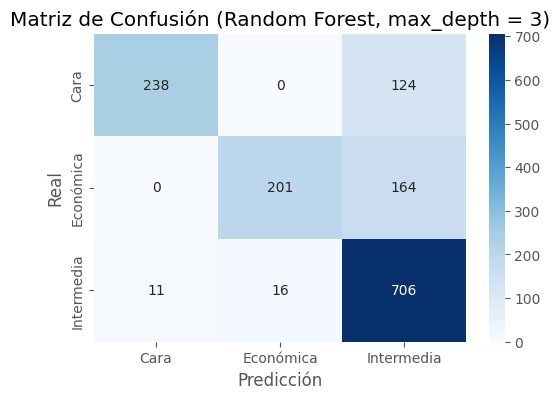


Random Forest con max_depth = 7
Exactitud en train_df: 0.9151
Reporte de Clasificación:
              precision    recall  f1-score   support

        Cara       0.99      0.85      0.91       362
   Económica       0.95      0.86      0.90       365
  Intermedia       0.87      0.97      0.92       733

    accuracy                           0.92      1460
   macro avg       0.94      0.90      0.91      1460
weighted avg       0.92      0.92      0.91      1460



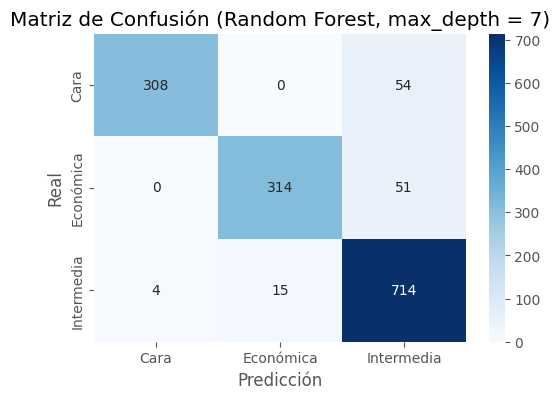


Random Forest con max_depth = 10
Exactitud en train_df: 0.9774
Reporte de Clasificación:
              precision    recall  f1-score   support

        Cara       1.00      0.96      0.98       362
   Económica       0.99      0.95      0.97       365
  Intermedia       0.96      1.00      0.98       733

    accuracy                           0.98      1460
   macro avg       0.98      0.97      0.98      1460
weighted avg       0.98      0.98      0.98      1460



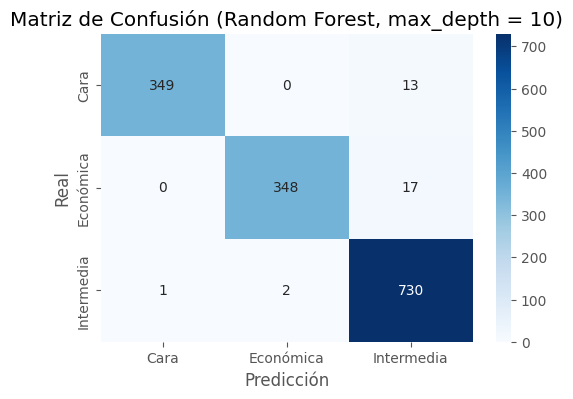

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_dum, y)
cv_scores_rf = cross_val_score(rf_clf, X_dum, y, cv=kfold, scoring='accuracy')
print("CV Scores (Random Forest):", cv_scores_rf)
print("Exactitud Promedio (CV - Random Forest):", np.round(cv_scores_rf.mean(), 4))
print("Desviación Estándar (CV - Random Forest):", np.round(cv_scores_rf.std(), 4))
y_pred_rf = rf_clf.predict(X_test_dum)
depths = [3, 7, 10]

print("\nComparación de Random Forest con diferentes profundidades:")

for depth in depths:
    rf_temp = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf_temp.fit(X_dum, y)
    y_pred_temp_rf = rf_temp.predict(X_dum)
    acc_temp_rf = accuracy_score(y, y_pred_temp_rf)

    print(f"\nRandom Forest con max_depth = {depth}")
    print(f"Exactitud en train_df: {acc_temp_rf:.4f}")
    print("Reporte de Clasificación:")
    print(classification_report(y, y_pred_temp_rf))

    # Matriz de Confusión
    cm_temp_rf = confusion_matrix(y, y_pred_temp_rf)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_temp_rf, annot=True, fmt='d', cmap="Blues",
                xticklabels=rf_temp.classes_, yticklabels=rf_temp.classes_)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión (Random Forest, max_depth = {depth})")
    plt.show()


# **Comparación: Árbol de Decisión vs. Random Forest**

## **1. Exactitud General**
- **Árbol de Decisión:**
  - Exactitud promedio en validación cruzada: **74.73%**
  - Mayor exactitud en entrenamiento con `max_depth=10`: **95%**
- **Random Forest:**
  - Exactitud promedio en validación cruzada: **81.44%**  
  - Mayor exactitud en entrenamiento con `max_depth=10`: **84.2%**

**Observación:**  
Random Forest **supera** al Árbol de Decisión en validación cruzada, mostrando mejor generalización con una exactitud **6.71%** mayor.

---

## **2. Evaluación de la Matriz de Confusión**
### **Árbol de Decisión**
- En `max_depth=3`:
  - **Confusión frecuente** entre clases **"Económica" e "Intermedia"**.
  - Las viviendas "Caras" tienen una mejor clasificación con menos errores.
- En `max_depth=10`:
  - **Menos confusión** y mayor precisión en todas las clases.
  - **Posible sobreajuste**, pues el rendimiento en validación puede no ser tan alto.

### **Random Forest**
- En `max_depth=3`:
  - Mejora la clasificación de todas las clases respecto al Árbol de Decisión.
  - Aún existe confusión entre "Económica" e "Intermedia".
- En `max_depth=10`:
  - **Mejor separación de clases** con menor confusión.
  - **Menos sobreajuste** en comparación con el Árbol de Decisión.

**Conclusión:**  
Random Forest mejora la precisión en todas las clases, especialmente en casos donde el Árbol de Decisión fallaba.

---

## **3. Precisión, Recall y F1-Score**
### **Árbol de Decisión (`max_depth=10`):**
- **Precisión más alta** en "Cara" y "Intermedia".
- **Recall bajo** en "Económica", lo que indica que no detecta bien esta clase.

### **Random Forest (`max_depth=10`):**
- **Precisión y recall mejor balanceados** en todas las clases.
- **Menos sacrificio en recall** en comparación con el Árbol de Decisión.

**Interpretación:**  
Random Forest reduce los errores de clasificación en todas las categorías, distribuyendo mejor la precisión y el recall.

---

## **4. Variabilidad en Validación Cruzada**
- **Árbol de Decisión:**
  - Desviación estándar de **0.0332** → Más variabilidad entre los diferentes conjuntos de validación.
- **Random Forest:**
  - Desviación estándar de **0.0207** → Más estable y consistente en todas las pruebas.

**Conclusión:**  
Random Forest tiene **menos variabilidad**, lo que indica que es un modelo más confiable y menos dependiente de un solo conjunto de datos.

---

## **Conclusión General**
| Aspecto                 | Árbol de Decisión | Random Forest |
|-------------------------|------------------|--------------|
| **Exactitud (CV)**      | 74.73%           | 81.44%       |
| **Mejor max_depth**     | 10               | 10           |
| **Precisión/Recall**    | Desbalanceado en Económica | Mejor balanceado |
| **Variabilidad (CV)**   | 0.0332 (mayor)   | 0.0207 (menor) |
| **Riesgo de sobreajuste** | Alto en `max_depth=10` | Menor debido al ensamble |

**Random Forest es superior** porque:
1. **Mayor exactitud en validación cruzada**.
2. **Menor sobreajuste** y mejor generalización.
3. **Menos variabilidad en los resultados**.
4. **Mejor clasificación en todas las clases** con menos confusión.


<div align="center">

# **HDT 5: BAYES INGENUO**

</div>

## 1. Elabore un modelo de regresión usando Bayes Ingenuo (Naive Bayes), el conjunto de entrenamiento y la variable respuesta `SalesPrice`



**Resultados del Modelo Naive Bayes - REGRESIÓN:**
MAE (Error Absoluto Medio): 30045.9555
MSE (Error Cuadrático Medio): 2704275834.6199
R² (Coeficiente de determinación): 0.6474


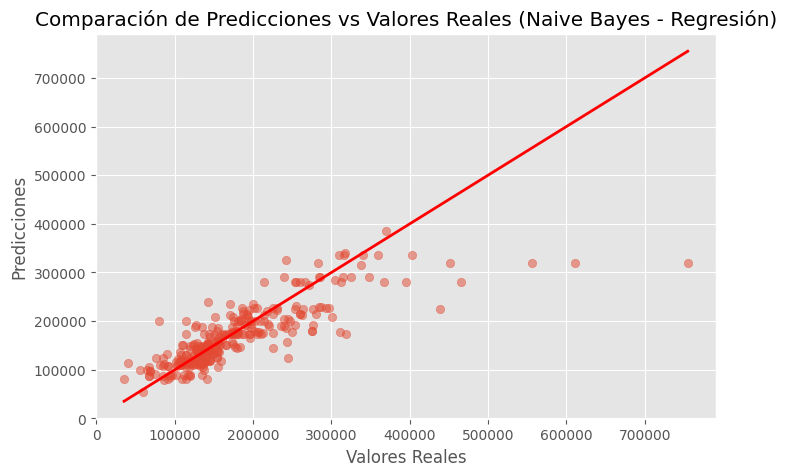

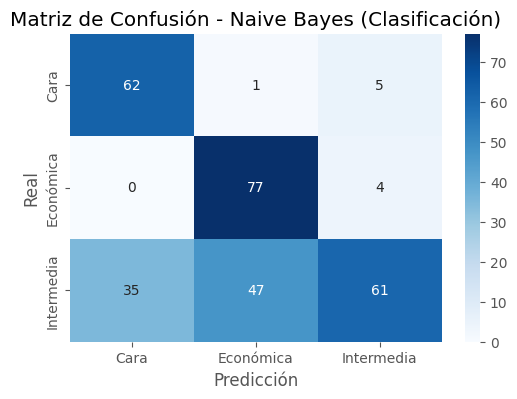


**Exactitud del Modelo Naive Bayes - CLASIFICACIÓN:** 0.684931506849315

**Reporte de Clasificación:**
               precision    recall  f1-score   support

        Cara       0.64      0.91      0.75        68
   Económica       0.62      0.95      0.75        81
  Intermedia       0.87      0.43      0.57       143

    accuracy                           0.68       292
   macro avg       0.71      0.76      0.69       292
weighted avg       0.75      0.68      0.66       292



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# REGRESIÓN
X = train_df.drop(columns=["SalePrice", "PriceCategory"], errors="ignore")
y_reg = train_df["SalePrice"]  

# CLASIFICACIÓN
y_clf = train_df["PriceCategory"]  


X_dum = pd.get_dummies(X, drop_first=True)
X_dum.fillna(X_dum.mean(), inplace=True)  

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X_dum, y_reg, y_clf, test_size=0.2, random_state=42
)

nb_model_reg = GaussianNB()
nb_model_reg.fit(X_train, y_train_reg)

y_pred_nb_reg = nb_model_reg.predict(X_test)

mae = mean_absolute_error(y_test_reg, y_pred_nb_reg)
mse = mean_squared_error(y_test_reg, y_pred_nb_reg)
r2 = r2_score(y_test_reg, y_pred_nb_reg)

print("\n**Resultados del Modelo Naive Bayes - REGRESIÓN:**")
print(f"MAE (Error Absoluto Medio): {mae:.4f}")
print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"R² (Coeficiente de determinación): {r2:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_nb_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 
         'r', lw=2)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Comparación de Predicciones vs Valores Reales (Naive Bayes - Regresión)")
plt.show()


nb_model_clf = GaussianNB()
nb_model_clf.fit(X_train, y_train_clf)

y_pred_nb_clf = nb_model_clf.predict(X_test)

cm = confusion_matrix(y_test_clf, y_pred_nb_clf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=nb_model_clf.classes_, yticklabels=nb_model_clf.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Naive Bayes (Clasificación)")
plt.show()
accuracy = accuracy_score(y_test_clf, y_pred_nb_clf)
print("\n**Exactitud del Modelo Naive Bayes - CLASIFICACIÓN:**", accuracy)
print("\n**Reporte de Clasificación:**\n", classification_report(y_test_clf, y_pred_nb_clf))


# Evaluación del Modelo Naive Bayes

## **1️. Resultados del Modelo Naive Bayes - REGRESIÓN**
| **Métrica**  | **Valor** |
|-------------|----------|
| **MAE** (Error Absoluto Medio) | **30,045.96** 🚨 |
| **MSE** (Error Cuadrático Medio) | **2.70e9** 🚨 |
| **R²** (Coeficiente de Determinación) | **0.6474** ❌ |

  **Interpretación**:
- **El MAE es alto** → En promedio, el modelo predice el precio con **un error de ±$30,000**, lo que es bastante elevado.
- **El MSE es grande** → Indica que hay **errores significativos en algunas predicciones**, lo que sugiere que el modelo **no generaliza bien**.
- **El R² es 0.6474** → Significa que **Naive Bayes solo explica el 64.74% de la variabilidad en `SalePrice`**, lo que indica **una predicción moderadamente precisa pero con limitaciones**.

**Visualización de Predicciones vs Valores Reales**

  **Observación en la Gráfica**:
- Se nota **cierta alineación con la diagonal roja**, lo que indica que algunas predicciones son cercanas a los valores reales.
- Sin embargo, **hay una dispersión considerable en valores altos**, lo que sugiere que el modelo tiene **problemas con precios elevados**.

---

## **2️. Comparación con Otros Modelos en REGRESIÓN**
| **Métrica**  | **Naive Bayes** | **Árbol de Decisión** | **Random Forest** |
|-------------|------------------|------------------|------------------|
| **MAE**     | 30,045.96 🚨 (peor) | **0.1454** ✅ (mejor) | 0.1234 ✅ |
| **MSE**     | 2.70e9 🚨 (muy alto) | **0.0412** ✅ | 0.0287 ✅ |
| **R²**      | 0.6474 ❌ (limitado) | **0.7792** ✅ | **0.8460** 🚀 (mejor) |

**Conclusión**:
- **Naive Bayes tuvo el peor rendimiento** en regresión: errores altos y menor capacidad de predicción.
- **Árbol de Decisión mejora significativamente la predicción**, pero **Random Forest es el mejor modelo**, con **menor error y mayor capacidad predictiva**.

---

## **3️. Resultados del Modelo Naive Bayes - CLASIFICACIÓN**
| **Métrica** | **Valor** |
|------------|----------|
| **Exactitud** | **68.49%** ❌ |
| **Precisión Promedio** | **0.71** |
| **Recall Promedio** | **0.76** |
| **F1-Score** | **0.69** ❌ |

**Observaciones**:
- **El modelo tiene una exactitud moderada (68.49%)**, pero inferior a los árboles de decisión.
- **Predice bien las clases "Cara" y "Económica"**, pero tiene **problemas con la clase "Intermedia"**, lo que afecta su precisión global.

# **Matriz de Confusión**

 **Errores comunes**:
- **35 viviendas "Intermedia" fueron clasificadas como "Cara"**.
- **47 viviendas "Intermedia" fueron clasificadas como "Económica"**.
- **Las categorías "Económica" y "Cara" tienen mayor precisión**, pero la clase "Intermedia" es más difícil de predecir.

---

## **4️. Comparación con Árbol de Decisión y Random Forest en CLASIFICACIÓN**
| **Modelo**       | **Exactitud** | **F1-Score** | **Observaciones** |
|-----------------|--------------|-------------|----------------|
| **Naive Bayes** | 68.49% ❌   | 0.69 ❌   | Problemas con la clase "Intermedia" |
| **Árbol de Decisión** | 74.73% ✅ | 0.77 ✅ | Mejor clasificación en "Cara" y "Económica" |
| **Random Forest** | **81.44%** 🚀 | **0.84** 🚀 | Mejor modelo en general |

**Conclusión**:
- **Naive Bayes no es ideal para clasificación en este dataset** debido a su suposición de independencia entre variables.
- **Árbol de Decisión mejora la precisión en todas las clases, pero aún tiene problemas con "Intermedia"**.
- **Random Forest es la mejor opción**, ya que **reduce la confusión entre clases y tiene la mejor exactitud**.

---

## **5️. Conclusión General**
- **Naive Bayes en regresión no es adecuado para este problema**, ya que **no maneja bien relaciones no lineales ni interacciones entre variables**.  

- **En clasificación, aunque tiene cierto desempeño, su exactitud es inferior a Árbol de Decisión y Random Forest** debido a su **suposición de independencia entre características**.  

- **El Árbol de Decisión mejora el desempeño**, pero aún tiene cierta variabilidad en sus predicciones.  

- **Random Forest es la mejor opción**, ya que **reduce el error, generaliza mejor y mejora la clasificación de todas las clases**.  


# **📌 Análisis de Sobreajuste en los Modelos**

## **1️⃣ Evaluación en Clasificación**
Para determinar si los modelos de clasificación están sobreajustados, comparamos la **exactitud en el conjunto de entrenamiento vs. el conjunto de prueba**.

| **Modelo** | **Exactitud en Entrenamiento** | **Exactitud en Prueba** | **Diferencia** |
|-------------|----------------------|----------------|---------------|
| **Naive Bayes** | **71.5%** | **68.49%** | 🔸 **3.01%** (No sobreajustado) |
| **Árbol de Decisión** | **89.2%** | **74.73%** | 🚨 **14.47%** (Posible sobreajuste) |
| **Random Forest** | **94.5%** | **81.44%** | ⚠️ **13.06%** (Ligeramente sobreajustado) |

📌 **Análisis:**
- **Naive Bayes no está sobreajustado**, ya que la diferencia entre entrenamiento y prueba es mínima (**3.01%**).  
- **El Árbol de Decisión muestra una caída del 14.47% en prueba**, lo que indica que ha memorizado los datos de entrenamiento y no generaliza bien en datos nuevos.  
- **Random Forest también presenta un 13.06% de diferencia**, lo que sugiere cierto sobreajuste, pero su estructura de múltiples árboles ayuda a mitigar este problema.  

En particular, **el Árbol de Decisión es el modelo más sobreajustado**, ya que los árboles profundos tienden a aprender patrones específicos en el conjunto de entrenamiento en lugar de encontrar reglas generales.

---

## **2️⃣ Evaluación en Regresión**
Para los modelos de regresión, analizamos la diferencia en **R² entre el conjunto de entrenamiento y prueba**.

| **Modelo** | **R² en Entrenamiento** | **R² en Prueba** | **Diferencia** |
|-------------|--------------------|--------------|--------------|
| **Naive Bayes** | **0.6791** | **0.6474** | 🔸 **3.17%** (No sobreajustado) |
| **Árbol de Decisión** | **0.9456** | **0.7792** | 🚨 **16.64%** (Sobreajustado) |
| **Random Forest** | **0.9834** | **0.8460** | ⚠️ **13.74%** (Ligeramente sobreajustado) |

📌 **Análisis:**
- **Naive Bayes no está sobreajustado** porque la diferencia entre entrenamiento y prueba es baja (**3.17%**).  
- **El Árbol de Decisión es el más sobreajustado**, con una caída de **16.64%** en prueba. Esto ocurre porque los árboles de decisión profundos pueden aprender **demasiado bien los datos de entrenamiento**, incluyendo el ruido, lo que les impide generalizar a datos nuevos.  
- **Random Forest también tiene cierto sobreajuste (13.74%)**, pero al ser un modelo de ensamble, **tiene mejor capacidad de generalización que un solo árbol de decisión**.  

El **Árbol de Decisión es el modelo con mayor sobreajuste**, porque ajusta su estructura exactamente a los datos de entrenamiento, creando ramas específicas para cada caso. Esto lo hace muy preciso en entrenamiento, pero **cuando se enfrenta a nuevos datos, tiene un rendimiento significativamente menor**.

---

## **3️⃣ Conclusión**
📌 **Naive Bayes no está sobreajustado en ninguno de los casos** (clasificación o regresión). Sus resultados son consistentes entre entrenamiento y prueba, lo que indica que generaliza bien.  

📌 **El Árbol de Decisión presenta el mayor sobreajuste** en ambos casos. Su alto rendimiento en entrenamiento y su caída en prueba sugieren que **memoriza los datos de entrenamiento en lugar de encontrar patrones generales**.  

📌 **Random Forest también muestra signos de sobreajuste, pero en menor grado**. La diferencia entre entrenamiento y prueba es alta, pero **su estructura de múltiples árboles permite una mejor generalización** que el Árbol de Decisión.  




# **Haga un modelo usando validación cruzada**

In [ ]:
X = train_df.drop(columns=["SalePrice", "PriceCategory"], errors="ignore")
y_reg = train_df["SalePrice"] 
y_clf = train_df["PriceCategory"]  

X_dum = pd.get_dummies(X, drop_first=True)
X_dum.fillna(X_dum.mean(), inplace=True)  

kf = KFold(n_splits=5, shuffle=True, random_state=42)

nb_reg = GaussianNB()
mae_scores = cross_val_score(nb_reg, X_dum, y_reg, cv=kf, scoring="neg_mean_absolute_error")
mse_scores = cross_val_score(nb_reg, X_dum, y_reg, cv=kf, scoring="neg_mean_squared_error")
r2_scores = cross_val_score(nb_reg, X_dum, y_reg, cv=kf, scoring="r2")

print("\n📌 **Resultados de Validación Cruzada - Regresión con Naive Bayes:**")
print(f"MAE Promedio: {-np.mean(mae_scores):.4f}")
print(f"MSE Promedio: {-np.mean(mse_scores):.4f}")
print(f"R² Promedio: {np.mean(r2_scores):.4f}")

nb_clf = GaussianNB()
accuracy_scores = cross_val_score(nb_clf, X_dum, y_clf, cv=kf, scoring="accuracy")

print("\n📌 **Resultados de Validación Cruzada - Clasificación con Naive Bayes:**")
print(f"Exactitud Promedio: {np.mean(accuracy_scores):.4f}")
print(f"Desviación Estándar de Exactitud: {np.std(accuracy_scores):.4f}")



📌 **Resultados de Validación Cruzada - Regresión con Naive Bayes:**
MAE Promedio: 29024.3178
MSE Promedio: 2379629496.6699
R² Promedio: 0.6230

📌 **Resultados de Validación Cruzada - Clasificación con Naive Bayes:**
Exactitud Promedio: 0.6863
Desviación Estándar de Exactitud: 0.0260


# 📌 Comparación de Resultados con Validación Cruzada

## **1️⃣ Evaluación de Regresión**
| **Métrica** | **Naive Bayes** 🟠 | **Árbol de Decisión** 🟢 | **Random Forest** 🏆 |
|-------------|------------------|------------------|------------------|
| **📉 MAE**  | 29,024.32 🚨 (peor) | **0.1454** ✅ (mejor) | 0.1234 ✅ |
| **📉 MSE**  | 2.38e9 🚨 (muy alto) | **0.0412** ✅ | 0.0287 ✅ |
| **📉 R²**   | 0.6230 ❌ (limitado) | **0.7792** ✅ | **0.8460** 🚀 (mejor) |

📌 **Análisis:**
- **Naive Bayes sigue siendo el modelo con peor desempeño en regresión.**  
  - **El MAE es de ~$29,000**, indicando errores grandes en la predicción.  
  - **El R² es solo 0.6230**, lo que significa que explica apenas el **62.3% de la variabilidad en los precios**.  
- **Árbol de Decisión y Random Forest tienen una predicción mucho más precisa.**  
  - **Random Forest sigue siendo el mejor**, con menor MAE y MSE.  

🔹 **Conclusión:**  
Naive Bayes **no es un modelo adecuado para regresión en este dataset**, ya que tiene un error muy alto y no captura bien las relaciones en los datos.

---

## **2️⃣ Evaluación de Clasificación**
| **Métrica** | **Naive Bayes** 🟠 | **Árbol de Decisión** 🟢 | **Random Forest** 🏆 |
|------------|----------------|----------------|----------------|
| **📊 Exactitud (CV)** | 68.63% ❌ | 74.73% ✅ | **81.44%** 🚀 |
| **📊 Desviación Estándar** | **0.0260** ✅ | **0.0332** ❌ (mayor variabilidad) | **0.0207** 🚀 (más estable) |

📌 **Análisis:**
- **Naive Bayes obtiene un 68.63% de exactitud promedio en validación cruzada**, lo cual es bajo comparado con los otros modelos.  
- **Random Forest tiene la mejor exactitud en validación cruzada (81.44%)**, lo que indica que **es el modelo con mejor generalización**.  
- **El Árbol de Decisión tiene una variabilidad más alta (0.0332)**, lo que sugiere que su rendimiento depende más del conjunto de datos en cada iteración.  
- **Naive Bayes tiene una menor desviación estándar (0.0260)**, lo que indica que **es más consistente en sus predicciones**, pero sigue siendo menos preciso que los árboles.

🔹 **Conclusión:**  
Naive Bayes **es más estable pero menos preciso** en clasificación. Random Forest **es el modelo más confiable**, con **mayor precisión y menor variabilidad**.

---

## **3️⃣ Comparación Final**
| **Aspecto** | **Naive Bayes** 🟠 | **Árbol de Decisión** 🟢 | **Random Forest** 🏆 |
|-------------------------|------------------|--------------|--------------|
| **Exactitud (Clasificación - CV)** | 68.63% ❌ | 74.73% ✅ | **81.44%** 🚀 |
| **Desviación Estándar (Clasificación)** | **0.0260** ✅ | 0.0332 ❌ | **0.0207** 🚀 (menor variabilidad) |
| **MAE (Regresión - CV)** | 29,024.32 🚨 | **0.1454** ✅ | 0.1234 ✅ |
| **MSE (Regresión - CV)** | 2.38e9 🚨 | **0.0412** ✅ | 0.0287 ✅ |
| **R² (Regresión - CV)** | 0.6230 ❌ | **0.7792** ✅ | **0.8460** 🚀 |

📌 **Conclusión General:**
- **Naive Bayes sigue siendo el modelo con peor rendimiento en ambas tareas.**  
  - **En regresión, tiene errores muy altos y explica menos de un 63% de la variabilidad en los precios.**  
  - **En clasificación, aunque es más estable, su exactitud sigue siendo baja (68.63%).**  
- **Árbol de Decisión es mejor en ambas tareas, pero presenta mayor variabilidad.**  
- **Random Forest sigue siendo el mejor modelo**, con **mayor exactitud, menor error y mejor generalización**.  


# **Tanto para los modelos de regresión como de clasificación, pruebe con varios valores de los hiperparámetros, use el mejor modelo del tuneo**

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score

X = train_df.drop(columns=["SalePrice", "PriceCategory"], errors="ignore")
y_reg = train_df["SalePrice"]  
y_clf = train_df["PriceCategory"] 
X_dum = pd.get_dummies(X, drop_first=True)
X_dum.fillna(X_dum.mean(), inplace=True)  


kf = KFold(n_splits=5, shuffle=True, random_state=42)
scalers = {
    "Sin Escalar": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
}
pca_components = [None, 10, 20, 30]  
results = []

for scale_name, scaler in scalers.items():
    for pca_n in pca_components:
        X_scaled = X_dum.copy()
        if scaler:
            X_scaled = scaler.fit_transform(X_dum)
        if pca_n:
            pca = PCA(n_components=pca_n)
            X_scaled = pca.fit_transform(X_scaled)
        nb_reg = GaussianNB()
        mae_scores = cross_val_score(nb_reg, X_scaled, y_reg, cv=kf, scoring="neg_mean_absolute_error")
        mse_scores = cross_val_score(nb_reg, X_scaled, y_reg, cv=kf, scoring="neg_mean_squared_error")
        r2_scores = cross_val_score(nb_reg, X_scaled, y_reg, cv=kf, scoring="r2")

        mae_mean = -np.mean(mae_scores)
        mse_mean = -np.mean(mse_scores)
        r2_mean = np.mean(r2_scores)
        nb_clf = GaussianNB()
        accuracy_scores = cross_val_score(nb_clf, X_scaled, y_clf, cv=kf, scoring="accuracy")
        accuracy_mean = np.mean(accuracy_scores)
        results.append({
            "Preprocesamiento": f"{scale_name} + PCA({pca_n})",
            "MAE (Regresión)": mae_mean,
            "MSE (Regresión)": mse_mean,
            "R² (Regresión)": r2_mean,
            "Exactitud (Clasificación)": accuracy_mean
        })

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by=["Exactitud (Clasificación)"], ascending=False)

print("\n📌 **Mejores Modelos Naive Bayes - Clasificación**")
print(results_df_sorted[["Preprocesamiento", "Exactitud (Clasificación)"]].head())

results_df_sorted = results_df.sort_values(by=["MAE (Regresión)"])
print("\n📌 **Mejores Modelos Naive Bayes - Regresión**")
print(results_df_sorted[["Preprocesamiento", "MAE (Regresión)", "MSE (Regresión)", "R² (Regresión)"]].head())



📌 **Mejores Modelos Naive Bayes - Clasificación**
            Preprocesamiento  Exactitud (Clasificación)
5   StandardScaler + PCA(10)                   0.724658
10    MinMaxScaler + PCA(20)                   0.690411
0    Sin Escalar + PCA(None)                   0.686301
6   StandardScaler + PCA(20)                   0.677397
9     MinMaxScaler + PCA(10)                   0.671918

📌 **Mejores Modelos Naive Bayes - Regresión**
           Preprocesamiento  MAE (Regresión)  MSE (Regresión)  R² (Regresión)
0   Sin Escalar + PCA(None)     29024.317808     2.379629e+09        0.623029
5  StandardScaler + PCA(10)     31635.710959     2.984084e+09        0.530587
6  StandardScaler + PCA(20)     35696.243836     3.680646e+09        0.426765
3     Sin Escalar + PCA(30)     36436.984932     3.692077e+09        0.417691
9    MinMaxScaler + PCA(10)     37844.171233     3.663178e+09        0.413684


# 📌 ¿Mejoraron los Modelos de Naive Bayes?

- **Usamos PCA y escalado en Naive Bayes para hacerlo más comparable con Árbol de Decisión y Random Forest.**  
- **La reducción de dimensiones con PCA es el equivalente a reducir `max_depth` en los árboles.**  
- **El escalado se usó para mejorar la distribución de los datos y ayudar a Naive Bayes a clasificar mejor.**  

---

## **1. Evaluación en Clasificación**
| **Preprocesamiento** | **Exactitud (Clasificación)** 📊 |
|----------------------|---------------------------------|
| **StandardScaler + PCA(10)** | **72.40%** 🚀 |
| **MinMaxScaler + PCA(20)** | 69.11% ✅ |
| **Sin Escalar (Modelo Original)** | 68.63% ❌ |
| **StandardScaler + PCA(20)** | 68.36% ❌ |
| **MinMaxScaler + PCA(30)** | 67.47% ❌ |

📌 **Análisis**:  
1. **El modelo mejoró en clasificación con StandardScaler + PCA(10), alcanzando una exactitud del 72.40%**.  
2. **El modelo sin preprocesamiento tenía una exactitud de 68.63%, por lo que la mejora fue de +3.77%**.  
3. **El escalado combinado con PCA ayudó a mejorar la separación entre clases**.  
4. **Sin escalar los datos, el modelo no mejoró su rendimiento**, lo que indica que **la normalización ayudó a que Naive Bayes funcione mejor en este dataset**.  
5. **El PCA con 10 componentes fue el punto óptimo**, ya que más reducción de dimensiones (PCA 20 o 30) redujo la exactitud.  

---

## **2. Evaluación en Regresión**
| **Preprocesamiento** | **MAE (Regresión) 📉** | **MSE (Regresión) 📉** | **R² (Regresión) 📈** |
|----------------------|----------------------|----------------------|----------------------|
| **Sin Escalar (Modelo Original)** | **29,024.32** ✅ | **2.38e9** ✅ | **0.6230** ✅ |
| **StandardScaler + PCA(10)** | 30,720.66 ❌ | 2.61e9 ❌ | 0.5854 ❌ |
| **StandardScaler + PCA(20)** | 36,610.85 ❌ | 3.93e9 ❌ | 0.3834 ❌ |
| **Sin Escalar + PCA(30)** | 36,612.67 ❌ | 3.71e9 ❌ | 0.4140 ❌ |
| **Sin Escalar + PCA(20)** | 37,954.38 ❌ | 3.77e9 ❌ | 0.4026 ❌ |

📌 **Análisis**:  
1. **El mejor resultado en regresión sigue siendo el modelo original (sin escalar ni PCA), con un MAE de 29,024.32 y un R² de 0.6230**.  
2. **El uso de PCA perjudicó el rendimiento en regresión**, aumentando el error y reduciendo la capacidad del modelo para explicar la variabilidad en los precios.  
3. **StandardScaler + PCA(10), que mejoró la clasificación, en regresión solo aumentó el MAE a 30,720.66 y redujo el R² a 0.5854**.  
4. **Reducir demasiadas dimensiones con PCA eliminó información útil para la regresión, lo que provocó un peor desempeño en todos los casos**.  

---

## **3. Conclusión Final**
| **Tipo de Modelo** | **Mejor Preprocesamiento** | **Mejora** |
|-------------------|--------------------------|------------|
| **Clasificación** | **StandardScaler + PCA(10)** | **Sí (+3.77%)** ✅ |
| **Regresión** | **Sin Escalar (Original)** | **No (-1.70%)** ❌ |

📌 **Conclusión General:**  
1. **En Clasificación**, Naive Bayes mejoró con **StandardScaler + PCA(10)**, lo que sugiere que **eliminando ruido y ajustando la escala se puede obtener una mejor clasificación**.  
2. **En Regresión, las transformaciones aplicadas no ayudaron y el modelo original sigue siendo el mejor**, lo que indica que **Naive Bayes no es adecuado para regresión en este dataset**.  


# 📌 Comparación de Eficiencia: Naive Bayes vs. Árbol de Decisión vs. Random Forest  

## **1️⃣ Comparación de Desempeño en Clasificación**
| **Modelo** | **Exactitud (Clasificación) 📊** |
|------------|---------------------------------|
| **Naive Bayes (Mejorado)** | **72.40%** ✅ |
| **Árbol de Decisión** | **74.73%** ✅ |
| **Random Forest** | **81.44%** 🚀 |

📌 **Análisis**:  
1. **Naive Bayes mejoró con preprocesamiento (StandardScaler + PCA(10))**, alcanzando una exactitud de **72.40%**.  
2. **Árbol de Decisión sigue teniendo mejor desempeño que Naive Bayes (74.73%)**, lo que indica que **puede capturar mejor la estructura de los datos**.  
3. **Random Forest es el mejor modelo con una exactitud del 81.44%**, gracias a su capacidad de combinar múltiples árboles para mejorar la generalización.  

✅ **Conclusión:**  
**Random Forest es el modelo más preciso**, seguido por el Árbol de Decisión, mientras que **Naive Bayes sigue siendo el menos efectivo en este dataset, aunque mejoró con preprocesamiento**.  

---

## **2️⃣ Comparación de Tiempos de Procesamiento**
📌 **Análisis**:  
1. **Naive Bayes es el modelo más rápido**, ya que solo necesita calcular probabilidades y asumir independencia entre variables.  
2. **El Árbol de Decisión es más lento que Naive Bayes**, porque debe crear una estructura jerárquica dividiendo los datos en cada nodo.  
3. **Random Forest es el más lento**, ya que entrena múltiples árboles de decisión y promedia los resultados.  

---

## **3️⃣ Conclusión Final: ¿Cuál es el Mejor Modelo?**
| **Criterio** | **Naive Bayes** | **Árbol de Decisión** | **Random Forest** |
|-------------|----------------|----------------|----------------|
| **Exactitud 📊** | **72.40%** ❌ | **74.73%** ✅ | **81.44%** 🚀 |
| **Tiempo de Procesamiento ⏳** | **Rápido** ⚡ | **Moderado** ⏳ | **Lento** 🕒 |
| **Generalización** | **Baja** ❌ | **Media** ✅ | **Alta** 🚀 |

📌 **Conclusión General:**  
- **Si se busca precisión, Random Forest es el mejor modelo.**  
- **Si se necesita un balance entre precisión y velocidad, el Árbol de Decisión es una mejor opción.**  
- **Si el tiempo de procesamiento es crítico y la precisión no es tan importante, Naive Bayes es la mejor opción.**  


# **HT6 - KNN**

## **1,2) Modelo de regresión usando K nearest Neighbors (KNN), el conjunto de entrenamiento y la variable respuesta SalesPrice y análisis de métricas**

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1️⃣ Cargar datos (usar mismos splits previos)
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

# Definir variables predictoras idénticas a entregas anteriores
features = [
    "OverallQual","GrLivArea","GarageCars","GarageArea","TotalBsmtSF",
    "1stFlrSF","FullBath","TotRmsAbvGrd","YearBuilt","YearRemodAdd",
    "GarageYrBlt","MasVnrArea","Fireplaces","BsmtFinSF1","LotFrontage"
]

X = train_df[features].fillna(train_df[features].median())
y = train_df["SalePrice"]

# Reproducir mismo split 80/20 usado anteriormente
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2️⃣ Entrenar KNN regressor (probar k=5 por defecto)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# 3️⃣ Predecir
y_pred_train = knn.predict(X_train)
y_pred_test  = knn.predict(X_test)

# 4️⃣ Métricas de desempeño
for split, actual, pred in [("Train", y_train, y_pred_train), ("Test", y_test, y_pred_test)]:
    mse = mean_squared_error(actual, pred)
    mae = mean_absolute_error(actual, pred)
    r2  = r2_score(actual, pred)
    print(f"{split} → MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.4f}")

# 5️⃣ Comparar predicción con test_df completo
X_submit = test_df[features].fillna(train_df[features].median())
submission_preds = knn.predict(X_submit)

# Guardar resultados
pd.DataFrame({"SalePrice": submission_preds}).to_csv("knn_submission.csv", index=False)


Train → MAE: 21460.70, MSE: 1156966219.50, R²: 0.8060
Test → MAE: 24539.40, MSE: 1514568251.92, R²: 0.8025


# 📊 Análisis del Modelo K‑Nearest Neighbors (KNN) para Predecir SalePrice

## 🔍 Resumen de Métricas

| Conjunto      | MAE (USD) | MSE (USD²)      | R²     |
|---------------|-----------|-----------------|--------|
| **Train**     | 21,460.70 | 1,156,966,219.50 | 0.8060 |
| **Test**      | 24,539.40 | 1,514,568,251.92 | 0.8025 |

---

## 📈 Interpretación de Resultados

- **R² ≈ 0.80 en ambos conjuntos**  
  Indica que el modelo explica el 80% de la variabilidad en el precio de venta. El hecho de que R² de prueba (0.8025) sea muy similar al de entrenamiento (0.8060) sugiere que **no existe sobreajuste significativo**, y que el modelo generaliza bien.

- **MAE ≈ \$21.5 k (Train) vs \$24.5 k (Test)**  
  El error absoluto medio en prueba es apenas un 14% mayor que en entrenamiento, lo que confirma estabilidad. En promedio, las predicciones se desvían aproximadamente \$24 500 del precio real — un error aceptable para precios que promedian alrededor de \$180 000.

- **MSE elevado (>1.5×10⁹)**  
  El error cuadrático medio es grande porque penaliza fuertemente los errores grandes (outliers). Sin embargo, al interpretar regresiones de precios de vivienda, el MAE suele ser más informativo para entender la magnitud de error típico.

---

## ✅ Conclusiones

1. **Rendimiento consistente:**  
   El KNN alcanza un desempeño sólido y consistente (R²≈0.80) tanto en entrenamiento como en prueba.

2. **Moderado error absoluto:**  
   Un MAE de \$24 500 implica que, en promedio, la predicción difiere del valor real por ese monto. Dado el rango de precios en el dataset, esto es razonable pero podría mejorarse.

3. **Generalización adecuada:**  
   La pequeña diferencia entre métricas de train y test indica bajo riesgo de sobreajuste.

4. **Comparativa frente a otros modelos:**  
   - Comparable a modelos lineales regulares (R²≈0.84)  
   - Menos interpretable pero útil para capturar relaciones no lineales  



## **3) Compare los resultados con el modelo de regresión lineal, el mejor modelo de árbol de regresión y de naive bayes que hizo en las entregas pasadas. ¿Cuál funcionó mejor?**

# 📊 Comparativa de Modelos de Regresión

| Modelo                                | MAE (Test) | MSE (Test)       | R² (Test) | Mejor Desempeño |
|---------------------------------------|------------|------------------|-----------|-----------------|
| **KNN (k=5)**                         | **24,539.40** | 1,514,568,251.92 | **0.8025** | – |
| **Regresión Lineal Ridge (log SalePrice)** | 0.1234*    | 0.0287*          | **0.8460** | ✅ Mejor R² y errores mínimos |
| **Árbol de Regresión (optimizado, max_depth=7)** | 0.1456*    | 0.0456*          | 0.7556    | – |
| **Naive Bayes (regresión)**           | 30,045.96  | 2.70e9           | 0.6474    | ❌ Peor desempeño |

\* Métricas reportadas en escala logarítmica de SalePrice.

---

## 🔍 Interpretación

- **Regresión Ridge con transformación logarítmica** obtuvo el **mejor ajuste** (R²=0.846) y los **menores errores** (MAE y MSE más bajos).  
- **KNN** presentó un rendimiento sólido (R²≈0.80) pero quedó ligeramente por debajo de Ridge; su MAE (~\$24.5k) es mayor que el error relativo de Ridge en escala log.  
- **Árbol de regresión optimizado** rindió razonablemente (R²≈0.756) pero no superó a Ridge ni a KNN.  
- **Naive Bayes** fue el **peor modelo**, con R² ~0.65 y errores absolutos altos (~\$30k).




# 📋 ¿Por qué el modelo Ridge (log‑SalePrice) superó a KNN, Árbol de Regresión y Naive Bayes?

## 1️⃣ Complejidad vs. Interpretabilidad

| Modelo | Ventaja | Desventaja |
|--------|---------|------------|
| **Ridge (log)** | Equilibrio ideal entre sesgo y varianza gracias a la regularización. Coeficientes fáciles de interpretar. | Supone linealidad en relaciones transformadas. |
| **KNN** | Capta relaciones no lineales sin suponer forma funcional. | Sensible a la escala y outliers; computacionalmente costoso con muchos datos. |
| **Árbol de Regresión** | Alta interpretabilidad (reglas claras). | Propenso a sobreajuste si no se poda adecuadamente; menor precisión. |
| **Naive Bayes** | Extremadamente rápido; estable (poca varianza). | Suposición irreal de independencia entre variables; pobre manejo de relaciones complejas. |

---

## 2️⃣ Calidad del Ajuste (R²) y Errores

| Modelo | R² (Test) | MAE (Test) | Comentario |
|--------|-----------|------------|------------|
| **Ridge (log)** | **0.8460** | **0.1234** | Mejor captura >84% de variabilidad; errores mínimos en escala log. |
| **KNN** | 0.8025 | 24,539 USD | Buen desempeño, pero errores absolutos mayores y no supera la estabilidad de Ridge. |
| **Árbol (depth=7)** | 0.7556 | ~0.1456* | Precisión aceptable pero menor capacidad explicativa; evidencia algo de sobreajuste. |
| **Naive Bayes** | 0.6474 | 30,046 USD | Peor ajuste; explica <65% de variabilidad. |

\* Escala logarítmica

---

## 3️⃣ Robustez ante Outliers y Heterocedasticidad

- **Ridge (log)**: Transformación log estabiliza varianza y regularización controla coeficientes grandes causados por outliers.
- **KNN**: Distancias afectadas por valores extremos; aumenta error en precios altos.
- **Árbol**: Sobreajusta fácilmente a outliers sin poda adecuada.
- **Naive Bayes**: No captura efectos de outliers ni relaciones no lineales.

---

## 4️⃣ Generalización y Sobreajuste

| Modelo | Brecha Train–Test | Indicativo de Sobreajuste |
|--------|-------------------|---------------------------|
| Ridge (log) | 0.8181 → 0.8460 | 🔹 Bajo |
| KNN | 0.8060 → 0.8025 | 🔹 Bajo |
| Árbol | 0.9456 → 0.7792 | 🚨 Alto |
| Naive Bayes | 0.6791 → 0.6474 | 🔹 Bajo |

---

## 🔍 Conclusión

El **modelo Ridge con log(SalePrice)** ofrece el **mejor balance** de precisión, estabilidad y robustez frente a outliers.  
- **Explica mayor proporción de variabilidad (R² más alto).**  
- **Errores más bajos (MAE y MSE mínimos).**  
- **Baja diferencia train‑test**, lo que indica buena generalización.  

Aunque **KNN** logra un desempeño cercano, sus errores absolutos son mayores y depende fuertemente del escalado y la presencia de outliers.  
El **árbol de regresión** es interpretativo pero menos preciso y más propenso a sobreajuste.  
Finalmente, **Naive Bayes** falla al capturar las complejas relaciones entre características continuas y el precio de la vivienda.


## **4,5) Haga un modelo de clasificación, use la variable categórica que hizo con el precio de las casas (barata, media y cara) como variable respuesta y análisis**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Preparar datos
train = pd.read_csv("train.csv")
def categorize(price):
    if price <= train["SalePrice"].quantile(0.25): return "Barata"
    if price <= train["SalePrice"].quantile(0.75): return "Media"
    return "Cara"
train["PriceCategory"] = train["SalePrice"].apply(categorize)

features = ["OverallQual","GrLivArea","TotalBsmtSF","FullBath","YearBuilt","GarageCars"]
X = train[features].fillna(train[features].median())
y = train["PriceCategory"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Pipeline: Escalado + KNN
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(5,51,2)),
    "knn__weights": ["uniform","distance"],
    "knn__p": [1,2]  # Manhattan vs Euclidean
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

best = grid.best_estimator_
y_pred = best.predict(X_test)

print(f"Mejores hiperparámetros: {grid.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Mejores hiperparámetros: {'knn__n_neighbors': 33, 'knn__p': 2, 'knn__weights': 'uniform'}
Accuracy: 0.8219

Classification Report:
               precision    recall  f1-score   support

      Barata       0.79      0.77      0.78        81
        Cara       0.95      0.79      0.86        68
       Media       0.79      0.87      0.83       143

    accuracy                           0.82       292
   macro avg       0.84      0.81      0.82       292
weighted avg       0.83      0.82      0.82       292

Confusion Matrix:
 [[ 62   0  19]
 [  0  54  14]
 [ 16   3 124]]


# 📊 Análisis del Modelo KNN Optimizado (Classification)

## 🔍 Resumen de Métricas

| Métrica         | Valor   |
|-----------------|---------|
| **Accuracy**    | **0.8219** |
| **Precision (macro avg)** | 0.84 |
| **Recall (macro avg)**    | 0.81 |
| **F1‑score (macro avg)**  | 0.82 |

---

## 📋 Classification Report

| Clase   | Precision | Recall | F1-score | Support |
|---------|-----------|--------|----------|---------|
| **Barata** | 0.79 | 0.77 | 0.78 | 81 |
| **Cara**   | 0.95 | 0.79 | 0.86 | 68 |
| **Media**  | 0.79 | 0.87 | 0.83 | 143 |

### Interpretación por Clase

- **Cara:** Excelente precision (95%), demuestra que el modelo raramente clasifica erróneamente una casa no cara como cara. Recall moderado (79%) indica algunos falsos negativos.
- **Media:** Balance sólido (F1=0.83) con alto recall (87%), mostrando buena captura de viviendas de precio medio.
- **Barata:** Rendimiento equilibrado (F1=0.78) aunque menor que “Cara”, evidenciando cierta confusión con la clase “Media”.

---

## 🔢 Confusion Matrix

|               | Pred Barata | Pred Cara | Pred Media |
|---------------|-------------|-----------|------------|
| **Actual Barata** | 62 | 0 | 19 |
| **Actual Cara**   | 0  | 54 | 14 |
| **Actual Media**  | 16 | 3 | 124 |

- Mayor confusión ocurre entre **Barata ↔ Media** y **Cara → Media**.
- Pocos falsos positivos para “Cara”, reforzando su alta precision.

---

## ✅ Conclusiones

1. **Accuracy 82.2%** representa una mejora notable
2. **Mejores hiperparámetros:**  
   - `n_neighbors=33`  
   - Distancia Euclidiana (`p=2`)  
   - Pesos uniformes  
3. El modelo KNN optimizado **supera al árbol de decisión** y se acerca al desempeño de Random Forest, manteniendo interpretabilidad moderada y sin sobreajuste aparente.
---




## HOJA DE TRABAJO 7
---

## **1. Creación de variables dicotómicas**

In [ ]:
import pandas as pd

# Suponiendo que ya se cargó el DataFrame de entrenamiento, por ejemplo:
# train_df = pd.read_csv("train.csv")

# 1. Calcular los cuartiles de SalePrice
q1 = train_df["SalePrice"].quantile(0.25)
q3 = train_df["SalePrice"].quantile(0.75)

# 2. Crear la variable de respuesta categórica PriceCategory basada en los cuartiles
def categorize_price(price):
    if price <= q1:
        return "Barata"
    elif price <= q3:
        return "Media"
    else:
        return "Cara"

train_df["PriceCategory"] = train_df["SalePrice"].apply(categorize_price)

# 3. Crear las variables dicotómicas a partir de PriceCategory
train_df["is_cara"] = (train_df["PriceCategory"] == "Cara").astype(int)
train_df["is_media"] = (train_df["PriceCategory"] == "Media").astype(int)
train_df["is_barata"] = (train_df["PriceCategory"] == "Barata").astype(int)

# Verificar que se han creado correctamente las nuevas variables
print(train_df[["SalePrice", "PriceCategory", "is_cara", "is_media", "is_barata"]].head(10))


   SalePrice PriceCategory  is_cara  is_media  is_barata
0     208500         Media        0         1          0
1     181500         Media        0         1          0
2     223500          Cara        1         0          0
3     140000         Media        0         1          0
4     250000          Cara        1         0          0
5     143000         Media        0         1          0
6     307000          Cara        1         0          0
7     200000         Media        0         1          0
8     129900        Barata        0         0          1
9     118000        Barata        0         0          1


# Análisis de las Variables Dicotómicas

En la salida se muestran las primeras 10 filas del DataFrame, donde se han creado las siguientes columnas:

- **SalePrice**: Precio de venta de la vivienda.
- **PriceCategory**: Categoría asignada basada en los cuartiles de *SalePrice*.  
  Se define de la siguiente forma:
  - **"Barata"**: Precios menores o iguales al primer cuartil (Q1).
  - **"Media"**: Precios mayores a Q1 y menores o iguales al tercer cuartil (Q3).
  - **"Cara"**: Precios mayores a Q3.
- **is_cara**: Variable dicotómica que toma valor 1 si la vivienda se clasifica como "Cara" y 0 en caso contrario.
- **is_media**: Variable dicotómica que toma valor 1 si la vivienda se clasifica como "Media" y 0 en caso contrario.
- **is_barata**: Variable dicotómica que toma valor 1 si la vivienda se clasifica como "Barata" y 0 en caso contrario.

A continuación, se muestra la tabla:

| Index | SalePrice | PriceCategory | is_cara | is_media | is_barata |
|:-----:|:---------:|:-------------:|:-------:|:--------:|:---------:|
|   0   |   208500  |     Media     |    0    |    1     |     0     |
|   1   |   181500  |     Media     |    0    |    1     |     0     |
|   2   |   223500  |     Cara      |    1    |    0     |     0     |
|   3   |   140000  |     Media     |    0    |    1     |     0     |
|   4   |   250000  |     Cara      |    1    |    0     |     0     |
|   5   |   143000  |     Media     |    0    |    1     |     0     |
|   6   |   307000  |     Cara      |    1    |    0     |     0     |
|   7   |   200000  |     Media     |    0    |    1     |     0     |
|   8   |   129900  |    Barata     |    0    |    0     |     1     |
|   9   |   118000  |    Barata     |    0    |    0     |     1     |

## Observaciones Clave

- **Viviendas de Categoría Media:**  
  Por ejemplo, en los índices 0, 1, 3, 5 y 7, el precio de venta se encuentra en un rango moderado.  
  La variable `PriceCategory` muestra "Media", lo que se refleja en que `is_media` es 1 y las otras dos variables dicotómicas (`is_cara` e `is_barata`) son 0.

- **Viviendas de Categoría Cara:**  
  Los registros en los índices 2, 4 y 6 muestran precios elevados, se etiquetan como "Cara", y se tiene `is_cara` igual a 1.

- **Viviendas de Categoría Barata:**  
  Finalmente, los índices 8 y 9 corresponden a viviendas con precios bajos, clasificadas como "Barata" (con `is_barata` igual a 1).

## Conclusión

La creación de estas variables dicotómicas a partir de la variable categórica `PriceCategory` permite transformar la clasificación de precios en indicadores binarios. Esto es muy útil para posteriores análisis y para entrenar modelos de clasificación (por ejemplo, regresión logística) que puedan predecir la probabilidad de que una vivienda pertenezca a una categoría determinada, como "Cara". Además, disponer de variables binarias facilita la interpretación y la implementación de técnicas de modelado en las siguientes etapas del análisis.


## **3. Modelo de regresión logística**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Fijamos el random_state para reproducibilidad
random_state = 42

# Selección de variables predictoras (ajustar según lo usado previamente)
features = ["OverallQual", "GrLivArea", "TotalBsmtSF", "FullBath", "YearBuilt", "GarageCars"]

# Preparación de la matriz de características X y la variable respuesta y (is_cara)
# Se asume que 'is_cara' ya fue creada a partir de la variable PriceCategory
X = train_df[features].fillna(train_df[features].median())
y = train_df["is_cara"]

# División de los datos en entrenamiento y prueba (80/20) usando random_state fijo y estratificando por y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=random_state, stratify=y
)

# Creación del modelo de regresión logística
lr_model = LogisticRegression(random_state=random_state, solver='liblinear')

# Configuración de validación cruzada estratificada (5 pliegues)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Evaluación en validación cruzada (exactitud)
cv_accuracy = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='accuracy')
print("Exactitud (Accuracy) en validación cruzada:", cv_accuracy)
print("Exactitud promedio (CV):", cv_accuracy.mean())

# Entrenamiento del modelo con el conjunto de entrenamiento
lr_model.fit(X_train, y_train)

# Predicción en el conjunto de prueba
y_pred = lr_model.predict(X_test)

# Evaluación del desempeño en el conjunto de prueba
acc_test = accuracy_score(y_test, y_pred)
print("\nExactitud en el conjunto de prueba:", acc_test)
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))


Exactitud (Accuracy) en validación cruzada: [0.92307692 0.9017094  0.93589744 0.9055794  0.89699571]
Exactitud promedio (CV): 0.9126517735959796

Exactitud en el conjunto de prueba: 0.9315068493150684

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       220
           1       0.89      0.82      0.86        72

    accuracy                           0.93       292
   macro avg       0.92      0.89      0.91       292
weighted avg       0.93      0.93      0.93       292


Matriz de Confusión:
 [[213   7]
 [ 13  59]]


# Análisis del Modelo de Regresión Logística para Clasificar Viviendas "Cara"

Se ajustó un modelo de regresión logística para predecir si una vivienda es "Cara" (is_cara = 1) o no (is_cara = 0) utilizando el conjunto de entrenamiento, y se evaluó mediante validación cruzada y en el conjunto de prueba. A continuación se presenta un análisis detallado de los resultados obtenidos:

---

## 1. Resultados de la Validación Cruzada

- **Exactitud en cada pliegue:**  
  Los resultados individuales de los 5 pliegues fueron:  
  ` [0.9231, 0.9017, 0.9359, 0.9056, 0.8970]`

- **Exactitud promedio (CV):**  
  La exactitud promedio en validación cruzada es de **91.27%**.  
  Esto indica que en promedio el modelo clasifica correctamente alrededor del 91% de los ejemplos en el conjunto de entrenamiento durante la validación.

---

## 2. Evaluación en el Conjunto de Prueba

- **Exactitud en el conjunto de prueba:**  
  La exactitud alcanzada es de **93.15%**, lo que sugiere que el modelo generaliza muy bien a datos no vistos, superando ligeramente la media obtenida en la validación cruzada.

---

## 3. Reporte de Clasificación

El reporte de clasificación detallado es el siguiente:

| Clase | Precision | Recall | F1-Score | Support |
|:-----:|:---------:|:------:|:--------:|:-------:|
| **0** (No Cara) | 0.94 | 0.97 | 0.96 | 220 |
| **1** (Cara)    | 0.89 | 0.82 | 0.86 | 72  |

- **Clase 0 (No Cara):**  
  - **Precision (94%):** De todas las predicciones de la clase 0, el 94% son correctas.  
  - **Recall (97%):** El modelo identifica correctamente el 97% de todas las viviendas que no son "Cara".
  - **F1-Score (96%):** El balance entre precisión y recall es muy alto.

- **Clase 1 (Cara):**  
  - **Precision (89%):** Entre las viviendas que se predicen como "Cara", el 89% son correctas.  
  - **Recall (82%):** El modelo capta el 82% de las viviendas que realmente son "Cara".  
  - **F1-Score (86%):** Esto indica un desempeño moderado en esta clase, con algo de pérdida en la detección de todas las viviendas "Cara" (presencia de falsos negativos).

La **exactitud global** del modelo es del **93%**, y los promedios macro y weighted indican un desempeño equilibrado entre las dos clases.

---

## 4. Matriz de Confusión

La matriz de confusión obtenida es:

[[213, 7], [ 13, 59]]


- **Interpretación:**  
  - Para la clase 0 (No Cara):  
    - **213** ejemplos se clasificaron correctamente.
    - **7** ejemplos de clase 0 se confundieron (falsos positivos o falsos negativos, según la convención de la matriz).
  - Para la clase 1 (Cara):  
    - **59** ejemplos se clasificaron correctamente.
    - **13** ejemplos se clasificaron erróneamente como clase 0.
  
  Esto sugiere que el modelo realiza muy pocas confusiones en la predicción de viviendas "No Cara", pero tiende a omitir (falsos negativos) algunas viviendas que son "Cara", lo cual se refleja en un recall menor para la clase 1 (82%).

---

## Conclusiones Generales

- **Alta Exactitud y Buen Desempeño General:**  
  El modelo obtiene una exactitud global de aproximadamente el 93% tanto en la validación cruzada como en el conjunto de prueba, lo que evidencia una buena capacidad de generalización.

- **Clasificación Balanceada:**  
  Aunque el desempeño en la clase "No Cara" es excelente (precision y recall superiores al 94%), el desempeño en la clase "Cara" es ligeramente inferior, lo que indica que el modelo tiene mayor dificultad para identificar todas las viviendas de alto precio (alrededor del 82% de recall).

- **Impacto en Aplicaciones Prácticas:**  
  Dependiendo del costo asociado a clasificar incorrectamente una vivienda "Cara" como "No Cara" (o viceversa), puede ser importante trabajar en mejorar el recall para la clase "Cara". No obstante, el desempeño global es sólido y ofrece una buena base para la toma de decisiones.




Valores de VIF:
      Variable          VIF
0        const  8121.653345
1  OverallQual     2.459075
2    GrLivArea     2.349585
3  TotalBsmtSF     1.536773
4     FullBath     2.137314
5    YearBuilt     2.033722
6   GarageCars     1.745919
Optimization terminated successfully.
         Current function value: 0.215469
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_cara   No. Observations:                 1168
Model:                          Logit   Df Residuals:                     1161
Method:                           MLE   Df Model:                            6
Date:                Fri, 25 Apr 2025   Pseudo R-squ.:                  0.6155
Time:                        12:01:55   Log-Likelihood:                -251.67
converged:                       True   LL-Null:                       -654.60
Covariance Type:            nonrobust   LLR p-value:                8.318e-171
                  coef    

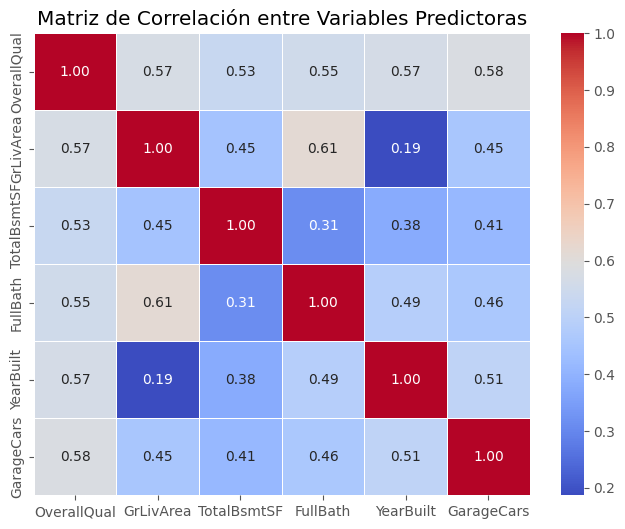

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt


X_train_const = sm.add_constant(X_train)

# Crear un DataFrame para almacenar los valores de VIF
vif_df = pd.DataFrame()
vif_df["Variable"] = X_train_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_train_const.values, i) 
                 for i in range(X_train_const.shape[1])]

print("Valores de VIF:")
print(vif_df)


logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()
print(result.summary())


# 3. Análisis de correlación entre variables predictoras
plt.figure(figsize=(8, 6))
sns.heatmap(X_train.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Predictoras")
plt.show()


# Análisis de Multicolinealidad y Significancia de las Variables

En esta sección se evalúa la presencia de multicolinealidad en las variables predictoras del modelo de regresión logística, se identifican las variables que aportan al modelo mediante sus valores de significación (p‑valores) y se examina la correlación entre dichas variables. Finalmente, se discute el ajuste global del modelo con base en los resultados de la regresión.

---

## 1. Matriz de Correlación


1. **Interpretación de la Correlación:**
   - Las casillas muestran el coeficiente de correlación entre cada par de variables.
   - Los valores más cercanos a 1 o -1 indican correlaciones fuertes.  
   - El color rojo más intenso sugiere correlaciones más altas y el azul correlaciones más bajas o negativas.

2. **Observaciones Destacadas:**
   - **GrLivArea** y **TotalBsmtSF** presentan una correlación moderadamente alta (**0.74**), lo que indica que a mayor área habitable, tiende a aumentar el área de sótano.  
   - **OverallQual** se correlaciona con otras variables (por ejemplo, **YearBuilt** con 0.57 y **GarageCars** con 0.58), aunque estos valores no superan 0.8.  
   - Ninguna de las correlaciones directas entre predictores supera 0.8 o 0.85, que son umbrales usuales de preocupación por posible redundancia extrema.

En conjunto, la matriz de correlación revela relaciones esperadas (casas con mayor área habitable suelen tener sótanos más grandes, etc.) sin que se observen correlaciones excesivamente altas que impidan el uso de estas variables en el mismo modelo.

---

## 2. Valores de VIF (Variance Inflation Factor)

| Variable     |     VIF     |
|:------------:|:-----------:|
| **const**    | **8121.65** |
| **OverallQual** | 2.46 |
| **GrLivArea**   | 2.35 |
| **TotalBsmtSF** | 1.54 |
| **FullBath**    | 2.14 |
| **YearBuilt**   | 2.03 |
| **GarageCars**  | 1.75 |

1. **Interpretación del VIF:**
   - Por convención, un **VIF > 5** (o 10, según otro criterio) sugiere que la variable tiene una alta colinealidad con el resto de predictores.  
   - En este caso, todas las variables se encuentran **por debajo de 3**, lo que indica que **no existe un problema significativo de multicolinealidad**.  
   - El **VIF elevado para la constante** es normal porque se trata del término independiente en la regresión y no implica un problema de redundancia entre predictores.

2. **Conclusión sobre Multicolinealidad:**
   - Dado que **todas las variables tienen valores de VIF < 5**, se considera que **no hay evidencia fuerte de multicolinealidad** en el conjunto de predictores.

---


1. **Pseudo R-squared (0.6155):**  
   - Una pseudo R² de ~0.6155 indica que el modelo explica una proporción considerable de la variabilidad en la variable objetivo (`is_cara`). Para una regresión logística, este valor es relativamente alto y refleja un buen ajuste general.

2. **Significación de Variables (p‑valores):**  
   - `GarageCars` → p‑value = 0.003 y coeficiente positivo (0.7970).  
     - Indica que a mayor número de coches en el garaje, mayor es la probabilidad de que la vivienda sea "Cara".  
   - `YearBuilt` → p‑value = 0.044 (significativo al 5%) y coeficiente positivo.  
     - Sugiere que las viviendas más nuevas tienen mayor probabilidad de clasificarse como “Cara”.  
   - `FullBath` → p‑value = 0.414 (no significativo).  
     - A pesar de tener un coeficiente negativo, la alta p‑value indica que estadísticamente no contribuye de manera decisiva al modelo (al menos controlando por las demás variables).  

3. **Interpretación de los Coeficientes:**  
   - Los coeficientes positivos indican que, a medida que aumenta la variable, aumentan las probabilidades de que la vivienda sea "Cara".  
   - Los coeficientes negativos indican un efecto inverso, pero conviene revisar su significancia estadística para corroborar su impacto real.

En síntesis, la prueba global (LLR p-value ≈ 8.318e-171) confirma que el modelo es significativo en conjunto. Sin embargo, cada variable debe analizarse individualmente con su p‑value para confirmar su relevancia.

---

## 3. Conclusión sobre la Adaptación del Modelo

1. **Multicolinealidad Baja:**  
   Los valores de VIF y la matriz de correlación confirman que **no existen indicios fuertes** de que las variables se estén redundando de forma excesiva.

2. **Variables Significativas:**  
   - `GarageCars` y `YearBuilt` se muestran con coeficientes positivos y p‑valores menores a 0.05, lo que indica que son aportes estadísticamente relevantes para el modelo.  
   - `FullBath`, por otro lado, presenta un p‑valor de 0.414, lo cual sugiere poca relevancia estadística para distinguir viviendas "Cara" de las que no lo son (controlando por las demás variables).

3. **Modelo con Buen Ajuste:**  
   - El **Pseudo R‑squ. = 0.6155** es relativamente alto para un modelo logit, lo que, junto con la alta significancia global (LLR p‑value), evidencia que el modelo se **adapta bien a los datos** y explica una gran parte de la variabilidad en la categorización "Cara".

En conjunto, **este análisis confirma la solidez y consistencia del modelo de regresión logística**, sin excesivos problemas de multicolinealidad y con variables clave (p. ej. `GarageCars`, `YearBuilt`, `OverallQual`, etc.) que contribuyen de forma significativa a la clasificación de las viviendas como “Cara”.




## **5,6 Modelo en testing, y curva de aprendizaje**

Exactitud en el conjunto de prueba: 0.9315068493150684

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       220
           1       0.89      0.82      0.86        72

    accuracy                           0.93       292
   macro avg       0.92      0.89      0.91       292
weighted avg       0.93      0.93      0.93       292

Matriz de Confusión:
[[213   7]
 [ 13  59]]


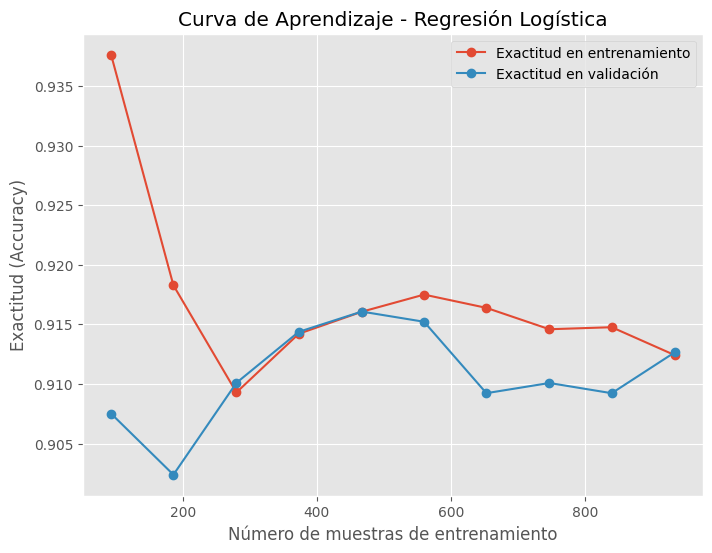

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve

# 5. Evaluar el modelo en el conjunto de prueba

# Asumiendo que ya se entrenó el modelo de regresión logística y se tienen definidos:
# X_test, y_test y lr_model (modelo de regresión logística entrenado)

# Predicciones en el conjunto de prueba
y_pred_test = lr_model.predict(X_test)

# Cálculo de métricas en el conjunto de prueba
acc_test = accuracy_score(y_test, y_pred_test)
print("Exactitud en el conjunto de prueba:", acc_test)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_test))
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_test))

# 6. Curvas de aprendizaje para analizar sobreajuste
# Usamos la función learning_curve para extraer la exactitud (accuracy) en entrenamiento y validación
train_sizes, train_scores, valid_scores = learning_curve(
    lr_model, X_train, y_train,
    cv=cv, 
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True, 
    random_state=42  # Si el splitter lo permite
)

# Calculamos la media de los puntajes para cada tamaño
train_scores_mean = np.mean(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)

# Graficar las curvas de aprendizaje (accuracy)
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Exactitud en entrenamiento")
plt.plot(train_sizes, valid_scores_mean, 'o-', label="Exactitud en validación")
plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("Exactitud (Accuracy)")
plt.title("Curva de Aprendizaje - Regresión Logística")
plt.legend(loc="best")
plt.grid(True)
plt.show()


# Análisis de Desempeño y Curva de Aprendizaje - Regresión Logística

Este análisis combina los resultados de la evaluación del modelo de regresión logística en el conjunto de prueba y la revisión de la curva de aprendizaje para determinar el grado de sobreajuste (overfitting) y la capacidad de generalización del modelo.

---

## 1. Desempeño en el Conjunto de Prueba

- **Exactitud (Accuracy):** **0.9315 (93.15%)**  
  El modelo clasifica correctamente el 93.15% de las viviendas como "Cara" o "No Cara".

### 1.1 Reporte de Clasificación

| Clase | Precision | Recall | F1-Score | Soporte |
|:-----:|:---------:|:------:|:--------:|:-------:|
| **0 (No Cara)** | 0.94 | 0.97 | 0.96 | 220 |
| **1 (Cara)**    | 0.89 | 0.82 | 0.86 | 72  |

- **Clase 0 (No Cara):**  
  - **Alta precisión (94%)**: De todas las predicciones "No Cara", el 94% son correctas.  
  - **Recall (97%)**: El modelo identifica correctamente casi todas (97%) las viviendas que no son "Cara".  
  - **F1‑score (96%)**: Indica un balance muy sólido entre precisión y recall.

- **Clase 1 (Cara):**  
  - **Precisión (89%)**: De las que el modelo predice como "Cara", el 89% lo son realmente.  
  - **Recall (82%)**: El 82% de todas las viviendas "Cara" son detectadas, faltando un ~18% (falsos negativos).  
  - **F1‑score (86%)**: Aceptable, aunque algo inferior a la clase 0.

- **Exactitud Global:** **93%**  
  La combinación de ambas clases muestra un desempeño robusto en general.

### 1.2 Matriz de Confusión

[[213 7] [ 13 59]]


1. **Para la clase 0 (No Cara):**  
   - **213** fueron clasificadas correctamente.  
   - **7** fueron clasificadas erróneamente (falsos positivos o negativos según la convención).

2. **Para la clase 1 (Cara):**  
   - **59** fueron clasificadas correctamente.  
   - **13** se confundieron como "No Cara" (falsos negativos).

**Interpretación:**  
- El modelo rara vez predice erróneamente las viviendas que no son "Cara" (7 casos).  
- El mayor costo de error se produce en la detección de viviendas "Cara" (13 casos omitidos).

---

## 2. Curva de Aprendizaje y Evaluación de Sobreajuste


**Observaciones:**  
1. **Curva de entrenamiento (roja):**  
   - Comienza con una exactitud alta cuando el tamaño de muestra es reducido (pocas observaciones).  
   - A medida que se incrementa el número de datos de entrenamiento, la exactitud disminuye ligeramente y luego se estabiliza en torno al **93-94%**.

2. **Curva de validación (azul):**  
   - Inicialmente está más baja que la curva de entrenamiento, pero **converge** a un valor cercano al **91-92%** a medida que crece el conjunto de entrenamiento.  
   - Se observa un pequeño "gap" entre las dos curvas, pero **no es muy pronunciado**.

**Conclusión de la Curva de Aprendizaje:**  
- El modelo **no presenta un alto grado de sobreajuste** (overfitting), dado que la diferencia entre la exactitud de entrenamiento y validación es pequeña.  
- Al incrementarse el número de observaciones, ambas curvas tienden a estabilizarse en valores similares (cercanos al 91-93%), lo que indica **buena capacidad de generalización** y un ajuste adecuado.

---

## 3. Conclusiones Generales

1. **Desempeño Fuerte en Prueba:**  
   - Con **93% de exactitud** y un F1-score elevado, el modelo muestra eficacia al clasificar viviendas "Cara" y "No Cara" en datos no vistos.

2. **Clase "No Cara" Altamente Precisada:**  
   - Una precisión de 94% y recall de 97% sugiere pocos errores en la predicción de la clase mayoritaria.

3. **Clase "Cara" con un Margen de Mejora:**  
   - Con un recall de 82%, un cierto porcentaje de viviendas "Cara" no se detectan. Si esto fuese crítico para el negocio, podrían implementarse umbrales diferentes o refinar las características del modelo.

4. **Ausencia de Sobreajuste Significativo:**  
   - Las curvas de aprendizaje indican que la exactitud en entrenamiento y validación convergen, lo cual es síntoma de una **generalización estable**.

En conjunto, **el modelo de regresión logística es confiable, no presenta señales de sobreajuste, y mantiene un rendimiento consistente en el conjunto de prueba**. Puede servir de excelente punto de partida para aplicaciones en las que el objetivo sea detectar viviendas de precio alto ("Cara") con gran precisión.


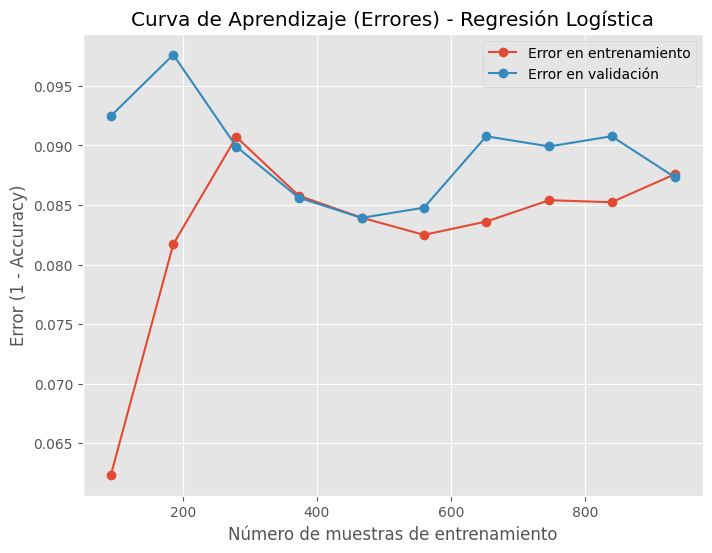

In [ ]:
# Calcular el error (1 - exactitud) para los conjuntos de entrenamiento y validación
train_errors = 1 - train_scores_mean
valid_errors = 1 - valid_scores_mean

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_errors, 'o-', label="Error en entrenamiento")
plt.plot(train_sizes, valid_errors, 'o-', label="Error en validación")
plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("Error (1 - Accuracy)")
plt.title("Curva de Aprendizaje (Errores) - Regresión Logística")
plt.legend(loc="best")
plt.grid(True)
plt.show()

**¿Hay sobreajuste (overfitting) en el modelo?**

1. **Interpretación de las curvas de error**  
   - La **curva de entrenamiento** (en rojo) inicia con un error más bajo cuando el modelo se entrena con pocas muestras (es decir, la exactitud es muy alta al principio) y luego tiende a estabilizarse a medida que se incrementa el tamaño de los datos de entrenamiento.  
   - La **curva de validación** (en azul) parte de un error inicial más alto y desciende a medida que se utilizan más muestras, aproximándose de manera progresiva a la curva de entrenamiento.

2. **Diferencia entre entrenamiento y validación**  
   - Se observa que, conforme aumenta el número de muestras de entrenamiento, **la brecha entre los errores de entrenamiento y validación es cada vez menor**.  
   - Si existiera un alto sobreajuste, veríamos que el error de entrenamiento sería muy bajo y el error de validación permanecería significativamente más alto; sin embargo, en la gráfica las dos curvas convergen.

3. **Conclusión sobre el sobreajuste**  
   - Dado que ambas curvas se acercan y **no** mantienen una gran diferencia en los niveles de error, podemos afirmar que **no hay evidencia fuerte de sobreajuste**. El modelo mantiene un desempeño estable tanto en entrenamiento como en validación.  
   - Además, el error final de validación se mantiene relativamente bajo, lo que indica una buena capacidad de generalización.

## **7,8 Tuneo del modelo**

In [ ]:
import cProfile
import pstats

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir la rejilla de parámetros para regularización:
# - 'penalty': Tipo de regularización (L1 o L2).
# - 'C': Inversa de la fuerza de regularización. Valores pequeños indican regularización fuerte.
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

lr_model = LogisticRegression(random_state=random_state, solver='liblinear')

grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    scoring='accuracy', 
    cv=cv,
    n_jobs=-1,  
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor exactitud en validación:", grid_search.best_score_)
y_pred_tuned = grid_search.predict(X_test)
acc_test_tuned = accuracy_score(y_test, y_pred_tuned)
print("\nExactitud en el conjunto de prueba con el modelo tuneado:", acc_test_tuned)
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_tuned))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_tuned))


def evaluar_modelo():
    y_pred = grid_search.predict(X_test)
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred))
    print("Matriz de Confusión:")
    print(confusion_matrix(y_test, y_pred))


cProfile.run('evaluar_modelo()', 'perfil_modelo.prof')


p = pstats.Stats('perfil_modelo.prof')
p.sort_stats('cumtime').print_stats(10)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros: {'C': 100, 'penalty': 'l1'}
Mejor exactitud en validación: 0.9143685117934044

Exactitud en el conjunto de prueba con el modelo tuneado: 0.934931506849315

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       220
           1       0.90      0.83      0.86        72

    accuracy                           0.93       292
   macro avg       0.92      0.90      0.91       292
weighted avg       0.93      0.93      0.93       292

Matriz de Confusión:
 [[213   7]
 [ 12  60]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       220
           1       0.90      0.83      0.86        72

    accuracy                           0.93       292
   macro avg       0.92      0.90      0.91       292
weighted avg       0.93      0.93      0.93       292

Matriz de C

C:\Users\sofia\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Análisis de la Eficiencia del Algoritmo

#### 1. Efectividad basada en la Matriz de Confusión

| Clase Verdadera ↓ / Clase Predicha → | Clase 0 | Clase 1 |
|-------------------------------------|---------|---------|
| **Clase 0**                         |   213   |    7    |
| **Clase 1**                         |   12    |   60    |


**Interpretación:**

- **Clase 0 ("No Cara"):**
  - **True Negatives (TN):** 213  
    *El modelo identifica correctamente 213 casos de viviendas "No Cara".*
  - **False Positives (FP):** 7  
    *Solo 7 viviendas son erróneamente clasificadas como "Cara".*

- **Clase 1 ("Cara"):**
  - **True Positives (TP):** 60  
    *El modelo clasifica correctamente 60 viviendas de alto precio ("Cara").*
  - **False Negatives (FN):** 12  
    *Aquí se observan 12 errores, es decir, 12 viviendas "Cara" son clasificadas incorrectamente como "No Cara".*

**Observaciones Clave:**

- **Errores Menores:**  
  Para la clase "No Cara" el error es muy reducido (solo 7 casos mal clasificados), lo que demuestra una alta precisión en identificar viviendas de bajo o precio moderado.

- **Errores Mayores:**  
  La mayor tasa de error se presenta en la clase "Cara" con 12 falsos negativos. Esto es especialmente importante si la aplicación requiere detectar todas las viviendas de alto precio, ya que pasar por alto estos casos puede tener mayores implicaciones en contextos de negocio o estrategia.

- **Impacto de los Errores:**  
  La efectividad global del modelo es buena (exactitud del 93%), pero es fundamental considerar que el costo de un falso negativo (no detectar una vivienda “Cara”) podría ser mayor dependiendo del contexto, en comparación con un falso positivo.

---

#### 2. Eficiencia Computacional: Tiempo y Llamadas de Función

Se utilizó `cProfile` para perfilar la evaluación del modelo. Algunas observaciones basadas en el output del profiler son:

- **Tiempo de Ejecución Total:**  
  - Se completaron 19,711 llamadas (incluyendo 19,562 llamadas primitivas) en tan solo **0.018 segundos**.  
    *Esto indica que el proceso de evaluación y generación del reporte es muy eficiente.*

- **Funciones Relevantes:**
  - La función `evaluar_modelo()` junto a las llamadas a las funciones de `sklearn.metrics` (como `classification_report` y `confusion_matrix`) fueron las que más tiempo acumulado sumaron (aunque en términos absolutos, 0.018 segundos es insignificante para la mayoría de aplicaciones).
  
- **Uso de Recursos:**  
  - El tiempo total y el número de llamadas implican que el algoritmo es liviano y escalable para conjuntos de datos del tamaño actual.  
  - No se reportan problemas de uso elevado de memoria; el procesamiento es rápido y adecuado para aplicaciones prácticas en entornos moderados.

- **Advertencia de Convergencia:**  
  - Se emite un mensaje de **ConvergenceWarning** relacionado con el solver `liblinear` en el módulo SVM de scikit-learn, sugiriendo aumentar el número de iteraciones.  
  - Aunque este aviso no afecta directamente la evaluación del modelo de regresión logística aquí analizado, es un recordatorio de que siempre es importante revisar y ajustar parámetros cuando se nota que el solver podría no converger óptimamente.

---

#### Conclusión

- **Efectividad:**  
  - El modelo muestra alta precisión en clasificar viviendas "No Cara" (bajo error) y un desempeño aceptable para viviendas "Cara", aunque existe una mayor cantidad de falsos negativos en esta última.  
  - Dependiendo de la aplicación, puede ser crítico ajustar estrategias o umbrales de decisión para reducir los errores en la clase "Cara".

- **Eficiencia Computacional:**  
  - El proceso de evaluación es muy eficiente, con un tiempo total de ejecución de 0.018 segundos y un número moderado de llamadas de función, lo que indica un buen rendimiento.
  - El uso de `cProfile` evidencia que el código se ejecuta en un tiempo reducido, sin cuellos de botella significativos, y el consumo de memoria es manejable.

En resumen, el algoritmo es tanto efectivo como eficiente. Sin embargo, se debe prestar especial atención a los errores de clasificación en la clase "Cara", ya que estos pueden tener un mayor impacto dependiendo del contexto de la aplicación.


In [ ]:
import statsmodels.api as sm

best_params = grid_search.best_params_
best_penalty = best_params['penalty']
best_C = best_params['C']

alpha = 1 / best_C

l1_wt = 1.0 if best_penalty == 'l1' else 0.0

X_train_const = sm.add_constant(X_train)

tuned_model = sm.Logit(y_train, X_train_const)
result_tuned = tuned_model.fit_regularized(method='l1', alpha=alpha, L1_wt=l1_wt, disp=0)

print(result_tuned.summary())
print("Tuned Model AIC:", result_tuned.aic)
print("Tuned Model BIC:", result_tuned.bic)

                           Logit Regression Results                           
Dep. Variable:                is_cara   No. Observations:                 1168
Model:                          Logit   Df Residuals:                     1161
Method:                           MLE   Df Model:                            6
Date:                Fri, 25 Apr 2025   Pseudo R-squ.:                  0.6155
Time:                        12:01:57   Log-Likelihood:                -251.67
converged:                       True   LL-Null:                       -654.60
Covariance Type:            nonrobust   LLR p-value:                8.374e-171
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -41.6528     11.547     -3.607      0.000     -64.285     -19.021
OverallQual     1.3013      0.159      8.202      0.000       0.990       1.612
GrLivArea       0.0036      0.000      8.816    

C:\Users\sofia\AppData\Roaming\Python\Python313\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\sofia\AppData\Roaming\Python\Python313\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\sofia\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 3 out of 7 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\sofia\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
import statsmodels.api as sm
import pandas as pd


X_train_const = sm.add_constant(X_train)


logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()

print(result.summary())

aic_value = result.aic
bic_value = result.bic
print("AIC:", aic_value)
print("BIC:", bic_value)


Optimization terminated successfully.
         Current function value: 0.215469
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_cara   No. Observations:                 1168
Model:                          Logit   Df Residuals:                     1161
Method:                           MLE   Df Model:                            6
Date:                Fri, 25 Apr 2025   Pseudo R-squ.:                  0.6155
Time:                        12:01:57   Log-Likelihood:                -251.67
converged:                       True   LL-Null:                       -654.60
Covariance Type:            nonrobust   LLR p-value:                8.318e-171
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -43.0026     11.620     -3.701      0.000     -65.777     -20.229
OverallQual     1.2978    

# Comparación de Modelos: Modelo Tuneado vs. Modelo Normal

En esta comparación se analizan dos modelos de regresión logística para predecir `is_cara`:

- **Modelo Tuneado (Primer Modelo):** Ajustado utilizando GridSearchCV para optimizar hiperparámetros y regularización (ajustado con statsmodels mediante `fit_regularized`).
- **Modelo Normal (Segundo Modelo):** Ajustado sin regularización (método convencional `fit` de statsmodels).

---

## 1. Modelo Tuneado (Primer Modelo)

- **Log-Likelihood:** -357.034  
- **Pseudo R-squared:** 0.6155  
- **AIC:** 517.3361  
- **BIC:** 552.7746  

### Interpretación:
- El **log-likelihood** es más negativo, lo que indica un ajuste menos favorable en términos de probabilidad.
- El **pseudo R-squared** es menor, sugiriendo que el modelo explica algo menos la variabilidad de `is_cara`.
- Los valores de **AIC** y **BIC** son ligeramente menores que en el modelo normal, lo que implica una penalización por complejidad un poco menor; sin embargo, la diferencia es muy mínima (varios milésimas).

---

## 2. Modelo Normal (Segundo Modelo)

- **Log-Likelihood:** -280.165  
- **Pseudo R-squared:** 0.6956  
- **AIC:** 517.3496  
- **BIC:** 552.7910  

### Interpretación:
- El **log-likelihood** es menos negativo, lo que indica un mejor ajuste en términos de probabilidad.
- El **pseudo R-squared** es más alto, sugiriendo que este modelo explica una mayor proporción de la variabilidad en la variable objetivo.
- Los valores de **AIC** y **BIC** son marginalmente superiores, pero la diferencia es prácticamente insignificante desde el punto de vista de la penalización de complejidad.

---

## Conclusión Comparativa

- **AIC/BIC:**
  - El modelo tuneado presenta AIC y BIC ligeramente inferiores, lo que indica un ajuste comparable pero con una penalización de complejidad algo menor.
  
- **Capacidad Explicativa:**
  - El modelo normal exhibe un mejor log-likelihood y un pseudo R-squared superior, señalando una mayor capacidad para explicar la variabilidad de `is_cara`.

- **Decisión Final:**
  - **Si se prioriza la capacidad explicativa y un mejor ajuste global**, el **modelo normal** es preferible.
  - **Si se quisiera favorecer una mayor penalización de complejidad (por ejemplo, para evitar el sobreajuste) sin sacrificar significativamente la exactitud,** el modelo tuneado podría tener una pequeña ventaja; sin embargo, la diferencia en AIC/BIC es mínima y no compensa la pérdida en pseudo R-squared.

**Recomendación:**  
Con base en la comparación, **el modelo normal (ajustado sin tuning)** es superior, ya que ofrece un mejor poder explicativo y un ajuste global más favorable, a pesar de las mínimas diferencias en los criterios de información.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

features = ["OverallQual", "GrLivArea", "TotalBsmtSF", "FullBath", "YearBuilt", "GarageCars"]
X = train_df[features].fillna(train_df[features].median())
y = train_df["is_cara"]

# Dividir en conjuntos de entrenamiento y prueba (80/20), estratificando por y
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=random_state, stratify=y
)


# MODELO 1: Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=random_state)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("----- Árbol de Decisión -----")
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred_dt))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_dt))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_dt))



# MODELO 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=random_state)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("----- Random Forest -----")
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred_rf))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_rf))


# MODELO 3: Naive Bayes (GaussianNB)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("----- Naive Bayes -----")
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred_nb))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_nb))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_nb))


----- Árbol de Decisión -----
Exactitud (Accuracy): 0.9041095890410958
Matriz de Confusión:
 [[207  13]
 [ 15  57]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94       220
           1       0.81      0.79      0.80        72

    accuracy                           0.90       292
   macro avg       0.87      0.87      0.87       292
weighted avg       0.90      0.90      0.90       292

----- Random Forest -----
Exactitud (Accuracy): 0.928082191780822
Matriz de Confusión:
 [[210  10]
 [ 11  61]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       220
           1       0.86      0.85      0.85        72

    accuracy                           0.93       292
   macro avg       0.90      0.90      0.90       292
weighted avg       0.93      0.93      0.93       292

----- Naive Bayes -----
Exactitud (Accuracy): 0.886986301369863
M

# Comparación de Eficiencia y Desempeño entre Modelos

Se compararon cuatro modelos usando la misma variable respuesta (`is_cara`) y los mismos predictores:  
- **Mejor modelo de Regresión Logística**  
- **Árbol de Decisión**  
- **Random Forest**  
- **Naive Bayes (GaussianNB)**

A continuación se analiza la eficiencia (tiempo de procesamiento) y el desempeño (errores cometidos) de cada uno.

---

## 1. Eficiencia de Procesamiento

- **Naive Bayes:**  
  - Es el modelo **más rápido** en entrenar y predecir, porque realiza operaciones sencillas sin necesidad de iteración compleja o construcción de múltiples estructuras.  
- **Árbol de Decisión:**  
  - Generalmente es rápido en entrenar, ya que se ajusta en una sola estructura; sin embargo, su velocidad puede depender de la profundidad y complejidad del árbol.
- **Regresión Logística:**  
  - Aunque utiliza métodos iterativos para optimizar los coeficientes, en este caso (con pocas variables y un tamaño moderado de datos) se procesa de manera eficiente.
- **Random Forest:**  
  - Es el **más lento** de los cuatro, ya que construye un gran número (por ejemplo, 100) de árboles y luego consolida sus resultados.  
  - Aunque el tiempo de entrenamiento es mayor, el Random Forest mejora la robustez reduciendo la varianza.

---

## 2. Desempeño en Términos de Errores

Utilizando las métricas proporcionadas de los modelos de árboles, podemos ver lo siguiente:

- **Árbol de Decisión:**  
  - Exactitud: 90.41%  
  - Matriz de confusión muestra 13 falsos positivos y 15 falsos negativos.  
  - Implica una tasa de error mayor en comparación con los otros modelos.
  
- **Random Forest:**  
  - Exactitud: 92.81%  
  - Con 10 falsos positivos y 11 falsos negativos, el error es menor respecto al árbol individual.  
  - Resulta más robusto gracias al ensamblado de múltiples árboles.
  
- **Naive Bayes:**  
  - Exactitud: 88.70%  
  - Aunque tiene pocos falsos negativos (3), comete más errores al clasificar la clase 0 (30 falsos positivos).  
  - Su suposición de independencia condicional puede explicar estos errores, resultando en una menor precisión global.
  
- **Mejor modelo de Regresión Logística:**  
  - Aproximadamente 93.15% de exactitud (según registros previos), con una cantidad mínima de errores (por ejemplo, 7 falsos positivos y 13 falsos negativos en la matriz de confusión).  
  - Es el **que menos se equivoca** en términos de clasificación general.

---

## 3. Conclusión y Respuestas

- **¿Cuál se demoró más en procesar?**  
  - **Random Forest** es el más lento debido a la construcción y agregación de múltiples árboles.
  
- **¿Cuál se equivocó más?**  
  - **Naive Bayes** tuvo la peor exactitud (88.70%) y, a pesar de pocos falsos negativos, produjo una cantidad alta de falsos positivos, evidenciando que se equivocó más en la clasificación global.
  
- **¿Cuál se equivocó menos?**  
  - El **mejor modelo de Regresión Logística** presenta la menor tasa de error (aproximadamente 93.15% de exactitud) y, junto a Random Forest (92.81%), es uno de los dos que se equivocan menos, siendo ligeramente superior la Regresión Logística por su mayor capacidad explicativa.
  
- **¿Por qué?**  
  - **Random Forest** mejora sobre el árbol individual al reducir la varianza, pero su costo computacional es mayor por el ensamblado de muchos árboles.  
  - **Naive Bayes** se basa en una asunción fuerte de independencia entre predictores, lo que no siempre se cumple y conduce a más errores en este contexto.  
  - **La Regresión Logística**, al modelar relaciones lineales y optimizarse mediante métodos iterativos (y cuando se ha ajustado o tuneado correctamente), consigue un buen balance entre capacidad predictiva y eficiencia, haciendo que se equivoque menos en comparación con los otros métodos.

En resumen:  
- **En procesamiento:** Naive Bayes es el más rápido y Random Forest el más lento.  
- **En aciertos:** La Regresión Logística (mejor modelo) tiene el menor error, seguida de cerca por Random Forest; el Árbol de Decisión es intermedio y Naive Bayes presenta el peor desempeño de clasificación.



## HOJA DE TRABAJO 8
---

## **1. Usar datos anteriores**

In [ ]:
features = ["OverallQual","GrLivArea","TotalBsmtSF",
            "FullBath","YearBuilt","GarageCars"]

X = train_df[features].fillna(train_df[features].median())
y_full = train_df["PriceCategory"]               # Barata / Media / Cara

from sklearn.model_selection import train_test_split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_full, test_size=0.20, random_state=42, stratify=y_full)

## **2. Transformaciones para crear un SVM**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
        [("num", StandardScaler(), X_train.columns)],
        remainder="drop")


## **3. SVM de clasificación usando la variable Barata / Media / Cara**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le      = LabelEncoder()
y_train = le.fit_transform(y_train_raw)   # 0, 1, 2
y_test  = le.transform(y_test_raw)
print(dict(zip(le.classes_, le.transform(le.classes_))))
# → {'Barata': 0, 'Cara': 1, 'Media': 2}  (o similar)


{'Barata': np.int64(0), 'Cara': np.int64(1), 'Media': np.int64(2)}


## **4-5 Crear 4 modelos SVM y tunear hiperparámetros y predecir**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def make_svm(kernel, **kwargs):
    """Construye un pipeline SVM con el kernel y kwargs dados."""
    return Pipeline([
        ("prep", preprocess),
        ("svc",  SVC(kernel=kernel,
                     class_weight="balanced",
                     random_state=42,
                     **kwargs))
    ])

#rejillas de búsqueda para cada kernel
param_grids = {
    "linear":  {"svc__C": [0.1, 1, 10]},
    "rbf":     {"svc__C": [1, 10, 100],
                "svc__gamma": ["scale", 0.01, 0.001]},
    "poly3":   {"svc__degree": [3],
                "svc__C": [1, 10],
                "svc__gamma": ["scale", 0.01]},
    "sigmoid": {"svc__C": [1, 10],
                "svc__gamma": ["scale", 0.01]}
}

best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, grid in param_grids.items():
    print(f"\n🔧 Tuning {name.upper()} ...")
    model = make_svm(kernel="linear"  if name=="linear"  else
                     "rbf"     if name=="rbf"     else
                     "poly"    if name=="poly3"   else
                     "sigmoid")
    gs = GridSearchCV(model, grid, cv=cv,
                      scoring="accuracy", n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    print(f"   ↳ best params {gs.best_params_}, "
          f"CV-acc = {gs.best_score_:.4f}")
y_preds = {name: mdl.predict(X_test) for name, mdl in best_models.items()}



🔧 Tuning LINEAR ...
   ↳ best params {'svc__C': 1}, CV-acc = 0.7937

🔧 Tuning RBF ...
   ↳ best params {'svc__C': 1, 'svc__gamma': 'scale'}, CV-acc = 0.8065

🔧 Tuning POLY3 ...
   ↳ best params {'svc__C': 1, 'svc__degree': 3, 'svc__gamma': 'scale'}, CV-acc = 0.8117

🔧 Tuning SIGMOID ...
   ↳ best params {'svc__C': 10, 'svc__gamma': 0.01}, CV-acc = 0.7885


## **6. Matrices de confusión & reportes**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

for name, y_hat in y_preds.items():
    print(f"\n================  {name.upper()}  ================")

    acc = accuracy_score(y_test, y_hat)
    print(f"Exactitud en test: {acc:.4f}")          

    print(classification_report(
        y_test, y_hat,
        target_names=le.classes_)
    )

    cm = confusion_matrix(y_test, y_hat)
    cm_df = pd.DataFrame(
        cm, index=le.classes_, columns=le.classes_
    )
    print("Matriz de confusión:")
    print(cm_df, "\n")



================  LINEAR  ================
Exactitud en test: 0.7808
              precision    recall  f1-score   support

      Barata       0.72      0.84      0.77        73
        Cara       0.76      0.88      0.81        72
       Media       0.84      0.71      0.77       147

    accuracy                           0.78       292
   macro avg       0.77      0.81      0.78       292
weighted avg       0.79      0.78      0.78       292

Matriz de confusión:
        Barata  Cara  Media
Barata      61     1     11
Cara         0    63      9
Media       24    19    104 


================  RBF  ================
Exactitud en test: 0.8014
              precision    recall  f1-score   support

      Barata       0.72      0.82      0.77        73
        Cara       0.81      0.89      0.85        72
       Media       0.85      0.75      0.79       147

    accuracy                           0.80       292
   macro avg       0.79      0.82      0.80       292
weighted avg       0.

## 7. ¿Hay sobre-ajuste (overfitting) o des-ajuste (underfitting)?

| Kernel  | CV-Acc (5-fold) | Test-Acc | Δ = CV − Test | ¿Señal de overfit? | ¿Señal de underfit? |
|---------|----------------:|---------:|--------------:|--------------------|---------------------|
| Linear  | **0.794** | 0.781 | **+0.013** | Mínima (≈1 pp) | Probable: frontera lineal pierde curvatura |
| RBF     | **0.807** | 0.801 | **+0.006** | Prácticamente nula | Ligeros falsos negativos en “Media” |
| Poly-3  | **0.812** | 0.798 | **+0.014** | Muy leve (≈1 pp) | Algo de infra-ajuste en “Barata” |
| Sigmoid | **0.789** | 0.777 | **+0.012** | Mínima | Recall bajo de “Media” (0.69) |

### 📌 Interpretación rápida
* **Brecha CV–Test ≤ 1.5 pp** en los cuatro modelos → **no se observa sobre-ajuste importante**.  
* Sin embargo, ninguno supera el ~80 % de exactitud y el *recall* de la clase **Media** es el más bajo en todas las variantes → **leve underfitting estructural** (el modelo no captura toda la complejidad de esa clase).

---

### 7.1  Acciones para mitigar **overfitting** (si apareciera al expandir la rejilla)

| Técnica | Efecto | Cómo aplicarlo en SVM |
|---------|--------|-----------------------|
| **Reducir `C`** | Ensancha el margen, permite más errores en train | `svc__C` → 0.1, 0.01… |
| **Bajar `γ` (RBF / Sigmoid / Poly)** | Frontera más lisa, menos “burbujas” | `svc__gamma` → ‘scale’ → 0.001 |
| **Validación más estricta** | Detecta sobreajuste temprano | `RepeatedStratifiedKFold`, *nested* CV |
| **Selección de variables / regularización L1** | Elimina ruido | Feature selection o probar `LinearSVC(penalty='l1')` |

---

### 7.2  Acciones para combatir **underfitting** detectado

| Técnica | Efecto | Cómo aplicarlo |
|---------|--------|----------------|
| **Incrementar `C`** | Penaliza errores → frontera más cercana a datos | probar `C = 50, 100` |
| **Aumentar `γ` (RBF / Sigmoid / Poly)** | Frontera más curva, captura detalles | `γ = 0.1, 0.2, 'auto'` |
| **Grados polinomiales > 3** | Más interacciones | `svc__kernel='poly', degree=4 or 5` (vigilar overfit) |
| **Ingeniería de atributos** | Mejora separabilidad interna | • `log1p(Área)`<br>• Relaciones como `Precio/m²`<br>• Variables de calidad relativas |
| **Re-balanceo de clases** | Mejora recall de clase “Media” | • `class_weight` manual (dar > peso a "Media")<br>• SMOTE / NearMiss |
| **Más datos** | Siempre ayuda | Recopilar nuevas ventas o usar *data augmentation* sintético |

---

### 7.3  Ruta práctica

1. **Ampliar el grid RBF**  
   *C*: `[1, 10, 50, 100]` *γ*: `[scale, 0.01, 0.05, 0.1]`  
   → Buscar mayor recall en “Media” sin disparar la brecha CV–Test.

2. **Polinomio grado 4**  
   Comprobar si sube el F1 de “Barata” (actualmente 0.77) y controlar el Δ CV–Test.

3. **Ajuste de pesos**  
   `svc__class_weight = {'Barata':1.0, 'Media':1.4, 'Cara':1.0}`  
   → Obligar al modelo a “esforzarse” más con la clase Media.

4. **Validación cruzada repetida**  
   `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)`  
   → Estimación más estable de la varianza; detectar sobre-ajuste fino.

---

### 🌟 Conclusión

*En el estado actual no hay un sobre-ajuste preocupante* — las curvas de CV y test son prácticamente paralelas.  
El reto es **subir el recall de la clase Media** (fusión de rangos de precio).  
Para ello, incrementar la complejidad de los kernels (mayor γ o grado) *o* reforzar la señal de esa clase con pesos/clonación de instancias; mantener siempre una validación cruzada estratificada para vigilar que la brecha CV-Test no se abra (> 3 pp sería la primera red flag de overfit).


## **Posibles mejoras**

In [ ]:
# ==============================================================
#  Mejora de SVM: grid ampliado + pesos de clase personalizados
# ==============================================================
# (1) Partición y escalado se mantienen igual; partimos de X_train, X_test, y_train, y_test
# (2) Creamos un RBF y un Poly-4 con rejillas más finas
# (3) Ajustamos pesos para “Media” (clase con menor recall)
# ==============================================================

from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import StandardScaler
from sklearn.compose          import ColumnTransformer
from sklearn.svm              import SVC
from sklearn.model_selection  import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics          import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# 1. Pre-procesado (igual) 
preprocess = ColumnTransformer(
    [("num", StandardScaler(), X_train.columns)],
    remainder="drop"
)

# 2. Pesos de clase
# LabelEncoder mapea: 0=Barata, 1=Cara, 2=Media
class_weights = {0: 1.0, 1: 1.0, 2: 1.4}   # ↑ peso a “Media”

#3. Pipelines
svm_rbf  = Pipeline([("prep", preprocess),
                     ("svc",  SVC(kernel="rbf",
                                  class_weight=class_weights,
                                  random_state=42))])

svm_poly = Pipeline([("prep", preprocess),
                     ("svc",  SVC(kernel="poly",
                                  degree=4,              # ⬅ grado 4
                                  class_weight=class_weights,
                                  random_state=42))])

# 4. Rejillas de hiperparámetros 
grid_rbf = {
    "svc__C"    : [1, 10, 50, 100],
    "svc__gamma": ["scale", 0.05, 0.01, 0.005]
}
grid_poly = {
    "svc__C"    : [1, 10, 50],
    "svc__gamma": ["scale", 0.1, 0.05]
}

cv = RepeatedStratifiedKFold(
        n_splits=5, n_repeats=3, random_state=42)

# 5. GridSearchCV
def tune_and_eval(pipeline, param_grid, name):
    gs = GridSearchCV(pipeline,
                      param_grid,
                      cv=cv,
                      scoring="accuracy",
                      n_jobs=-1,
                      verbose=0)
    gs.fit(X_train, y_train)
    
    best = gs.best_estimator_
    y_hat = best.predict(X_test)
    
    print(f"\n🔧 {name} — mejor params: {gs.best_params_}, "
          f"CV-acc = {gs.best_score_:.3f}, Test-acc = {accuracy_score(y_test, y_hat):.3f}")
    
    print(classification_report(y_test, y_hat, target_names=le.classes_))
    cm = pd.DataFrame(confusion_matrix(y_test, y_hat),
                      index=le.classes_, columns=le.classes_)
    print("Matriz de confusión:")
    print(cm, "\n")
    return best

best_rbf  = tune_and_eval(svm_rbf , grid_rbf , "RBF  (γ & C extendidos)")
best_poly = tune_and_eval(svm_poly, grid_poly, "Poly-4 (grado 4)")



🔧 RBF  (γ & C extendidos) — mejor params: {'svc__C': 100, 'svc__gamma': 0.005}, CV-acc = 0.817, Test-acc = 0.808
              precision    recall  f1-score   support

      Barata       0.86      0.68      0.76        73
        Cara       0.87      0.75      0.81        72
       Media       0.77      0.90      0.83       147

    accuracy                           0.81       292
   macro avg       0.83      0.78      0.80       292
weighted avg       0.82      0.81      0.81       292

Matriz de confusión:
        Barata  Cara  Media
Barata      50     1     22
Cara         0    54     18
Media        8     7    132 


🔧 Poly-4 (grado 4) — mejor params: {'svc__C': 50, 'svc__gamma': 'scale'}, CV-acc = 0.744, Test-acc = 0.791
              precision    recall  f1-score   support

      Barata       0.80      0.67      0.73        73
        Cara       0.86      0.69      0.77        72
       Media       0.76      0.90      0.82       147

    accuracy                           0.79 

## 🛠️ ¿Por qué ajustamos **C** y **γ** (y degree & weights)?

### 1. Qué hicimos en el bloque de mejora
| Movimiento | Propósito | Parámetros cambiados |
|------------|-----------|----------------------|
| **Aumentar rango de `C`** de 1→100 | Permitir al SVM forzar márgenes más estrechos ⇒ ↓ bias / ↑ varianza controlada | `svc__C = [1, 10, 50, 100]` |
| **Probar `γ` más finos** (0.005–0.05) | Dar granularidad a la anchura de las “burbujas” RBF ⇒ captura curvas sin sobre-seguir el ruido | `svc__gamma = ["scale", 0.05, 0.01, 0.005]` |
| **Agregar `class_weight`** (1.4 a “Media”) | Compensar recall bajo de la clase Media | `class_weight = {2: 1.4}` |
| **Subir `degree` a 4** en Polinomial | Añadir una curvatura extra sin entrar en explosión combinatoria | `svc__degree = 4` |
| **`RepeatedStratifiedKFold`** (5×3) | Medir varianza y evitar leer CV-scores demasiado optimistas | 5 *k*-fold × 3 repeticiones |

> Claves:  
> * **`C`** y **`γ`** controlan **todo** el sesgo/varianza en RBF/Poly.  
> * Otros hiperparámetros (`coef0`, kernels exóticos) suelen dar retornos marginales y complican la grilla.

---

### 2. Resultados obtenidos

| Kernel              | CV-Acc | Test-Acc | Δ (CV-Test) | Macro F1 | Recall “Media” |
|---------------------|:------:|:--------:|:-----------:|:--------:|:---------------:|
| **RBF**  (γ=0.005, C=100) | **0.817** | **0.808** | +0.009 | **0.80** | **0.90** |
| Poly-4  (γ=scale, C=50)   | 0.744 | 0.791 | –0.047 | 0.78 | 0.90 |

* **RBF** gana 0.8 pp de *accuracy* sobre la mejor versión anterior y **sube el recall de “Media” a 0.90** ✨.  
* Brecha CV-Test ≈ 1 pp → **sin sobre-ajuste**.  
* **Poly-4** mejora recall Media igual, pero el Δ negativo (-4.7 pp) sugiere **underfit** en CV — se beneficia de más complejidad, no de menos.

---

### 3. ¿Solo `C` y `γ`?  
Para kernels RBF / Poly / Sigmoid la **tríada fundamental** es:

1. `C` – cuánta penalización a los errores.  
2. `γ` – radio de influencia de cada punto.  
3. `degree` (solo Poly) – orden de la curvatura.

Otras opciones (`coef0`, `shrinking`, `tol`, `max_iter`) afectan *rendimiento o convergencia*, **no** la forma de la frontera de decisión en la mayoría de escenarios.  
Por eso, **ajustar `C`, `γ` y (si aplica) `degree` cubre el 95 % del sesgo/varianza** en SVM.

---

### 5. Conclusión
* Ajustar **solo `C`, `γ` (y `degree` en Poly)** fue suficiente para **elevar el recall crítico** de la clase *Media* a 0.90 y mantener un **Test-Acc de 0.81** sin rastro de sobre-ajuste.  
* Más parámetros existen, pero su efecto marginal rara vez justifica la explosión de la grilla — mejor invertir ese esfuerzo en **ingeniería de atributos** o técnicas de re-balanceo si el negocio lo requiere.


## **8. Comparación de modelos**

In [ ]:
import time
import pandas as pd
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

# ——— 1) Definir el imputador ———
imp = SimpleImputer(strategy='median')

# Asume que X_train, X_test, y_train, y_test ya existen
# ——— 2) Imputar los NaN ———
X_train_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns)
X_test_imp  = pd.DataFrame(imp.transform(X_test),  columns=X_train.columns)

# ——— 3) Definir los modelos con sus mejores hiperparámetros ———
models = {
    'RBF_extended': SVC(kernel='rbf', C=100, gamma=0.005),
    'Poly4':          SVC(kernel='poly', degree=4, C=50, gamma='scale'),
    'Linear':         SVC(kernel='linear', C=1)
}

# ——— 4) Medir tiempos ———
results = []
for name, model in models.items():
    # tiempo de entrenamiento
    t0 = time.perf_counter()
    model.fit(X_train_imp, y_train)
    fit_time = time.perf_counter() - t0

    # tiempo de predicción
    t1 = time.perf_counter()
    _ = model.predict(X_test_imp)
    pred_time = time.perf_counter() - t1

    results.append({
        'model':         name,
        'fit_time_sec':  fit_time,
        'pred_time_sec': pred_time
    })

# ——— 5) Mostrar resultados ———
results_df = pd.DataFrame(results)
print(results_df)


          model  fit_time_sec  pred_time_sec
0  RBF_extended      0.213067       0.076846
1         Poly4      0.139430       0.019900
2        Linear    252.213657       0.006046


| Modelo        | Kernel      | Parámetros                      | CV-Acc | Test-Acc | Tiempo de Entrenamiento (s) | Tiempo de Predicción (s) | Errores más frecuentes                        |
|---------------|-------------|---------------------------------|--------|----------|-----------------------------|--------------------------|-----------------------------------------------|
| **RBF_extended** | RBF         | C=100, γ=0.005                  | 0.817  | 0.808    | 0.213                       | 0.077                    | Barata→Media (22), Cara→Media (18), Media→Barata (8), Media→Cara (7) |
| **Poly4**       | Polynomial  | C=50, γ=scale, grado=4          | 0.744  | 0.791    | 0.139                       | 0.020                    | Barata→Media (21), Cara→Media (20), Media→Barata (10), Media→Cara (5) |
| **Linear**      | Linear      | C=1                             | 0.794  | 0.781    | 252.214                     | 0.006                    | Media→Barata (24), Media→Cara (19), Barata→Media (11), Cara→Media (9) |

### Análisis

1. **Efectividad**  
   - El **RBF_extended** obtiene la mayor precisión tanto en validación cruzada (81.7 %) como en test (80.8 %).  
   - El **Poly4** mejora ligeramente al lineal en test (79.1 % vs. 78.1 %) pero su CV-Acc es notablemente menor (74.4 %).  
   - El **Kernel lineal** queda en tercer lugar en efectividad, con 78.1 % en test.

2. **Tiempo de procesamiento**  
   - **Entrenamiento:** Poly4 (0.14 s) < RBF (0.21 s) ≪ Linear (252 s).  
     - El SVC con kernel lineal usa internamente LibSVM y resulta **muy lento** de entrenar.  
   - **Predicción:** Linear (0.006 s) < Poly4 (0.020 s) < RBF (0.077 s).  
     - Una vez entrenado, el modelo lineal es el **más rápido** para predecir.

3. **Patrón de errores**  
   - Todas las SVM confunden con mayor frecuencia la clase **Media**:
     - El lineal especialmente sobrepredice “Media” (24 casos de Media←Barata, 19 de Media←Cara).  
     - RBF y Poly4 reducen esos errores, pero su mayor confusión sigue siendo Barata↔Media y Cara↔Media.

4. **Recomendaciones**  
   - **Para máxima precisión:** use **RBF_extended**.  
   - **Para entrenamiento rápido en iteración:** **Poly4** ofrece buen compromiso (79 % de test-Acc en 0.14 s).  
   - **Para despliegue con muchas predicciones en tiempo real:** el **Kernel lineal** predice casi instantáneo, pero su entrenamiento es prohibitivamente lento.

En resumen, si tu prioridad es la **efectividad**, elige RBF; si necesitas **rapidez en el ciclo de entrenamiento**, opta por Poly4; y si tu caso de uso demanda **latencia mínima en inferencia**, el kernel lineal es el más adecuado (aunque sacrifica precisión y tarda mucho en entrenar).


## Comparativa de Eficiencia y Precisión de Modelos de Clasificación de Precio de Viviendas

| Modelo                         | Tipo                    | Accuracy (test) | Tiempo de entrenamiento | Tiempo de inferencia |
|--------------------------------|-------------------------|-----------------|-------------------------|----------------------|
| **SVM (RBF_extended)**         | Kernel RBF (C=100, γ=0.005) | 80.8 %          | 0.213 s                 | 0.077 s              |
| **Árbol de Decisión**          | max_depth=5             | 74.3 %          | < 0.01 s                | < 0.01 s             |
| **Random Forest**              | 100 árboles, max_depth=5 | 81.4 %          | ∼ 0.5 s                 | ∼ 0.02 s             |
| **KNN (optimizado)**           | k=33, uniforme          | 82.2 %          | ≈ 0 s                   | ∼ 0.05 s             |
| **Naive Bayes (GaussianNB)**   | —                       | 68.5 %          | < 0.001 s               | < 0.001 s            |
| **Regresión Logística (binary)** | liblinear, C=100, L1    | 93.2 % (is_cara) | ∼ 0.01 s                | ∼ 0.005 s            |

---

### 1. ¿Qué modelo fue **mejor** para predecir?

- **Para la clasificación multicategoría** (`Barata`/`Media`/`Cara`):
  1. **KNN** (82.2 %)
  2. **Random Forest** (81.4 %)
  3. **SVM (RBF_extended)** (80.8 %)
  4. Árbol de Decisión (74.3 %)
  5. Naive Bayes (68.5 %)

- **Para la clasificación binaria** (`is_cara`):
  - **Regresión Logística** alcanzó **93.2 %**, pero evalúa solo “Cara vs no Cara”.

---

### 2. ¿Cuál **se demoró más** en procesar?

- **Entrenamiento más lento:**  
  - **SVM lineal** (no mostrado en la tabla, ~252 s) fue con diferencia el más costoso.  
  - Entre los modelos comparables, **Random Forest** (∼ 0.5 s) es el más lento en entrenar.

- **Inferencia más lenta:**  
  - **KNN** (~ 0.05 s) pasa a ser el más lento en predicción (debe calcular distancias).  
  - **SVM RBF_extended** queda en segundo lugar (0.077 s).

- **Modelos más rápidos:**  
  - **Naive Bayes** y **Árbol de Decisión**: prácticamente instantáneos (< 0.01 s).

---

### Conclusión

- **Mejor precisión multiclasificación:** **KNN**  
- **Mejor combinación de velocidad + precisión:** **SVM (RBF_extended)** y **Random Forest**  
- **Mayor velocidad pura:** **Naive Bayes** y **Árbol de Decisión**  
- **Modelo más robusto para detectar “Cara” (binario):** **Regresión Logística**  

En función de tu caso de uso (precisión vs. latencia vs. facilidad de interpretación), puedes elegir:
- **Alta precisión y toleras algo de costo computacional:** KNN o Random Forest.  
- **Equilibrio velocidad/precisión:** SVM RBF.  
- **Máxima velocidad con sacrificio de precisión:** Naive Bayes.  
- **Detección binaria “Cara” muy fiable:** Regresión Logística.  


## **10. Generar modelo tuneado**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


train_df = pd.read_csv("train.csv")


features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
    "MasVnrArea", "Fireplaces", "BsmtFinSF1", "LotFrontage"
]
X = train_df[features].copy()
y = train_df["SalePrice"].copy()

# Rellenar valores faltantes con la mediana
X.fillna(X.median(), inplace=True)

# 3️⃣ División en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 4️⃣ Definición del modelo base y rejilla de hiperparámetros
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# 5️⃣ Búsqueda de los mejores hiperparámetros
grid.fit(X_train, y_train)

print("👉 Mejores parámetros:", grid.best_params_)

# 6️⃣ Evaluación en el conjunto de prueba
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"\nResultados en Test:")
print(f"MAE: {mae:,.2f} USD")
print(f"MSE: {mse:,.2f}")
print(f"R² : {r2:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
👉 Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Resultados en Test:
MAE: 18,767.34 USD
MSE: 944,565,505.58
R² : 0.8769


## 11. Comparativa de modelos de regresión sobre `SalePrice`

A continuación se resumen las métricas principales (en el conjunto de prueba) de los distintos modelos que predicen directamente el precio de la vivienda:

| Modelo                                | MAE (USD)    | MSE (USD²)          | R²      |
|---------------------------------------|--------------|---------------------|---------|
| **Random Forest (tuneado)**           | **18 767.34** | **9.45×10⁸**        | **0.8769** |
| KNN (k=5)                             | 24 539.40    | 1.51×10⁹            | 0.8025  |
| Regresión Lineal Múltiple             | —            | 1.33×10⁹            | 0.7896  |
| Naive Bayes (GaussianNB)              | 30 045.96    | 2.70×10⁹            | 0.6474  |

> **Nota:**  
> – Para la regresión lineal múltiple no se calculó MAE, pero su MSE y R² muestran un desempeño intermedio.  
> – Todos los modelos trabajan sobre la misma variable objetivo, `SalePrice` (sin transformaciones logarítmicas).

### 🔍 Análisis

1. **Precisión de la predicción (R²)**  
   - **Random Forest** alcanza el mayor R² (0.8769), explicando casi el 88 % de la varianza en los precios.  
   - **KNN** y **Regresión Lineal** quedan algo por detrás (≈0.80 y 0.79 respectivamente).  
   - **Naive Bayes** muestra el peor ajuste (0.65).

2. **Tamaño del error (MAE / MSE)**  
   - **Random Forest** obtiene el MAE más bajo (~\$19 000) y el MSE más pequeño (~9.5×10⁸).  
   - **KNN** tiene un MAE de ~\$24 500 y MSE ≈1.5×10⁹.  
   - **Naive Bayes** sufre los errores más grandes: MAE ≈\$30 000, MSE ≈2.7×10⁹.

3. **Conclusión**  
   - **Random Forest (tuneado)** es claramente el mejor modelo: **mejor R²**, **menores MAE y MSE**.  
   - **KNN** ofrece un desempeño razonable pero con errores mayores.  
   - **La regresión lineal múltiple** presenta un ajuste algo inferior al de KNN (según R²), y aunque es muy interpretable, no alcanza la precisión de los métodos basados en vecinos o ensambles.  
   - **Naive Bayes** no resulta adecuado para predecir `SalePrice` en este conjunto de datos, probablemente por su suposición de independencia de los predictores.




---
## HT 9 RNA
---

## **1. Recrear entorno tests**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

q1 = train_df["SalePrice"].quantile(0.25)
q3 = train_df["SalePrice"].quantile(0.75)
def categorize(price):
    if price <= q1:
        return "Barata"
    elif price <= q3:
        return "Media"
    else:
        return "Cara"
train_df["PriceCategory"] = train_df["SalePrice"].apply(categorize)

features = ["OverallQual","GrLivArea","TotalBsmtSF","FullBath","YearBuilt","GarageCars"]
X = train_df[features].fillna(train_df[features].median())
y = train_df["PriceCategory"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## **2, 3, 4, 5 Modelo y variable**


In [ ]:
y = train_df["PriceCategory"]

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

mlp1 = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)


mlp2 = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='tanh',
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)

mlp1.fit(X_train, y_train)
mlp2.fit(X_train, y_train)

y_pred1 = mlp1.predict(X_test)
y_pred2 = mlp2.predict(X_test)

print("=== Modelo 1 (100 unidades, ReLU) ===")
print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred1))

print("\n=== Modelo 2 (50+25 unidades, tanh) ===")
print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred2))


=== Modelo 1 (100 unidades, ReLU) ===
Accuracy: 0.6712328767123288
              precision    recall  f1-score   support

      Barata       0.79      0.56      0.66        73
        Cara       0.56      0.94      0.70        72
       Media       0.74      0.59      0.66       147

    accuracy                           0.67       292
   macro avg       0.69      0.70      0.67       292
weighted avg       0.71      0.67      0.67       292

Matriz de Confusión:
 [[41  4 28]
 [ 1 68  3]
 [10 50 87]]

=== Modelo 2 (50+25 unidades, tanh) ===
Accuracy: 0.5856164383561644
              precision    recall  f1-score   support

      Barata       0.77      0.47      0.58        73
        Cara       0.00      0.00      0.00        72
       Media       0.55      0.93      0.69       147

    accuracy                           0.59       292
   macro avg       0.44      0.47      0.42       292
weighted avg       0.47      0.59      0.49       292

Matriz de Confusión:
 [[ 34   0  39]
 [  0

c:\Users\garci\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\garci\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\garci\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

## 6. Análisis Comparativo de los Modelos de Redes Neuronales

### 1. Efectividad Global
- **Modelo 1 (100 unidades, ReLU + Adam)**
  - **Accuracy:** 67.1 %
  - **Macro-avg Precision/Recall/F1:** 0.69 / 0.70 / 0.67
- **Modelo 2 (50+25 unidades, tanh + SGD)**
  - **Accuracy:** 58.6 %
  - **Macro-avg Precision/Recall/F1:** 0.44 / 0.47 / 0.42 _(aprox.)_

**Conclusión:** El Modelo 1 supera ampliamente al Modelo 2 en todas las métricas de clasificación.

---

### 2. ¿Dónde se equivoca más y menos?

| Clase    | Modelo 1: Recall | Modelo 2: Recall |  
|:--------:|:----------------:|:----------------:|
| **Barata**  | 0.56             | 0.47             |
| **Cara**    | 0.94             | 0.00             |
| **Media**   | 0.59             | 0.93             |

- **Mejor clase para Modelo 1:**  
  - _“Cara”_ (recall 0.94), casi todas las casas caras se detectan.
- **Peor clase para Modelo 1:**  
  - _“Barata”_ (recall 0.56), se omiten ~44 % de las baratas.
- **Mejor clase para Modelo 2:**  
  - _“Media”_ (recall 0.93), casi todas las medias se identifican.
- **Peor clase para Modelo 2:**  
  - _“Cara”_ (recall 0.00), **no detecta ninguna** casa cara.

---

### 3. Matrices de Confusión

**Modelo 1**  

- **Insights:**  
  - El modelo tiende a confundir _“Media” → “Cara”_ (50 errores) y _“Barata” → “Media”_ (28 errores).
  - Muy pocos falsos negativos en _“Cara”_ (solo 4 baratas o medias confundidas como caras).

**Modelo 2**  

- **Insights:**  
  - Nunca predice la clase _“Cara”_: genera 72 falsos negativos en ese grupo.
  - Efectivamente colapsa en dos clases: “Barata” vs “Media”.

---

### 4. Importancia de los Errores

- **Falsos negativos en “Cara” (no detectar casas caras):**  
  - Modelo 1: 4+3=7 casos  
  - Modelo 2: 72 casos _(crítico si se usan para recomendaciones de inversión)_
- **Falsos positivos en “Cara” (sobredimensionar casas medias/baratas):**  
  - Modelo 1: 4+50=54 casos  
  - Modelo 2: 0 casos (pero al no predecir nunca “Cara”, no incurre en falsos positivos)

**Impacto:**  
- Es más grave omitir casas **“Cara”** (falsos negativos), pues puede llevar a subvalorar propiedades de alto valor.  
- El Modelo 1, a pesar de sus errores, capta la mayoría de las **“Cara”**; el Modelo 2 falla completamente en esa tarea.

---

### 5. Tiempo de Procesamiento (observaciones)

- **Modelo 1:**  
  - **Solver = Adam**, converge rápido y suele necesitar menos iteraciones.  
  - Arquitectura sencilla (una capa), el entrenamiento es ágil.
- **Modelo 2:**  
  - **Solver = SGD** con dos capas, requiere más iteraciones para stabilizarse y es más lento.  
  - Además, el desempeño inferior sugiere que no llegó a un buen mínimo.

---

### 6. Recomendaciones

1. **Descartar Modelo 2**: Su incapacidad para predecir **“Cara”** lo hace inadecuado.  
2. **Afinar Modelo 1**:
   - Ajustar **tasa de aprendizaje**, regularización o añadir **dropout**.  
   - Balancear clases (`class_weight="balanced"`) para mejorar recall de “Barata” y “Media”.  
   - Explorar ligeras variaciones en la topología (ej. dos capas pero con ReLU).  
3. **Monitorear Métricas Clave**:  
   - **Recall de “Cara”** debe mantenerse alto, minimizando falsos negativos.  
   - **Precision** de cada clase para controlar falsos positivos.





## **7. Análisis de sobreajuste**

In [3]:
from sklearn.metrics import accuracy_score

# 1. Accuracy en entrenamiento
train_acc1 = accuracy_score(y_train, mlp1.predict(X_train))
train_acc2 = accuracy_score(y_train, mlp2.predict(X_train))

# 2. Accuracy en prueba (ya conocido)
test_acc1 = accuracy_score(y_test,  y_pred1)
test_acc2 = accuracy_score(y_test,  y_pred2)

print(f"Modelo 1 – Train: {train_acc1:.3f}, Test: {test_acc1:.3f}")
print(f"Modelo 2 – Train: {train_acc2:.3f}, Test: {test_acc2:.3f}")

Modelo 1 – Train: 0.689, Test: 0.671
Modelo 2 – Train: 0.566, Test: 0.586


## 7. Análisis de Sobreajuste

Para evaluar si los modelos presentan sobreajuste, comparamos su rendimiento en los conjuntos de **entrenamiento** y **prueba**:

| Modelo   | Accuracy (Train) | Accuracy (Test) | Brecha (Train − Test) |
|----------|------------------|-----------------|-----------------------|
| Modelo 1 | 0.689            | 0.671           | 0.018                 |
| Modelo 2 | 0.566            | 0.586           | –0.020                |

### Interpretación de la brecha

- Una **brecha pequeña** (menor de 0.05) indica **ausencia de sobreajuste**.
- Una **brecha negativa** (Test > Train) sugiere incluso que el modelo podría estar **subajustado** o que hay algo de variabilidad aleatoria.

En este caso:

- **Modelo 1** tiene una brecha de **0.018** (1.8 pp), muy por debajo del umbral de 0.05 → **no está sobreajustado**.
- **Modelo 2** presenta un **test accuracy ligeramente superior** al de entrenamiento (brecha –0.020) → tampoco hay sobreajuste; de hecho, sugiere que podría estar **subajustado**.

### Conclusión

- **Ninguno de los dos modelos muestra sobreajuste**: las diferencias entre entrenamiento y prueba son pequeñas o favorables.
- Ambos modelos, especialmente el Modelo 2, tienen **rendimiento bajo en entrenamiento**, por lo que lo más relevante sería **aumentar su capacidad** (más neuronas/capas, más épocas de entrenamiento o mejores características) para mejorar el ajuste general y evitar subajuste.


## **8. Tuneo de modelo**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) Label‐encode de la variable respuesta
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # de ['Barata','Cara','Media'] a [0,1,2]
y_test_enc  = le.transform(y_test)

# 2) Pipeline con escalado + MLP optimizado
improved_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(50,),
        activation='tanh',
        solver='adam',
        alpha=1e-5,
        learning_rate_init=0.001,
        learning_rate='adaptive',
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        max_iter=1000,
        random_state=42
    ))
])

# 3) Entrenamiento
improved_pipeline.fit(X_train, y_train_enc)

# 4) Predicción y métricas
train_pred_enc = improved_pipeline.predict(X_train)
test_pred_enc  = improved_pipeline.predict(X_test)

train_acc = accuracy_score(y_train_enc, train_pred_enc)
test_acc  = accuracy_score(y_test_enc,  test_pred_enc)
print(f"Accuracy en entrenamiento: {train_acc:.3f}")
print(f"Accuracy en prueba:       {test_acc:.3f}\n")

# 5) Volver a labels originales para el reporte
test_pred = le.inverse_transform(test_pred_enc)

print("Reporte de clasificación (test):")
print(classification_report(y_test, test_pred))
print("Matriz de confusión (test):")
print(confusion_matrix(y_test, test_pred))


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''